In [2]:
# Standard library
import os
import re
import csv
import json
import math
import pickle
import random
import time
import warnings
from io import BytesIO, StringIO
from pathlib import Path
from typing import Optional, Tuple

# Data handling
import numpy as np
import pandas as pd

# Plotting
import matplotlib.pyplot as plt

# Model tuning
import optuna

# Models
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostClassifier
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import LinearSVC

# scikit-learn utilities
from sklearn.base import BaseEstimator, ClassifierMixin, clone
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from sklearn.model_selection import GroupKFold, StratifiedKFold, StratifiedShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, Normalizer, StandardScaler, normalize
from sklearn.utils import resample
from sklearn.utils.class_weight import compute_class_weight

# Reproducibility
RANDOM_STATE = 42

np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

warnings.filterwarnings("ignore")

In [3]:
# Project paths
PROJECT_DIR = Path.cwd()
DATA_DIR = PROJECT_DIR / "data"
OUTPUT_DIR = PROJECT_DIR / "outputs"

TABLE_DIR = OUTPUT_DIR / "tables"
FIGURE_DIR = OUTPUT_DIR / "figures"
MODEL_DIR = OUTPUT_DIR / "models"

for directory in [TABLE_DIR, FIGURE_DIR, MODEL_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

# Frequency windows
FREQ_120_MIN = 94
FREQ_120_MAX = 158

FREQ_200_MIN = 189
FREQ_200_MAX = 249

# Cross-validation
N_SPLITS = 10

In [4]:
# Final analysis bands after edge trimming
ANALYSIS_BANDS_KHZ = {
    120: (FREQ_120_MIN, FREQ_120_MAX),
    200: (FREQ_200_MIN, FREQ_200_MAX),
}


def parse_frequency(value: object) -> Optional[float]:
    if value is None:
        return None

    text = str(value).strip().replace(",", ".")
    text = re.sub(r"[^0-9.\-]", "", text)

    if not text or text in {".", "-", "-.", ".-"}:
        return None

    try:
        return float(text)
    except ValueError:
        return None


def format_frequency(value: object) -> str:
    try:
        freq = float(value)
        return str(int(freq)) if freq.is_integer() else str(freq)
    except ValueError:
        return str(value)


def strip_leading_ff(raw: bytes) -> bytes:
    if raw and raw[0] == 0xFF and not (len(raw) >= 2 and raw[1] == 0xFE):
        return raw[1:]
    return raw


def read_csv_robust(path: Path | str, header=None) -> pd.DataFrame:
    path = Path(path)

    with open(path, "rb") as file:
        raw = strip_leading_ff(file.read())

    attempts = [
        dict(encoding="utf-8", header=header),
        dict(encoding="utf-8-sig", header=header),
        dict(encoding="latin1", header=header),
        dict(encoding="utf-8", engine="python", sep=None, header=header),
        dict(encoding="latin1", engine="python", sep=None, header=header),
        dict(
            encoding="utf-8",
            engine="python",
            sep=",",
            header=header,
            on_bad_lines="skip",
            quoting=csv.QUOTE_MINIMAL,
            doublequote=True,
        ),
        dict(
            encoding="latin1",
            engine="python",
            sep=",",
            header=header,
            on_bad_lines="skip",
            quoting=csv.QUOTE_MINIMAL,
            doublequote=True,
        ),
    ]

    for options in attempts:
        try:
            return pd.read_csv(BytesIO(raw), **options)
        except Exception:
            continue

    text = raw.decode("utf-8", errors="replace").replace("\x00", "")

    try:
        return pd.read_csv(
            StringIO(text),
            engine="python",
            sep=None,
            header=header,
            on_bad_lines="skip",
        )
    except Exception:
        return pd.read_csv(
            StringIO(text),
            engine="python",
            sep=",",
            header=header,
            on_bad_lines="skip",
        )


def snap_to_grid(value: float, step: float, direction: str) -> float:
    ratio = value / step

    if direction == "up":
        return math.ceil(ratio) * step

    if direction == "down":
        return math.floor(ratio) * step

    return round(ratio) * step


def trim_band_edges(
    freq_min: float,
    freq_max: float,
    trim_frac: float = 0.05,
    step: float = 0.5,
) -> Tuple[float, float]:
    span = freq_max - freq_min

    lower = snap_to_grid(freq_min + trim_frac * span, step, "up")
    upper = snap_to_grid(freq_max - trim_frac * span, step, "down")

    if lower >= upper:
        raise ValueError(
            f"Trim collapsed band: [{freq_min}, {freq_max}] -> [{lower}, {upper}]"
        )

    return lower, upper


def final_analysis_band(
    nominal_khz: int,
    trimmed_lower: float,
    trimmed_upper: float,
    step: float = 0.5,
) -> Tuple[float, float]:
    if nominal_khz not in ANALYSIS_BANDS_KHZ:
        raise ValueError(f"nominal_khz must be one of {sorted(ANALYSIS_BANDS_KHZ)}")

    band_lower, band_upper = ANALYSIS_BANDS_KHZ[nominal_khz]

    lower = snap_to_grid(max(band_lower, trimmed_lower), step, "up")
    upper = snap_to_grid(min(band_upper, trimmed_upper), step, "down")

    if lower >= upper:
        raise ValueError(
            f"No overlap: trimmed [{trimmed_lower}, {trimmed_upper}] "
            f"vs band [{band_lower}, {band_upper}]"
        )

    return lower, upper


def build_wide_table(
    path: Path | str,
    label: str,
    freq_min: float,
    freq_max: float,
    nominal_khz: int,
    step: float = 0.5,
    save: bool = True,
) -> pd.DataFrame:
    """
    Read an acoustic export and return one row per detection with frequency columns and species label.
    """
    path = Path(path)

    trimmed_lower, trimmed_upper = trim_band_edges(
        freq_min=freq_min,
        freq_max=freq_max,
        trim_frac=0.05,
        step=step,
    )

    use_min, use_max = final_analysis_band(
        nominal_khz=nominal_khz,
        trimmed_lower=trimmed_lower,
        trimmed_upper=trimmed_upper,
        step=step,
    )

    raw = read_csv_robust(path, header=None)

    freq_col = raw.iloc[:, 0].map(parse_frequency)
    in_range = freq_col.notna() & (freq_col >= use_min) & (freq_col <= use_max)

    df_wide = None

    if in_range.any():
        freq_rows = raw.loc[in_range].copy()
        freq_rows.index = freq_col[in_range]

        values = freq_rows.iloc[:, 1:].copy()
        df_wide = values.transpose().copy()
        df_wide.columns = [format_frequency(col) for col in df_wide.columns]

    else:
        raw_header = read_csv_robust(path, header=0)

        headers = list(raw_header.columns)
        header_freqs = [parse_frequency(header) for header in headers]

        keep_columns = [
            header
            for header, freq in zip(headers, header_freqs)
            if freq is not None and use_min <= freq <= use_max
        ]

        if keep_columns:
            df_wide = raw_header[keep_columns].copy()
            rename_map = {
                header: format_frequency(parse_frequency(header))
                for header in keep_columns
            }
            df_wide = df_wide.rename(columns=rename_map)

    if df_wide is None or df_wide.empty:
        raise ValueError(f"No usable frequency data found in [{use_min}, {use_max}] kHz: {path}")

    df_wide = df_wide.apply(pd.to_numeric, errors="coerce")
    df_wide["Species"] = label

    if len(df_wide) > 2:
        df_wide = df_wide.iloc[:-2, :]

    if save:
        output_path = TABLE_DIR / f"{path.stem}_ready.csv"
        df_wide.to_csv(output_path, index=False)

        print(
            f"Saved: {output_path.name} | "
            f"band=[{use_min}, {use_max}] kHz | "
            f"shape={df_wide.shape}"
        )

    return df_wide

In [5]:
BAND_120 = dict(freq_min=90, freq_max=170, nominal_khz=120)
BAND_200 = dict(freq_min=185, freq_max=255, nominal_khz=200)

training_files = [
    ("Shrimp 120.csv", "Shrimp", BAND_120, "shrimp_df_120"),
    ("Polar_1 120.csv", "Polar Cod", BAND_120, "polar1_df_120"),
    ("Polar_2 120.csv", "Polar Cod", BAND_120, "polar2_df_120"),
    ("Atlantic 120.csv", "Atlantic Cod", BAND_120, "atlantic_df_120"),
    ("Shrimp 200.csv", "Shrimp", BAND_200, "shrimp_df_200"),
    ("Polar_1 200.csv", "Polar Cod", BAND_200, "polar1_df_200"),
    ("Polar_2 200.csv", "Polar Cod", BAND_200, "polar2_df_200"),
    ("Atlantic 200.csv", "Atlantic Cod", BAND_200, "atlantic_df_200"),
    ("Krill.csv", "Krill", BAND_200, "krill_df_200"),
    ("Zooplankton.csv", "Zooplankton", BAND_200, "zooplankton_df_200"),
]

prepared_tables = {}

for filename, species, band, table_name in training_files:
    file_path = DATA_DIR / filename

    if not file_path.exists():
        raise FileNotFoundError(f"Missing file: {file_path}")

    prepared_tables[table_name] = build_wide_table(
        path=file_path,
        label=species,
        **band,
        save=True,
    )

print("Prepared tables:")
for table_name, df in prepared_tables.items():
    print(f"{table_name}: {df.shape}")

Saved: Shrimp 120_ready.csv | band=[94.0, 158.0] kHz | shape=(2674, 130)
Saved: Polar_1 120_ready.csv | band=[94.0, 158.0] kHz | shape=(46856, 130)
Saved: Polar_2 120_ready.csv | band=[94.0, 158.0] kHz | shape=(39806, 130)
Saved: Atlantic 120_ready.csv | band=[94.0, 158.0] kHz | shape=(13470, 130)
Saved: Shrimp 200_ready.csv | band=[189.0, 249.0] kHz | shape=(3333, 122)
Saved: Polar_1 200_ready.csv | band=[189.0, 249.0] kHz | shape=(47586, 122)
Saved: Polar_2 200_ready.csv | band=[189.0, 249.0] kHz | shape=(34983, 122)
Saved: Atlantic 200_ready.csv | band=[189.0, 249.0] kHz | shape=(10642, 122)
Saved: Krill_ready.csv | band=[189.0, 249.0] kHz | shape=(56166, 122)
Saved: Zooplankton_ready.csv | band=[189.0, 249.0] kHz | shape=(184340, 122)
Prepared tables:
shrimp_df_120: (2674, 130)
polar1_df_120: (46856, 130)
polar2_df_120: (39806, 130)
atlantic_df_120: (13470, 130)
shrimp_df_200: (3333, 122)
polar1_df_200: (47586, 122)
polar2_df_200: (34983, 122)
atlantic_df_200: (10642, 122)
krill_df

In [6]:
def is_number_like(value) -> bool:
    try:
        float(str(value))
        return True
    except ValueError:
        return False


def get_freq_cols(df: pd.DataFrame) -> list[str]:
    freq_cols = [col for col in df.columns if is_number_like(col)]
    return sorted(freq_cols, key=lambda col: float(str(col)))


def build_dataset(
    dfs: list[pd.DataFrame],
    output_path: Path | str,
    name: str = "",
) -> tuple[pd.DataFrame, list[str]]:
    frames = []
    freq_union = set()

    for df in dfs:
        data = df.copy()

        if "Species" not in data.columns:
            raise ValueError("Missing 'Species' column in one of the input tables.")

        frames.append(data)
        freq_union.update(get_freq_cols(data))

    freq_cols = sorted(freq_union, key=lambda col: float(str(col)))

    aligned_frames = []

    for data in frames:
        missing_cols = [col for col in freq_cols if col not in data.columns]
        data = data.reindex(columns=list(data.columns) + missing_cols)
        data[freq_cols] = data[freq_cols].apply(pd.to_numeric, errors="coerce")
        aligned_frames.append(data)

    dataset = pd.concat(aligned_frames, ignore_index=True, sort=False)

    meta_cols = [
        col for col in dataset.columns
        if col not in set(freq_cols) | {"Species"}
    ]

    dataset = dataset[freq_cols + meta_cols + ["Species"]]

    output_path = Path(output_path)
    dataset.to_csv(output_path, index=False)

    message = f"Saved: {output_path.name} | shape={dataset.shape} | freq_cols={len(freq_cols)}"

    if name:
        message += f" | {name}"

    print(message)

    return dataset, freq_cols


df_120_inputs = [
    prepared_tables["shrimp_df_120"],
    prepared_tables["polar1_df_120"],
    prepared_tables["polar2_df_120"],
    prepared_tables["atlantic_df_120"],
]

df_120, freq_cols_120 = build_dataset(
    dfs=df_120_inputs,
    output_path=TABLE_DIR / "df_120.csv",
    name="120 kHz final band",
)


df_200_inputs = [
    prepared_tables["shrimp_df_200"],
    prepared_tables["polar1_df_200"],
    prepared_tables["polar2_df_200"],
    prepared_tables["krill_df_200"],
    prepared_tables["zooplankton_df_200"],
    prepared_tables["atlantic_df_200"],
]

df_200, freq_cols_200 = build_dataset(
    dfs=df_200_inputs,
    output_path=TABLE_DIR / "df_200.csv",
    name="200 kHz final band",
)

Saved: df_120.csv | shape=(102806, 130) | freq_cols=129 | 120 kHz final band
Saved: df_200.csv | shape=(337050, 122) | freq_cols=121 | 200 kHz final band


In [8]:
# Untuned class-weighted baseline comparison: raw vs L2 spectra

LABEL_COL = "Species"

BASELINE_OUT_DIR = OUTPUT_DIR / "baseline_10fold_raw_vs_l2"

PREPROCESSING_RUNS = ["raw", "l2"]
PLOT_DPI = 300


def ensure_dir(path: Path | str) -> None:
    Path(path).mkdir(parents=True, exist_ok=True)


def sanitize_filename(value: object) -> str:
    return "".join(
        char if char.isalnum() or char in "-_." else "_"
        for char in str(value)
    )


def save_json(obj: dict, path: Path | str) -> None:
    with open(path, "w", encoding="utf-8") as file:
        json.dump(obj, file, indent=2)


def infer_feature_cols(df: pd.DataFrame, label_col: str = LABEL_COL) -> list[str]:
    feature_cols = []

    for col in df.columns:
        if col == label_col:
            continue

        values = pd.to_numeric(df[col], errors="coerce")

        if values.notna().all():
            feature_cols.append(col)

    if not feature_cols:
        raise ValueError("No numeric feature columns found.")

    return feature_cols


def prepare_xy(
    df: pd.DataFrame,
    label_col: str = LABEL_COL,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, list[str], list[str]]:
    data = df.copy()
    data = data.loc[:, ~data.columns.duplicated()].copy()

    data = data[data[label_col].notna()].copy()
    data[label_col] = data[label_col].astype(str).str.strip()
    data = data[data[label_col] != ""].copy()
    data.reset_index(drop=True, inplace=True)

    feature_cols = infer_feature_cols(data, label_col)

    X_df = data[feature_cols].apply(pd.to_numeric, errors="coerce")

    if X_df.isna().any().any():
        bad_cols = X_df.columns[X_df.isna().any()].tolist()[:10]
        n_nan = int(X_df.isna().sum().sum())

        raise ValueError(
            f"X contains NaNs after conversion. Total NaNs={n_nan}. "
            f"Example bad columns: {bad_cols}"
        )

    X = X_df.values.astype(np.float32)
    y_str = data[label_col].astype(str).values

    label_encoder = LabelEncoder()
    y = label_encoder.fit_transform(y_str)
    class_names = list(label_encoder.classes_)

    return X, y, y_str, class_names, feature_cols


def balanced_class_weight_dict(y_encoded: np.ndarray) -> dict[int, float]:
    classes = np.unique(y_encoded)

    weights = compute_class_weight(
        class_weight="balanced",
        classes=classes,
        y=y_encoded,
    )

    return {int(cls): float(weight) for cls, weight in zip(classes, weights)}


def catboost_class_weights(y_encoded: np.ndarray) -> list[float]:
    weight_map = balanced_class_weight_dict(y_encoded)
    max_class = int(np.max(np.unique(y_encoded)))

    weights = np.ones(max_class + 1, dtype=float)

    for cls, weight in weight_map.items():
        weights[int(cls)] = float(weight)

    return weights.tolist()


def make_contiguous_stratified_folds(
    y_str: np.ndarray,
    n_splits: int = N_SPLITS,
) -> tuple[list[tuple[np.ndarray, np.ndarray]], list[dict]]:
    y_str = np.asarray(y_str)
    n_samples = len(y_str)
    all_indices = np.arange(n_samples)

    fold_test_indices = [[] for _ in range(n_splits)]
    fold_info = [dict() for _ in range(n_splits)]

    for class_name in pd.unique(y_str):
        class_indices = all_indices[y_str == class_name]
        chunks = np.array_split(class_indices, n_splits)

        for fold_idx in range(n_splits):
            fold_test_indices[fold_idx].extend(chunks[fold_idx].tolist())
            fold_info[fold_idx][str(class_name)] = int(len(chunks[fold_idx]))

    folds = []
    used_indices = set()

    for fold_idx in range(n_splits):
        test_idx = np.array(sorted(fold_test_indices[fold_idx]), dtype=int)

        train_mask = np.ones(n_samples, dtype=bool)
        train_mask[test_idx] = False
        train_idx = np.where(train_mask)[0]

        if set(train_idx).intersection(set(test_idx)):
            raise RuntimeError(f"Fold {fold_idx + 1}: train/test overlap.")

        used_indices.update(test_idx.tolist())
        folds.append((train_idx, test_idx))

    if len(used_indices) != n_samples:
        raise RuntimeError(
            f"Not all rows assigned exactly once. "
            f"assigned={len(used_indices)}, n={n_samples}"
        )

    return folds, fold_info


def apply_preprocessing(
    X_train: np.ndarray,
    X_test: np.ndarray,
    method: str,
) -> tuple[np.ndarray, np.ndarray]:
    method = method.lower()

    if method == "raw":
        return X_train.copy(), X_test.copy()

    if method == "l2":
        X_train_out = normalize(X_train, norm="l2", axis=1)
        X_test_out = normalize(X_test, norm="l2", axis=1)

        return X_train_out.astype(np.float32), X_test_out.astype(np.float32)

    raise ValueError(f"Unknown preprocessing method: {method}")


def build_baseline_models(y_train: np.ndarray) -> dict:
    class_weights = balanced_class_weight_dict(y_train)

    models = {
        "LogReg": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(
                class_weight=class_weights,
                max_iter=3000,
                solver="lbfgs",
                random_state=RANDOM_STATE,
            )),
        ]),

        "LinearSVM": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LinearSVC(
                class_weight=class_weights,
                max_iter=7000,
                dual=False,
                random_state=RANDOM_STATE,
            )),
        ]),

        "RandomForest": RandomForestClassifier(
            class_weight=class_weights,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),

        "ExtraTrees": ExtraTreesClassifier(
            class_weight=class_weights,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),

        "LightGBM": lgb.LGBMClassifier(
            objective="multiclass",
            class_weight=class_weights,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbose=-1,
        ),

        "CatBoost": CatBoostClassifier(
            loss_function="MultiClass",
            class_weights=catboost_class_weights(y_train),
            random_state=RANDOM_STATE,
            verbose=False,
            allow_writing_files=False,
            thread_count=-1,
        ),
    }

    return models


def compute_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict:
    return {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "macro_f1": float(f1_score(y_true, y_pred, average="macro", zero_division=0)),
        "weighted_f1": float(f1_score(y_true, y_pred, average="weighted", zero_division=0)),
    }


def compute_per_class_f1(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    class_names: list[str],
) -> dict:
    scores = f1_score(
        y_true,
        y_pred,
        labels=np.arange(len(class_names)),
        average=None,
        zero_division=0,
    )

    return {
        class_names[idx]: float(scores[idx])
        for idx in range(len(class_names))
    }


def save_classification_report(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    class_names: list[str],
    output_path: Path | str,
) -> pd.DataFrame:
    report = classification_report(
        y_true,
        y_pred,
        labels=np.arange(len(class_names)),
        target_names=class_names,
        output_dict=True,
        zero_division=0,
    )

    report_df = pd.DataFrame(report).T
    report_df.to_csv(output_path)

    return report_df


def plot_confusion_matrices(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    class_names: list[str],
    output_dir: Path | str,
    title_prefix: str,
) -> None:
    output_dir = Path(output_dir)
    ensure_dir(output_dir)

    cm_counts = confusion_matrix(
        y_true,
        y_pred,
        labels=np.arange(len(class_names)),
    )

    cm_norm = confusion_matrix(
        y_true,
        y_pred,
        labels=np.arange(len(class_names)),
        normalize="true",
    )

    np.savetxt(
        output_dir / "confusion_matrix_counts.csv",
        cm_counts,
        delimiter=",",
        fmt="%d",
    )

    np.savetxt(
        output_dir / "confusion_matrix_row_normalized.csv",
        cm_norm,
        delimiter=",",
        fmt="%.6f",
    )

    fig, ax = plt.subplots(figsize=(7, 6))
    disp = ConfusionMatrixDisplay(cm_counts, display_labels=class_names)
    disp.plot(ax=ax, xticks_rotation=45, colorbar=False, values_format="d")
    ax.set_title(f"{title_prefix} - Counts")
    plt.tight_layout()
    plt.savefig(
        output_dir / "confusion_matrix_counts.png",
        dpi=PLOT_DPI,
        bbox_inches="tight",
    )
    plt.close(fig)

    fig, ax = plt.subplots(figsize=(7, 6))
    disp = ConfusionMatrixDisplay(cm_norm, display_labels=class_names)
    disp.plot(ax=ax, xticks_rotation=45, colorbar=False, values_format=".2f")
    ax.set_title(f"{title_prefix} - Row-normalized")
    plt.tight_layout()
    plt.savefig(
        output_dir / "confusion_matrix_row_normalized.png",
        dpi=PLOT_DPI,
        bbox_inches="tight",
    )
    plt.close(fig)


def run_baseline_cv_dataset(
    df: pd.DataFrame,
    dataset_name: str,
) -> pd.DataFrame:
    print("\n" + "=" * 90)
    print(f"Running baseline 10-fold CV for {dataset_name}")
    print("=" * 90)

    dataset_out = BASELINE_OUT_DIR / sanitize_filename(dataset_name)
    ensure_dir(dataset_out)

    X, y, y_str, class_names, feature_cols = prepare_xy(df, LABEL_COL)

    print(f"Rows: {X.shape[0]}")
    print(f"Features: {X.shape[1]}")
    print(f"Classes: {class_names}")

    class_counts = (
        pd.Series(y_str)
        .value_counts()
        .rename_axis("class")
        .reset_index(name="count")
    )
    class_counts.to_csv(dataset_out / "class_counts.csv", index=False)

    metadata = {
        "dataset": dataset_name,
        "n_rows": int(X.shape[0]),
        "n_features": int(X.shape[1]),
        "class_names": class_names,
        "n_splits": int(N_SPLITS),
        "preprocessing_runs": PREPROCESSING_RUNS,
        "feature_columns": feature_cols,
        "imbalance_handling": "Class weights calculated from each training fold",
        "hyperparameter_tuning": "None",
    }

    save_json(metadata, dataset_out / "metadata.json")

    folds, fold_info = make_contiguous_stratified_folds(
        y_str=y_str,
        n_splits=N_SPLITS,
    )

    pd.DataFrame(fold_info).fillna(0).astype(int).to_csv(
        dataset_out / "fold_class_counts.csv",
        index=False,
    )

    all_summary_rows = []

    for preprocessing_name in PREPROCESSING_RUNS:
        print(f"\n--- Preprocessing: {preprocessing_name} ---")

        preprocessing_out = dataset_out / sanitize_filename(preprocessing_name)
        ensure_dir(preprocessing_out)

        example_train_idx, _ = folds[0]
        model_names = list(build_baseline_models(y[example_train_idx]).keys())

        for model_name in model_names:
            print(f"\nModel: {model_name}")

            model_out = preprocessing_out / sanitize_filename(model_name)
            ensure_dir(model_out)

            oof_pred = np.full(len(y), fill_value=-1, dtype=int)

            fold_rows = []
            per_class_rows = []

            for fold_num, (train_idx, test_idx) in enumerate(folds, start=1):
                print(f"  Fold {fold_num}/{N_SPLITS}")

                X_train_raw = X[train_idx]
                X_test_raw = X[test_idx]
                y_train = y[train_idx]
                y_test = y[test_idx]

                X_train, X_test = apply_preprocessing(
                    X_train=X_train_raw,
                    X_test=X_test_raw,
                    method=preprocessing_name,
                )

                model = build_baseline_models(y_train)[model_name]

                model.fit(X_train, y_train)
                y_pred = np.asarray(model.predict(X_test)).reshape(-1).astype(int)

                oof_pred[test_idx] = y_pred

                fold_metrics = compute_metrics(y_test, y_pred)

                fold_rows.append({
                    "dataset": dataset_name,
                    "preprocessing": preprocessing_name,
                    "model": model_name,
                    "fold": fold_num,
                    "n_train": int(len(train_idx)),
                    "n_test": int(len(test_idx)),
                    **fold_metrics,
                })

                class_f1 = compute_per_class_f1(y_test, y_pred, class_names)

                per_class_rows.append({
                    "dataset": dataset_name,
                    "preprocessing": preprocessing_name,
                    "model": model_name,
                    "fold": fold_num,
                    **class_f1,
                })

            if np.any(oof_pred < 0):
                raise RuntimeError("Some out-of-fold predictions were not filled.")

            fold_metrics_df = pd.DataFrame(fold_rows)
            per_class_f1_df = pd.DataFrame(per_class_rows)

            fold_metrics_df.to_csv(model_out / "fold_metrics.csv", index=False)
            per_class_f1_df.to_csv(model_out / "fold_per_class_f1.csv", index=False)

            oof_df = pd.DataFrame({
                "row_index": np.arange(len(y)),
                "true_label": [class_names[idx] for idx in y],
                "predicted_label": [class_names[idx] for idx in oof_pred],
                "true_encoded": y,
                "predicted_encoded": oof_pred,
            })

            oof_df.to_csv(model_out / "oof_predictions.csv", index=False)

            save_classification_report(
                y_true=y,
                y_pred=oof_pred,
                class_names=class_names,
                output_path=model_out / "classification_report_oof.csv",
            )

            plot_confusion_matrices(
                y_true=y,
                y_pred=oof_pred,
                class_names=class_names,
                output_dir=model_out,
                title_prefix=f"{dataset_name} | {preprocessing_name} | {model_name}",
            )

            per_class_summary_rows = []

            for class_name in class_names:
                per_class_summary_rows.append({
                    "dataset": dataset_name,
                    "preprocessing": preprocessing_name,
                    "model": model_name,
                    "class": class_name,
                    "fold_f1_mean": float(per_class_f1_df[class_name].mean()),
                    "fold_f1_sd": float(per_class_f1_df[class_name].std(ddof=1)),
                })

            per_class_summary_df = pd.DataFrame(per_class_summary_rows)
            per_class_summary_df.to_csv(
                model_out / "per_class_f1_summary.csv",
                index=False,
            )

            summary = {
                "dataset": dataset_name,
                "preprocessing": preprocessing_name,
                "model": model_name,
                "n_samples": int(len(y)),
                "n_features": int(X.shape[1]),
                "n_classes": int(len(class_names)),
                "n_splits": int(N_SPLITS),
                "oof_accuracy": float(accuracy_score(y, oof_pred)),
                "oof_macro_f1": float(f1_score(y, oof_pred, average="macro", zero_division=0)),
                "oof_weighted_f1": float(f1_score(y, oof_pred, average="weighted", zero_division=0)),
                "fold_accuracy_mean": float(fold_metrics_df["accuracy"].mean()),
                "fold_accuracy_sd": float(fold_metrics_df["accuracy"].std(ddof=1)),
                "fold_macro_f1_mean": float(fold_metrics_df["macro_f1"].mean()),
                "fold_macro_f1_sd": float(fold_metrics_df["macro_f1"].std(ddof=1)),
                "fold_weighted_f1_mean": float(fold_metrics_df["weighted_f1"].mean()),
                "fold_weighted_f1_sd": float(fold_metrics_df["weighted_f1"].std(ddof=1)),
            }

            save_json(summary, model_out / "summary.json")
            all_summary_rows.append(summary)

    summary_df = pd.DataFrame(all_summary_rows)

    summary_df = summary_df.sort_values(
        ["preprocessing", "fold_macro_f1_mean"],
        ascending=[True, False],
    )

    summary_df.to_csv(
        dataset_out / "dataset_summary_raw_vs_l2_all_models.csv",
        index=False,
    )

    pivot = summary_df.pivot_table(
        index="model",
        columns="preprocessing",
        values=[
            "fold_macro_f1_mean",
            "fold_weighted_f1_mean",
            "fold_accuracy_mean",
        ],
        aggfunc="first",
    )

    pivot.to_csv(dataset_out / "pivot_model_by_preprocessing.csv")

    return summary_df


ensure_dir(BASELINE_OUT_DIR)

summary_120 = run_baseline_cv_dataset(df_120, "120kHz")
summary_200 = run_baseline_cv_dataset(df_200, "200kHz")

baseline_summary = pd.concat([summary_120, summary_200], ignore_index=True)

baseline_summary.to_csv(
    BASELINE_OUT_DIR / "all_datasets_baseline_summary.csv",
    index=False,
)

print("\nDone")
print(f"Results saved in: {BASELINE_OUT_DIR}")
print(f"Main summary file: {BASELINE_OUT_DIR / 'all_datasets_baseline_summary.csv'}")


Running baseline 10-fold CV for 120kHz
Rows: 102806
Features: 129
Classes: ['Atlantic Cod', 'Polar Cod', 'Shrimp']

--- Preprocessing: raw ---

Model: LogReg
  Fold 1/10
  Fold 2/10
  Fold 3/10
  Fold 4/10
  Fold 5/10
  Fold 6/10
  Fold 7/10
  Fold 8/10
  Fold 9/10
  Fold 10/10

Model: LinearSVM
  Fold 1/10
  Fold 2/10
  Fold 3/10
  Fold 4/10
  Fold 5/10
  Fold 6/10
  Fold 7/10
  Fold 8/10
  Fold 9/10
  Fold 10/10

Model: RandomForest
  Fold 1/10
  Fold 2/10
  Fold 3/10
  Fold 4/10
  Fold 5/10
  Fold 6/10
  Fold 7/10
  Fold 8/10
  Fold 9/10
  Fold 10/10

Model: ExtraTrees
  Fold 1/10
  Fold 2/10
  Fold 3/10
  Fold 4/10
  Fold 5/10
  Fold 6/10
  Fold 7/10
  Fold 8/10
  Fold 9/10
  Fold 10/10

Model: LightGBM
  Fold 1/10
  Fold 2/10
  Fold 3/10
  Fold 4/10
  Fold 5/10
  Fold 6/10
  Fold 7/10
  Fold 8/10
  Fold 9/10
  Fold 10/10

Model: CatBoost
  Fold 1/10
  Fold 2/10
  Fold 3/10
  Fold 4/10
  Fold 5/10
  Fold 6/10
  Fold 7/10
  Fold 8/10
  Fold 9/10
  Fold 10/10

--- Preprocessing: l2 

In [10]:
# Final raw vs L2 result tables and confusion matrices

RAW_L2_REPORT_DIR = OUTPUT_DIR / "paper_reports" / "raw_vs_l2"
RAW_L2_LATEX_DIR = RAW_L2_REPORT_DIR / "latex_tables"
RAW_L2_CM_DIR = RAW_L2_REPORT_DIR / "row_normalized_confusion_matrices"

ensure_dir(RAW_L2_REPORT_DIR)
ensure_dir(RAW_L2_LATEX_DIR)
ensure_dir(RAW_L2_CM_DIR)

pd.set_option("display.max_rows", 300)
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 220)
pd.set_option("display.max_colwidth", 120)


def mean_sd(mean_value, sd_value, decimals=3) -> str:
    if pd.isna(mean_value) or pd.isna(sd_value):
        return ""
    return f"{mean_value:.{decimals}f} ± {sd_value:.{decimals}f}"


def safe_round(df: pd.DataFrame, decimals: int = 3) -> pd.DataFrame:
    out = df.copy()
    numeric_cols = out.select_dtypes(include=[np.number]).columns
    out[numeric_cols] = out[numeric_cols].round(decimals)
    return out


def load_all_baseline_per_class_summaries(results_root: Path) -> pd.DataFrame:
    files = list(results_root.rglob("per_class_f1_summary.csv"))

    if len(files) == 0:
        raise FileNotFoundError(
            "No per_class_f1_summary.csv files found. "
            "Make sure the baseline raw vs L2 cell finished successfully."
        )

    tables = []

    for path in files:
        data = pd.read_csv(path)

        parts = path.relative_to(results_root).parts

        if len(parts) >= 4:
            data["dataset"] = parts[0]
            data["preprocessing"] = parts[1]
            data["model"] = parts[2]

        tables.append(data)

    return pd.concat(tables, ignore_index=True)


def load_oof_predictions_for_baseline(
    dataset_name: str,
    preprocessing_name: str,
    model_name: str,
) -> pd.DataFrame:
    oof_path = (
        BASELINE_OUT_DIR
        / sanitize_filename(dataset_name)
        / sanitize_filename(preprocessing_name)
        / sanitize_filename(model_name)
        / "oof_predictions.csv"
    )

    if not oof_path.exists():
        raise FileNotFoundError(f"Missing OOF prediction file: {oof_path}")

    return pd.read_csv(oof_path)


def plot_row_normalized_confusion_matrix(
    oof_df: pd.DataFrame,
    class_names: list[str],
    title: str,
    output_path: Path,
) -> pd.DataFrame:
    y_true = pd.Categorical(
        oof_df["true_label"],
        categories=class_names,
        ordered=True,
    ).codes

    y_pred = pd.Categorical(
        oof_df["predicted_label"],
        categories=class_names,
        ordered=True,
    ).codes

    cm_norm = confusion_matrix(
        y_true,
        y_pred,
        labels=np.arange(len(class_names)),
        normalize="true",
    )

    cm_df = pd.DataFrame(
        cm_norm,
        index=class_names,
        columns=class_names,
    )

    ensure_dir(output_path.parent)

    cm_df.to_csv(output_path.with_suffix(".csv"))

    fig, ax = plt.subplots(figsize=(7, 6))
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm_norm,
        display_labels=class_names,
    )
    disp.plot(ax=ax, xticks_rotation=45, colorbar=False, values_format=".2f")
    ax.set_title(title)
    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.close(fig)

    return cm_df


def get_class_names_from_metadata(dataset_name: str) -> list[str]:
    metadata_path = BASELINE_OUT_DIR / sanitize_filename(dataset_name) / "metadata.json"

    if not metadata_path.exists():
        raise FileNotFoundError(f"Missing metadata file: {metadata_path}")

    with open(metadata_path, "r", encoding="utf-8") as file:
        metadata = json.load(file)

    return metadata["class_names"]


summary_path = BASELINE_OUT_DIR / "all_datasets_baseline_summary.csv"

if not summary_path.exists():
    raise FileNotFoundError(
        f"Could not find: {summary_path}\n"
        "Make sure the baseline raw vs L2 cell finished successfully."
    )

all_summary = pd.read_csv(summary_path)

all_summary["dataset"] = all_summary["dataset"].astype(str)
all_summary["preprocessing"] = all_summary["preprocessing"].astype(str)
all_summary["model"] = all_summary["model"].astype(str)

all_summary = all_summary[
    all_summary["preprocessing"].isin(["raw", "l2"])
].copy()

required_summary_cols = [
    "dataset",
    "preprocessing",
    "model",
    "fold_accuracy_mean",
    "fold_accuracy_sd",
    "fold_macro_f1_mean",
    "fold_macro_f1_sd",
    "fold_weighted_f1_mean",
    "fold_weighted_f1_sd",
    "oof_accuracy",
    "oof_macro_f1",
    "oof_weighted_f1",
]

missing_cols = [
    col for col in required_summary_cols
    if col not in all_summary.columns
]

if missing_cols:
    raise ValueError(f"Summary file is missing columns: {missing_cols}")


# ============================================================
# 1. Separate macro-level tables for 120 and 200 kHz
# ============================================================

macro_tables_by_dataset = {}

for dataset_name in ["120kHz", "200kHz"]:
    temp = all_summary[all_summary["dataset"] == dataset_name].copy()

    temp["Accuracy"] = temp.apply(
        lambda row: mean_sd(row["fold_accuracy_mean"], row["fold_accuracy_sd"]),
        axis=1,
    )

    temp["Macro-F1"] = temp.apply(
        lambda row: mean_sd(row["fold_macro_f1_mean"], row["fold_macro_f1_sd"]),
        axis=1,
    )

    temp["Weighted-F1"] = temp.apply(
        lambda row: mean_sd(row["fold_weighted_f1_mean"], row["fold_weighted_f1_sd"]),
        axis=1,
    )

    temp = temp.sort_values(
        ["preprocessing", "fold_macro_f1_mean"],
        ascending=[True, False],
    )

    macro_clean = temp[
        [
            "dataset",
            "preprocessing",
            "model",
            "Accuracy",
            "Macro-F1",
            "Weighted-F1",
            "oof_accuracy",
            "oof_macro_f1",
            "oof_weighted_f1",
        ]
    ].copy()

    macro_clean = safe_round(macro_clean)

    macro_tables_by_dataset[dataset_name] = macro_clean

    print("\n" + "=" * 110)
    print(f"{dataset_name} | MACRO-LEVEL RAW VS L2 COMPARISON")
    print("=" * 110)
    display(macro_clean)

    macro_clean.to_csv(
        RAW_L2_REPORT_DIR / f"{dataset_name}_macro_level_raw_vs_l2.csv",
        index=False,
    )

    with open(RAW_L2_LATEX_DIR / f"{dataset_name}_macro_level_raw_vs_l2.tex", "w", encoding="utf-8") as file:
        file.write(
            macro_clean[
                [
                    "preprocessing",
                    "model",
                    "Accuracy",
                    "Macro-F1",
                    "Weighted-F1",
                ]
            ].to_latex(index=False, escape=False)
        )


# ============================================================
# 2. Separate pivot tables for 120 and 200 kHz
# ============================================================

for dataset_name in ["120kHz", "200kHz"]:
    temp = all_summary[all_summary["dataset"] == dataset_name].copy()

    print("\n" + "=" * 110)
    print(f"{dataset_name} | MACRO-F1 PIVOT: MODEL × PREPROCESSING")
    print("=" * 110)

    pivot_macro = temp.pivot_table(
        index="model",
        columns="preprocessing",
        values="fold_macro_f1_mean",
        aggfunc="first",
    ).round(3)

    if {"raw", "l2"}.issubset(pivot_macro.columns):
        pivot_macro["raw_minus_l2"] = (
            pivot_macro["raw"] - pivot_macro["l2"]
        ).round(3)

    display(pivot_macro)

    pivot_macro.to_csv(
        RAW_L2_REPORT_DIR / f"{dataset_name}_macro_f1_pivot_raw_vs_l2.csv"
    )

    print("\n" + "=" * 110)
    print(f"{dataset_name} | WEIGHTED-F1 PIVOT: MODEL × PREPROCESSING")
    print("=" * 110)

    pivot_weighted = temp.pivot_table(
        index="model",
        columns="preprocessing",
        values="fold_weighted_f1_mean",
        aggfunc="first",
    ).round(3)

    if {"raw", "l2"}.issubset(pivot_weighted.columns):
        pivot_weighted["raw_minus_l2"] = (
            pivot_weighted["raw"] - pivot_weighted["l2"]
        ).round(3)

    display(pivot_weighted)

    pivot_weighted.to_csv(
        RAW_L2_REPORT_DIR / f"{dataset_name}_weighted_f1_pivot_raw_vs_l2.csv"
    )

    print("\n" + "=" * 110)
    print(f"{dataset_name} | ACCURACY PIVOT: MODEL × PREPROCESSING")
    print("=" * 110)

    pivot_accuracy = temp.pivot_table(
        index="model",
        columns="preprocessing",
        values="fold_accuracy_mean",
        aggfunc="first",
    ).round(3)

    if {"raw", "l2"}.issubset(pivot_accuracy.columns):
        pivot_accuracy["raw_minus_l2"] = (
            pivot_accuracy["raw"] - pivot_accuracy["l2"]
        ).round(3)

    display(pivot_accuracy)

    pivot_accuracy.to_csv(
        RAW_L2_REPORT_DIR / f"{dataset_name}_accuracy_pivot_raw_vs_l2.csv"
    )


# ============================================================
# 3. Best macro-F1 result for each dataset
# ============================================================

best_macro_each_dataset = (
    all_summary
    .sort_values(
        ["dataset", "fold_macro_f1_mean", "fold_weighted_f1_mean", "fold_accuracy_mean"],
        ascending=[True, False, False, False],
    )
    .groupby("dataset", as_index=False)
    .head(1)
    .copy()
)

best_macro_each_dataset["Accuracy"] = best_macro_each_dataset.apply(
    lambda row: mean_sd(row["fold_accuracy_mean"], row["fold_accuracy_sd"]),
    axis=1,
)

best_macro_each_dataset["Macro-F1"] = best_macro_each_dataset.apply(
    lambda row: mean_sd(row["fold_macro_f1_mean"], row["fold_macro_f1_sd"]),
    axis=1,
)

best_macro_each_dataset["Weighted-F1"] = best_macro_each_dataset.apply(
    lambda row: mean_sd(row["fold_weighted_f1_mean"], row["fold_weighted_f1_sd"]),
    axis=1,
)

best_macro_clean = best_macro_each_dataset[
    [
        "dataset",
        "preprocessing",
        "model",
        "Accuracy",
        "Macro-F1",
        "Weighted-F1",
        "oof_accuracy",
        "oof_macro_f1",
        "oof_weighted_f1",
    ]
].copy()

best_macro_clean = safe_round(best_macro_clean)

print("\n" + "=" * 110)
print("BEST RAW/L2 MACRO-F1 COMBINATION FOR EACH DATASET")
print("=" * 110)
display(best_macro_clean)

best_macro_clean.to_csv(
    RAW_L2_REPORT_DIR / "best_raw_l2_macro_f1_each_dataset.csv",
    index=False,
)


# ============================================================
# 4. Overall ranking by macro-F1, separated by dataset
# ============================================================

ranking = all_summary.copy()

ranking = ranking.sort_values(
    ["dataset", "fold_macro_f1_mean", "fold_weighted_f1_mean", "fold_accuracy_mean"],
    ascending=[True, False, False, False],
)

ranking["rank_within_dataset"] = ranking.groupby("dataset").cumcount() + 1

ranking["Accuracy"] = ranking.apply(
    lambda row: mean_sd(row["fold_accuracy_mean"], row["fold_accuracy_sd"]),
    axis=1,
)

ranking["Macro-F1"] = ranking.apply(
    lambda row: mean_sd(row["fold_macro_f1_mean"], row["fold_macro_f1_sd"]),
    axis=1,
)

ranking["Weighted-F1"] = ranking.apply(
    lambda row: mean_sd(row["fold_weighted_f1_mean"], row["fold_weighted_f1_sd"]),
    axis=1,
)

ranking_clean = ranking[
    [
        "dataset",
        "rank_within_dataset",
        "preprocessing",
        "model",
        "Accuracy",
        "Macro-F1",
        "Weighted-F1",
        "oof_accuracy",
        "oof_macro_f1",
        "oof_weighted_f1",
    ]
].copy()

ranking_clean = safe_round(ranking_clean)

for dataset_name in ["120kHz", "200kHz"]:
    temp = ranking_clean[ranking_clean["dataset"] == dataset_name].copy()

    print("\n" + "=" * 110)
    print(f"{dataset_name} | OVERALL RAW/L2 RANKING BY MACRO-F1")
    print("=" * 110)
    display(temp)

    temp.to_csv(
        RAW_L2_REPORT_DIR / f"{dataset_name}_ranking_by_macro_f1_raw_vs_l2.csv",
        index=False,
    )


# ============================================================
# 5. Best model within raw and L2 preprocessing
# ============================================================

best_per_preprocessing = (
    all_summary
    .sort_values(
        ["dataset", "preprocessing", "fold_macro_f1_mean", "fold_weighted_f1_mean"],
        ascending=[True, True, False, False],
    )
    .groupby(["dataset", "preprocessing"], as_index=False)
    .head(1)
    .copy()
)

best_per_preprocessing["Accuracy"] = best_per_preprocessing.apply(
    lambda row: mean_sd(row["fold_accuracy_mean"], row["fold_accuracy_sd"]),
    axis=1,
)

best_per_preprocessing["Macro-F1"] = best_per_preprocessing.apply(
    lambda row: mean_sd(row["fold_macro_f1_mean"], row["fold_macro_f1_sd"]),
    axis=1,
)

best_per_preprocessing["Weighted-F1"] = best_per_preprocessing.apply(
    lambda row: mean_sd(row["fold_weighted_f1_mean"], row["fold_weighted_f1_sd"]),
    axis=1,
)

best_per_preprocessing_clean = best_per_preprocessing[
    [
        "dataset",
        "preprocessing",
        "model",
        "Accuracy",
        "Macro-F1",
        "Weighted-F1",
    ]
].copy()

best_per_preprocessing_clean = safe_round(best_per_preprocessing_clean)

for dataset_name in ["120kHz", "200kHz"]:
    temp = best_per_preprocessing_clean[
        best_per_preprocessing_clean["dataset"] == dataset_name
    ].copy()

    print("\n" + "=" * 110)
    print(f"{dataset_name} | BEST MODEL WITHIN RAW AND L2")
    print("=" * 110)
    display(temp)

    temp.to_csv(
        RAW_L2_REPORT_DIR / f"{dataset_name}_best_model_within_raw_and_l2.csv",
        index=False,
    )


# ============================================================
# 6. Class-wise F1 summaries
# ============================================================

per_class_all = load_all_baseline_per_class_summaries(BASELINE_OUT_DIR)

required_class_cols = [
    "dataset",
    "preprocessing",
    "model",
    "class",
    "fold_f1_mean",
    "fold_f1_sd",
]

missing_class_cols = [
    col for col in required_class_cols
    if col not in per_class_all.columns
]

if missing_class_cols:
    raise ValueError(f"Per-class summary files are missing columns: {missing_class_cols}")

per_class_all["dataset"] = per_class_all["dataset"].astype(str)
per_class_all["preprocessing"] = per_class_all["preprocessing"].astype(str)
per_class_all["model"] = per_class_all["model"].astype(str)
per_class_all["class"] = per_class_all["class"].astype(str)

per_class_all = per_class_all[
    per_class_all["preprocessing"].isin(["raw", "l2"])
].copy()

per_class_all["Class-F1"] = per_class_all.apply(
    lambda row: mean_sd(row["fold_f1_mean"], row["fold_f1_sd"]),
    axis=1,
)

per_class_clean = per_class_all.sort_values(
    ["dataset", "class", "fold_f1_mean"],
    ascending=[True, True, False],
)[
    [
        "dataset",
        "preprocessing",
        "model",
        "class",
        "Class-F1",
        "fold_f1_mean",
        "fold_f1_sd",
    ]
].copy()

per_class_clean = safe_round(per_class_clean)

for dataset_name in ["120kHz", "200kHz"]:
    temp = per_class_clean[per_class_clean["dataset"] == dataset_name].copy()

    print("\n" + "=" * 110)
    print(f"{dataset_name} | CLASS-WISE F1 RAW VS L2 COMPARISON")
    print("=" * 110)
    display(temp)

    temp.to_csv(
        RAW_L2_REPORT_DIR / f"{dataset_name}_class_wise_f1_raw_vs_l2.csv",
        index=False,
    )

    with open(RAW_L2_LATEX_DIR / f"{dataset_name}_class_wise_f1_raw_vs_l2.tex", "w", encoding="utf-8") as file:
        file.write(
            temp[
                [
                    "preprocessing",
                    "model",
                    "class",
                    "Class-F1",
                ]
            ].to_latex(index=False, escape=False)
        )


# ============================================================
# 7. Class-wise pivot tables by preprocessing
# ============================================================

for dataset_name in ["120kHz", "200kHz"]:
    temp_dataset = per_class_all[per_class_all["dataset"] == dataset_name].copy()

    for preprocessing_name in ["raw", "l2"]:
        temp = temp_dataset[
            temp_dataset["preprocessing"] == preprocessing_name
        ].copy()

        if temp.empty:
            continue

        print("\n" + "=" * 110)
        print(f"{dataset_name} | {preprocessing_name} | CLASS-WISE F1: CLASS × MODEL")
        print("=" * 110)

        pivot_class_model = temp.pivot_table(
            index="class",
            columns="model",
            values="fold_f1_mean",
            aggfunc="first",
        ).round(3)

        display(pivot_class_model)

        pivot_class_model.to_csv(
            RAW_L2_REPORT_DIR / f"{dataset_name}_{preprocessing_name}_class_wise_f1_class_by_model.csv"
        )


# ============================================================
# 8. Class-wise pivot tables by model
# ============================================================

for dataset_name in ["120kHz", "200kHz"]:
    temp_dataset = per_class_all[per_class_all["dataset"] == dataset_name].copy()

    for model_name in sorted(temp_dataset["model"].unique()):
        temp = temp_dataset[temp_dataset["model"] == model_name].copy()

        if temp.empty:
            continue

        print("\n" + "=" * 110)
        print(f"{dataset_name} | {model_name} | CLASS-WISE F1: CLASS × PREPROCESSING")
        print("=" * 110)

        pivot_class_prep = temp.pivot_table(
            index="class",
            columns="preprocessing",
            values="fold_f1_mean",
            aggfunc="first",
        ).round(3)

        if {"raw", "l2"}.issubset(pivot_class_prep.columns):
            pivot_class_prep["raw_minus_l2"] = (
                pivot_class_prep["raw"] - pivot_class_prep["l2"]
            ).round(3)

        display(pivot_class_prep)

        pivot_class_prep.to_csv(
            RAW_L2_REPORT_DIR / f"{dataset_name}_{model_name}_class_wise_f1_by_preprocessing.csv"
        )


# ============================================================
# 9. Best model/preprocessing for each class
# ============================================================

best_each_class = (
    per_class_all
    .sort_values(
        ["dataset", "class", "fold_f1_mean"],
        ascending=[True, True, False],
    )
    .groupby(["dataset", "class"], as_index=False)
    .head(1)
    .copy()
)

best_each_class["Class-F1"] = best_each_class.apply(
    lambda row: mean_sd(row["fold_f1_mean"], row["fold_f1_sd"]),
    axis=1,
)

best_each_class_clean = best_each_class[
    [
        "dataset",
        "class",
        "preprocessing",
        "model",
        "Class-F1",
        "fold_f1_mean",
        "fold_f1_sd",
    ]
].copy()

best_each_class_clean = safe_round(best_each_class_clean)

for dataset_name in ["120kHz", "200kHz"]:
    temp = best_each_class_clean[
        best_each_class_clean["dataset"] == dataset_name
    ].copy()

    print("\n" + "=" * 110)
    print(f"{dataset_name} | BEST MODEL/PREPROCESSING FOR EACH CLASS")
    print("=" * 110)
    display(temp)

    temp.to_csv(
        RAW_L2_REPORT_DIR / f"{dataset_name}_best_model_preprocessing_each_class.csv",
        index=False,
    )


# ============================================================
# 10. Row-normalized confusion matrices
# ============================================================

for _, row in ranking.iterrows():
    dataset_name = row["dataset"]
    preprocessing_name = row["preprocessing"]
    model_name = row["model"]

    class_names = get_class_names_from_metadata(dataset_name)

    oof_df = load_oof_predictions_for_baseline(
        dataset_name=dataset_name,
        preprocessing_name=preprocessing_name,
        model_name=model_name,
    )

    cm_output_path = (
        RAW_L2_CM_DIR
        / sanitize_filename(dataset_name)
        / sanitize_filename(preprocessing_name)
        / f"{sanitize_filename(model_name)}_row_normalized_cm.png"
    )

    title = f"{dataset_name} | {model_name} | {preprocessing_name}"

    plot_row_normalized_confusion_matrix(
        oof_df=oof_df,
        class_names=class_names,
        title=title,
        output_path=cm_output_path,
    )


# ============================================================
# 11. Automatic written summary
# ============================================================

print("\n" + "=" * 110)
print("AUTOMATIC SUMMARY")
print("=" * 110)

for dataset_name in ["120kHz", "200kHz"]:
    best = best_macro_clean[
        best_macro_clean["dataset"] == dataset_name
    ].iloc[0]

    print(f"\n{dataset_name}")
    print("-" * len(dataset_name))

    print(
        f"Best macro-level result: {best['model']} with "
        f"{best['preprocessing']} preprocessing."
    )
    print(f"Accuracy:    {best['Accuracy']}")
    print(f"Macro-F1:    {best['Macro-F1']}")
    print(f"Weighted-F1: {best['Weighted-F1']}")

    temp_classes = best_each_class_clean[
        best_each_class_clean["dataset"] == dataset_name
    ].copy()

    print("\nBest class-wise combinations:")
    for _, class_row in temp_classes.iterrows():
        print(
            f"  - {class_row['class']}: "
            f"{class_row['model']} + {class_row['preprocessing']} "
            f"| F1 = {class_row['Class-F1']}"
        )


# ============================================================
# 12. Final file locations
# ============================================================

print("\n" + "=" * 110)
print("DONE")
print("=" * 110)
print(f"Final raw vs L2 tables saved in: {RAW_L2_REPORT_DIR}")
print(f"LaTeX tables saved in: {RAW_L2_LATEX_DIR}")
print(f"Row-normalized confusion matrices saved in: {RAW_L2_CM_DIR}")

print("\nMain saved files:")
print(f"- {RAW_L2_REPORT_DIR / '120kHz_macro_level_raw_vs_l2.csv'}")
print(f"- {RAW_L2_REPORT_DIR / '200kHz_macro_level_raw_vs_l2.csv'}")
print(f"- {RAW_L2_REPORT_DIR / '120kHz_class_wise_f1_raw_vs_l2.csv'}")
print(f"- {RAW_L2_REPORT_DIR / '200kHz_class_wise_f1_raw_vs_l2.csv'}")
print(f"- {RAW_L2_REPORT_DIR / 'best_raw_l2_macro_f1_each_dataset.csv'}")
print("=" * 110)


120kHz | MACRO-LEVEL RAW VS L2 COMPARISON


,dataset,preprocessing,model,Accuracy,Macro-F1,Weighted-F1,oof_accuracy,oof_macro_f1,oof_weighted_f1
0,120kHz,l2,CatBoost,0.750 ± 0.097,0.559 ± 0.107,0.783 ± 0.076,0.750,0.547,0.783
1,120kHz,l2,LightGBM,0.687 ± 0.109,0.509 ± 0.094,0.735 ± 0.088,0.687,0.500,0.738
2,120kHz,l2,RandomForest,0.859 ± 0.006,0.429 ± 0.027,0.816 ± 0.007,0.859,0.429,0.816
3,120kHz,l2,ExtraTrees,0.859 ± 0.005,0.411 ± 0.024,0.811 ± 0.006,0.859,0.411,0.811
4,120kHz,l2,LinearSVM,0.817 ± 0.014,0.359 ± 0.030,0.771 ± 0.009,0.817,0.354,0.770
5,120kHz,l2,LogReg,0.397 ± 0.059,0.306 ± 0.042,0.477 ± 0.062,0.397,0.306,0.479
6,120kHz,raw,LightGBM,0.832 ± 0.057,0.769 ± 0.072,0.847 ± 0.045,0.832,0.765,0.847
7,120kHz,raw,CatBoost,0.837 ± 0.058,0.767 ± 0.086,0.852 ± 0.047,0.837,0.758,0.851
8,120kHz,raw,RandomForest,0.896 ± 0.010,0.759 ± 0.058,0.873 ± 0.014,0.896,0.762,0.873
9,120kHz,raw,ExtraTrees,0.894 ± 0.010,0.750 ± 0.058,0.868 ± 0.015,0.894,0.753,0.869



200kHz | MACRO-LEVEL RAW VS L2 COMPARISON


,dataset,preprocessing,model,Accuracy,Macro-F1,Weighted-F1,oof_accuracy,oof_macro_f1,oof_weighted_f1
12,200kHz,l2,CatBoost,0.821 ± 0.043,0.646 ± 0.066,0.837 ± 0.034,0.821,0.636,0.836
13,200kHz,l2,LightGBM,0.804 ± 0.046,0.621 ± 0.061,0.824 ± 0.036,0.804,0.611,0.824
14,200kHz,l2,RandomForest,0.859 ± 0.025,0.620 ± 0.073,0.850 ± 0.024,0.859,0.631,0.851
15,200kHz,l2,ExtraTrees,0.860 ± 0.025,0.616 ± 0.072,0.851 ± 0.024,0.860,0.628,0.852
16,200kHz,l2,LinearSVM,0.683 ± 0.025,0.445 ± 0.018,0.694 ± 0.021,0.683,0.438,0.694
17,200kHz,l2,LogReg,0.626 ± 0.040,0.435 ± 0.030,0.656 ± 0.024,0.626,0.431,0.656
18,200kHz,raw,CatBoost,0.865 ± 0.051,0.721 ± 0.063,0.877 ± 0.044,0.865,0.717,0.876
19,200kHz,raw,LightGBM,0.863 ± 0.051,0.718 ± 0.066,0.876 ± 0.044,0.863,0.714,0.875
20,200kHz,raw,RandomForest,0.907 ± 0.031,0.715 ± 0.092,0.898 ± 0.030,0.907,0.730,0.898
21,200kHz,raw,ExtraTrees,0.909 ± 0.034,0.712 ± 0.097,0.899 ± 0.033,0.909,0.729,0.900



120kHz | MACRO-F1 PIVOT: MODEL × PREPROCESSING


...


120kHz | BEST MODEL/PREPROCESSING FOR EACH CLASS


,dataset,class,preprocessing,model,Class-F1,fold_f1_mean,fold_f1_sd
75,120kHz,Atlantic Cod,raw,CatBoost,0.549 ± 0.072,0.549,0.072
64,120kHz,Polar Cod,raw,RandomForest,0.941 ± 0.005,0.941,0.005
68,120kHz,Shrimp,raw,ExtraTrees,0.916 ± 0.121,0.916,0.121



200kHz | BEST MODEL/PREPROCESSING FOR EACH CLASS


,dataset,class,preprocessing,model,Class-F1,fold_f1_mean,fold_f1_sd
25,200kHz,Atlantic Cod,raw,CatBoost,0.452 ± 0.076,0.452,0.076
11,200kHz,Krill,raw,ExtraTrees,0.853 ± 0.065,0.853,0.065
12,200kHz,Polar Cod,raw,ExtraTrees,0.928 ± 0.014,0.928,0.014
8,200kHz,Shrimp,raw,RandomForest,0.624 ± 0.369,0.624,0.369
14,200kHz,Zooplankton,raw,ExtraTrees,0.945 ± 0.031,0.945,0.031



AUTOMATIC SUMMARY

120kHz
------
Best macro-level result: LightGBM with raw preprocessing.
Accuracy:    0.832 ± 0.057
Macro-F1:    0.769 ± 0.072
Weighted-F1: 0.847 ± 0.045

Best class-wise combinations:
  - Atlantic Cod: CatBoost + raw | F1 = 0.549 ± 0.072
  - Polar Cod: RandomForest + raw | F1 = 0.941 ± 0.005
  - Shrimp: ExtraTrees + raw | F1 = 0.916 ± 0.121

200kHz
------
Best macro-level result: CatBoost with raw preprocessing.
Accuracy:    0.865 ± 0.051
Macro-F1:    0.721 ± 0.063
Weighted-F1: 0.877 ± 0.044

Best class-wise combinations:
  - Atlantic Cod: CatBoost + raw | F1 = 0.452 ± 0.076
  - Krill: ExtraTrees + raw | F1 = 0.853 ± 0.065
  - Polar Cod: ExtraTrees + raw | F1 = 0.928 ± 0.014
  - Shrimp: RandomForest + raw | F1 = 0.624 ± 0.369
  - Zooplankton: ExtraTrees + raw | F1 = 0.945 ± 0.031

DONE
Final raw vs L2 tables saved in: /Users/arianrezaei/Desktop/Code/outputs/paper_reports/raw_vs_l2
LaTeX tables saved in: /Users/arianrezaei/Desktop/Code/outputs/paper_reports/raw_vs_l2

In [ ]:
# =============================================================================
# Nested tuning + final full-data retuning for LightGBM and CatBoost
# Unnormalized spectra
# =============================================================================

import joblib
import time
import numpy as np
import pandas as pd
import optuna
import lightgbm as lgb

from pathlib import Path
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, f1_score


# =============================================================================
# Settings
# =============================================================================

TUNED_OUT_DIR = OUTPUT_DIR / "nested_tuning_lightgbm_catboost_smarter"
FINAL_OUT_DIR = OUTPUT_DIR / "final_full_data_models_smarter"

INNER_SPLITS = 5
N_TRIALS = 30          # use 30 for final nested CV; 50 if runtime is acceptable
FINAL_N_TRIALS = 30    # final full-data retuning for selected model

EARLY_STOPPING_ROUNDS = 50

TUNE_120 = True
TUNE_200 = True

RUN_LIGHTGBM = True
RUN_CATBOOST = True

OPTUNA_BASE_SEED = RANDOM_STATE


# =============================================================================
# Utility functions
# =============================================================================

def save_trials(study: optuna.Study, output_path: Path | str) -> None:
    trials_df = study.trials_dataframe()
    trials_df.to_csv(output_path, index=False)


def class_weight_vector(y_encoded: np.ndarray) -> list[float]:
    weight_map = balanced_class_weight_dict(y_encoded)
    max_class = int(np.max(np.unique(y_encoded)))

    weights = np.ones(max_class + 1, dtype=float)

    for cls, weight in weight_map.items():
        weights[int(cls)] = float(weight)

    return weights.tolist()


def build_lgbm_model(
    params: dict,
    y_train: np.ndarray,
    random_state: int = RANDOM_STATE,
) -> lgb.LGBMClassifier:
    return lgb.LGBMClassifier(
        **dict(params),
        objective="multiclass",
        class_weight=balanced_class_weight_dict(y_train),
        random_state=random_state,
        n_jobs=-1,
        verbose=-1,
    )


def build_catboost_model(
    params: dict,
    y_train: np.ndarray,
    random_state: int = RANDOM_STATE,
) -> CatBoostClassifier:
    return CatBoostClassifier(
        **dict(params),
        loss_function="MultiClass",
        class_weights=class_weight_vector(y_train),
        random_state=random_state,
        verbose=False,
        allow_writing_files=False,
        thread_count=-1,
    )


def make_sampler_seed(dataset_name: str, model_name: str, fold_num: int) -> int:
    dataset_offset = 12000 if "120" in dataset_name else 20000
    model_offset = 1000 if model_name == "LightGBM" else 2000
    return int(OPTUNA_BASE_SEED + dataset_offset + model_offset + fold_num)


# =============================================================================
# Search spaces
# =============================================================================

def lgbm_search_space(trial: optuna.Trial) -> dict:
    """
    LightGBM mixed search space.

    max_n_estimators is used only during tuning with early stopping.
    After inner CV, it is replaced by the median best_iteration from inner folds.
    """
    return {
        "max_n_estimators": trial.suggest_categorical(
            "max_n_estimators",
            [500, 750, 1000, 1500],
        ),
        "learning_rate": trial.suggest_float(
            "learning_rate",
            0.02,
            0.20,
            log=True,
        ),
        "num_leaves": trial.suggest_categorical(
            "num_leaves",
            [30, 50, 70, 90, 120],
        ),
        "max_depth": trial.suggest_categorical(
            "max_depth",
            [4, 6, 8, 10, 12],
        ),
        "min_child_samples": trial.suggest_categorical(
            "min_child_samples",
            [10, 20, 40, 60, 90],
        ),
        "subsample": trial.suggest_categorical(
            "subsample",
            [0.60, 0.75, 0.90, 1.00],
        ),
        "colsample_bytree": trial.suggest_categorical(
            "colsample_bytree",
            [0.60, 0.75, 0.90, 1.00],
        ),
        "reg_lambda": trial.suggest_float(
            "reg_lambda",
            1e-5,
            10.0,
            log=True,
        ),
    }


def catboost_search_space(trial: optuna.Trial) -> dict:
    """
    CatBoost mixed search space.

    max_iterations is used only during tuning with early stopping.
    After inner CV, it is replaced by the median best_iteration from inner folds.
    """
    return {
        "max_iterations": trial.suggest_categorical(
            "max_iterations",
            [500, 750, 1000, 1500],
        ),
        "learning_rate": trial.suggest_float(
            "learning_rate",
            0.02,
            0.20,
            log=True,
        ),
        "depth": trial.suggest_categorical(
            "depth",
            [6, 7, 8, 9, 10],
        ),
        "l2_leaf_reg": trial.suggest_float(
            "l2_leaf_reg",
            1.0,
            30.0,
            log=True,
        ),
        "random_strength": trial.suggest_float(
            "random_strength",
            0.1,
            10.0,
            log=True,
        ),
        "border_count": trial.suggest_categorical(
            "border_count",
            [64, 96, 128, 160],
        ),
        "bagging_temperature": trial.suggest_categorical(
            "bagging_temperature",
            [0.0, 0.25, 0.50, 0.75, 1.0],
        ),
    }


# =============================================================================
# Inner tuning functions with early stopping and pruning
# =============================================================================

def tune_lgbm_inner(
    X_train_outer: np.ndarray,
    y_train_outer: np.ndarray,
    y_str_train_outer: np.ndarray,
    inner_splits: int,
    n_trials: int,
    study_name: str,
    sampler_seed: int,
) -> tuple[dict, float, optuna.Study]:
    inner_folds, _ = make_contiguous_stratified_folds(
        y_str=y_str_train_outer,
        n_splits=inner_splits,
    )

    def objective(trial: optuna.Trial) -> float:
        search_params = lgbm_search_space(trial)

        max_n_estimators = int(search_params.pop("max_n_estimators"))

        params = {
            **search_params,
            "n_estimators": max_n_estimators,
        }

        scores = []
        best_iterations = []

        for inner_fold_num, (train_idx, val_idx) in enumerate(inner_folds, start=1):
            X_train = X_train_outer[train_idx]
            X_val = X_train_outer[val_idx]
            y_train = y_train_outer[train_idx]
            y_val = y_train_outer[val_idx]

            model = build_lgbm_model(
                params=params,
                y_train=y_train,
                random_state=RANDOM_STATE,
            )

            model.fit(
                X_train,
                y_train,
                eval_set=[(X_val, y_val)],
                eval_metric="multi_logloss",
                callbacks=[
                    lgb.early_stopping(
                        stopping_rounds=EARLY_STOPPING_ROUNDS,
                        verbose=False,
                    ),
                    lgb.log_evaluation(period=0),
                ],
            )

            y_pred = model.predict(X_val)

            score = f1_score(
                y_val,
                y_pred,
                average="macro",
                zero_division=0,
            )

            scores.append(score)

            best_iter = getattr(model, "best_iteration_", None)
            if best_iter is None or best_iter <= 0:
                best_iter = max_n_estimators
            best_iterations.append(int(best_iter))

            # Prune weak trials after each inner fold.
            trial.report(float(np.mean(scores)), step=inner_fold_num)

            if trial.should_prune():
                raise optuna.TrialPruned()

        median_best_iteration = int(np.median(best_iterations))
        trial.set_user_attr("median_best_iteration", median_best_iteration)
        trial.set_user_attr("mean_best_iteration", float(np.mean(best_iterations)))
        trial.set_user_attr("best_iterations", best_iterations)

        return float(np.mean(scores))

    study = optuna.create_study(
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=sampler_seed),
        pruner=optuna.pruners.MedianPruner(
            n_startup_trials=5,
            n_warmup_steps=2,
        ),
        study_name=study_name,
    )

    study.optimize(
        objective,
        n_trials=n_trials,
        show_progress_bar=False,
    )

    best_params = dict(study.best_params)

    max_n_estimators = int(best_params.pop("max_n_estimators"))
    best_iteration = study.best_trial.user_attrs.get(
        "median_best_iteration",
        max_n_estimators,
    )

    best_params["n_estimators"] = int(best_iteration)

    return best_params, float(study.best_value), study


def tune_catboost_inner(
    X_train_outer: np.ndarray,
    y_train_outer: np.ndarray,
    y_str_train_outer: np.ndarray,
    inner_splits: int,
    n_trials: int,
    study_name: str,
    sampler_seed: int,
) -> tuple[dict, float, optuna.Study]:
    inner_folds, _ = make_contiguous_stratified_folds(
        y_str=y_str_train_outer,
        n_splits=inner_splits,
    )

    def objective(trial: optuna.Trial) -> float:
        search_params = catboost_search_space(trial)

        max_iterations = int(search_params.pop("max_iterations"))

        params = {
            **search_params,
            "iterations": max_iterations,
        }

        scores = []
        best_iterations = []

        for inner_fold_num, (train_idx, val_idx) in enumerate(inner_folds, start=1):
            X_train = X_train_outer[train_idx]
            X_val = X_train_outer[val_idx]
            y_train = y_train_outer[train_idx]
            y_val = y_train_outer[val_idx]

            model = build_catboost_model(
                params=params,
                y_train=y_train,
                random_state=RANDOM_STATE,
            )

            model.fit(
                X_train,
                y_train,
                eval_set=(X_val, y_val),
                early_stopping_rounds=EARLY_STOPPING_ROUNDS,
                use_best_model=True,
            )

            y_pred = model.predict(X_val)
            y_pred = np.asarray(y_pred).reshape(-1).astype(int)

            score = f1_score(
                y_val,
                y_pred,
                average="macro",
                zero_division=0,
            )

            scores.append(score)

            best_iter = model.get_best_iteration()
            if best_iter is None or best_iter <= 0:
                best_iter = max_iterations
            else:
                best_iter = int(best_iter) + 1

            best_iterations.append(int(best_iter))

            # Prune weak trials after each inner fold.
            trial.report(float(np.mean(scores)), step=inner_fold_num)

            if trial.should_prune():
                raise optuna.TrialPruned()

        median_best_iteration = int(np.median(best_iterations))
        trial.set_user_attr("median_best_iteration", median_best_iteration)
        trial.set_user_attr("mean_best_iteration", float(np.mean(best_iterations)))
        trial.set_user_attr("best_iterations", best_iterations)

        return float(np.mean(scores))

    study = optuna.create_study(
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=sampler_seed),
        pruner=optuna.pruners.MedianPruner(
            n_startup_trials=5,
            n_warmup_steps=2,
        ),
        study_name=study_name,
    )

    study.optimize(
        objective,
        n_trials=n_trials,
        show_progress_bar=False,
    )

    best_params = dict(study.best_params)

    max_iterations = int(best_params.pop("max_iterations"))
    best_iteration = study.best_trial.user_attrs.get(
        "median_best_iteration",
        max_iterations,
    )

    best_params["iterations"] = int(best_iteration)

    return best_params, float(study.best_value), study


# =============================================================================
# Nested CV execution
# =============================================================================

def summarize_fold_results(
    fold_metrics_df: pd.DataFrame,
    y_true: np.ndarray,
    y_pred: np.ndarray,
    model_name: str,
    dataset_name: str,
) -> dict:
    return {
        "dataset": dataset_name,
        "model": model_name,
        "outer_splits": int(N_SPLITS),
        "inner_splits": int(INNER_SPLITS),
        "n_trials": int(N_TRIALS),
        "early_stopping_rounds": int(EARLY_STOPPING_ROUNDS),
        "oof_accuracy": float(accuracy_score(y_true, y_pred)),
        "oof_macro_f1": float(f1_score(y_true, y_pred, average="macro", zero_division=0)),
        "oof_weighted_f1": float(f1_score(y_true, y_pred, average="weighted", zero_division=0)),
        "fold_accuracy_mean": float(fold_metrics_df["accuracy"].mean()),
        "fold_accuracy_sd": float(fold_metrics_df["accuracy"].std(ddof=1)),
        "fold_macro_f1_mean": float(fold_metrics_df["macro_f1"].mean()),
        "fold_macro_f1_sd": float(fold_metrics_df["macro_f1"].std(ddof=1)),
        "fold_weighted_f1_mean": float(fold_metrics_df["weighted_f1"].mean()),
        "fold_weighted_f1_sd": float(fold_metrics_df["weighted_f1"].std(ddof=1)),
        "inner_best_macro_f1_mean": float(fold_metrics_df["inner_best_macro_f1"].mean()),
        "inner_best_macro_f1_sd": float(fold_metrics_df["inner_best_macro_f1"].std(ddof=1)),
        "tuning_time_sec_mean": float(fold_metrics_df["tuning_time_sec"].mean()),
        "fit_predict_time_sec_mean": float(fold_metrics_df["fit_predict_time_sec"].mean()),
    }


def run_nested_model(
    X: np.ndarray,
    y: np.ndarray,
    y_str: np.ndarray,
    class_names: list[str],
    folds: list[tuple[np.ndarray, np.ndarray]],
    dataset_name: str,
    model_name: str,
    output_dir: Path,
) -> dict:
    model_dir = output_dir / sanitize_filename(model_name)
    ensure_dir(model_dir)

    oof_pred = np.full(len(y), fill_value=-1, dtype=int)

    fold_rows = []
    per_class_rows = []
    best_params_rows = []

    for fold_num, (train_idx, test_idx) in enumerate(folds, start=1):
        print("\n" + "-" * 80)
        print(f"{dataset_name} | {model_name} | outer fold {fold_num}/{N_SPLITS}")
        print("-" * 80)

        X_train_outer = X[train_idx]
        X_test_outer = X[test_idx]
        y_train_outer = y[train_idx]
        y_test_outer = y[test_idx]
        y_str_train_outer = y_str[train_idx]

        study_name = f"{dataset_name}_{model_name}_outer_{fold_num}"
        sampler_seed = make_sampler_seed(dataset_name, model_name, fold_num)

        tuning_start = time.time()

        if model_name == "LightGBM":
            best_params, best_inner_score, study = tune_lgbm_inner(
                X_train_outer=X_train_outer,
                y_train_outer=y_train_outer,
                y_str_train_outer=y_str_train_outer,
                inner_splits=INNER_SPLITS,
                n_trials=N_TRIALS,
                study_name=study_name,
                sampler_seed=sampler_seed,
            )

            model = build_lgbm_model(
                params=best_params,
                y_train=y_train_outer,
                random_state=RANDOM_STATE,
            )

        elif model_name == "CatBoost":
            best_params, best_inner_score, study = tune_catboost_inner(
                X_train_outer=X_train_outer,
                y_train_outer=y_train_outer,
                y_str_train_outer=y_str_train_outer,
                inner_splits=INNER_SPLITS,
                n_trials=N_TRIALS,
                study_name=study_name,
                sampler_seed=sampler_seed,
            )

            model = build_catboost_model(
                params=best_params,
                y_train=y_train_outer,
                random_state=RANDOM_STATE,
            )

        else:
            raise ValueError(f"Unknown model: {model_name}")

        tuning_time = time.time() - tuning_start

        save_trials(
            study=study,
            output_path=model_dir / f"outer_fold_{fold_num:02d}_optuna_trials.csv",
        )

        fit_start = time.time()

        model.fit(X_train_outer, y_train_outer)

        y_pred = model.predict(X_test_outer)
        y_pred = np.asarray(y_pred).reshape(-1).astype(int)

        fit_predict_time = time.time() - fit_start

        oof_pred[test_idx] = y_pred

        metrics = compute_metrics(y_test_outer, y_pred)

        fold_rows.append({
            "dataset": dataset_name,
            "model": model_name,
            "fold": fold_num,
            "n_train": int(len(train_idx)),
            "n_test": int(len(test_idx)),
            "optuna_sampler_seed": int(sampler_seed),
            "accuracy": metrics["accuracy"],
            "macro_f1": metrics["macro_f1"],
            "weighted_f1": metrics["weighted_f1"],
            "inner_best_macro_f1": float(best_inner_score),
            "tuning_time_sec": float(tuning_time),
            "fit_predict_time_sec": float(fit_predict_time),
        })

        fold_class_f1 = compute_per_class_f1(y_test_outer, y_pred, class_names)

        for class_name, score in fold_class_f1.items():
            per_class_rows.append({
                "dataset": dataset_name,
                "model": model_name,
                "fold": fold_num,
                "class": class_name,
                "f1": float(score),
            })

        best_params_row = {
            "dataset": dataset_name,
            "model": model_name,
            "fold": fold_num,
            "optuna_sampler_seed": int(sampler_seed),
            "inner_best_macro_f1": float(best_inner_score),
        }

        best_params_row.update(best_params)
        best_params_rows.append(best_params_row)

        print(
            f"Fold {fold_num:02d} | "
            f"Acc={metrics['accuracy']:.4f} | "
            f"Macro-F1={metrics['macro_f1']:.4f} | "
            f"Weighted-F1={metrics['weighted_f1']:.4f} | "
            f"inner={best_inner_score:.4f} | "
            f"seed={sampler_seed}"
        )
        print(best_params)

    if np.any(oof_pred < 0):
        raise RuntimeError(f"{dataset_name} | {model_name}: missing out-of-fold predictions.")

    fold_metrics_df = pd.DataFrame(fold_rows)
    per_class_f1_df = pd.DataFrame(per_class_rows)
    best_params_df = pd.DataFrame(best_params_rows)

    fold_metrics_df.to_csv(model_dir / "fold_metrics.csv", index=False)
    per_class_f1_df.to_csv(model_dir / "fold_per_class_f1.csv", index=False)
    best_params_df.to_csv(model_dir / "best_params_by_outer_fold.csv", index=False)

    oof_df = pd.DataFrame({
        "row_index": np.arange(len(y)),
        "true_label": [class_names[idx] for idx in y],
        "predicted_label": [class_names[idx] for idx in oof_pred],
        "true_encoded": y,
        "predicted_encoded": oof_pred,
    })

    oof_df.to_csv(model_dir / "oof_predictions.csv", index=False)

    save_classification_report(
        y_true=y,
        y_pred=oof_pred,
        class_names=class_names,
        output_path=model_dir / "classification_report_oof.csv",
    )

    plot_confusion_matrices(
        y_true=y,
        y_pred=oof_pred,
        class_names=class_names,
        output_dir=model_dir,
        title_prefix=f"{dataset_name} | {model_name} | nested OOF",
    )

    per_class_summary = (
        per_class_f1_df
        .groupby(["dataset", "model", "class"], as_index=False)
        .agg(
            fold_f1_mean=("f1", "mean"),
            fold_f1_sd=("f1", "std"),
        )
    )

    oof_class_f1 = compute_per_class_f1(y, oof_pred, class_names)
    per_class_summary["oof_f1"] = per_class_summary["class"].map(oof_class_f1)
    per_class_summary.to_csv(model_dir / "per_class_f1_summary.csv", index=False)

    summary = summarize_fold_results(
        fold_metrics_df=fold_metrics_df,
        y_true=y,
        y_pred=oof_pred,
        model_name=model_name,
        dataset_name=dataset_name,
    )

    save_json(summary, model_dir / "summary.json")

    print("\n" + "=" * 80)
    print(f"{dataset_name} | {model_name} | final OOF summary")
    print("=" * 80)
    print(f"OOF accuracy:    {summary['oof_accuracy']:.4f}")
    print(f"OOF macro-F1:    {summary['oof_macro_f1']:.4f}")
    print(f"OOF weighted-F1: {summary['oof_weighted_f1']:.4f}")
    print(f"Fold macro-F1:   {summary['fold_macro_f1_mean']:.4f} ± {summary['fold_macro_f1_sd']:.4f}")

    return summary


def run_nested_tuning_dataset(
    df: pd.DataFrame,
    dataset_name: str,
) -> pd.DataFrame:
    print("\n" + "#" * 90)
    print(f"Nested tuning for {dataset_name}")
    print("#" * 90)

    dataset_out = TUNED_OUT_DIR / sanitize_filename(dataset_name)
    ensure_dir(dataset_out)

    X, y, y_str, class_names, feature_cols = prepare_xy(df, LABEL_COL)

    print(f"Rows: {X.shape[0]}")
    print(f"Features: {X.shape[1]}")
    print(f"Classes: {class_names}")

    folds, fold_info = make_contiguous_stratified_folds(
        y_str=y_str,
        n_splits=N_SPLITS,
    )

    pd.DataFrame(fold_info).fillna(0).astype(int).to_csv(
        dataset_out / "outer_fold_class_counts.csv",
        index=False,
    )

    metadata = {
        "dataset": dataset_name,
        "n_rows": int(X.shape[0]),
        "n_features": int(X.shape[1]),
        "class_names": class_names,
        "feature_columns": feature_cols,
        "outer_splits": int(N_SPLITS),
        "inner_splits": int(INNER_SPLITS),
        "n_trials_per_model": int(N_TRIALS),
        "early_stopping_rounds": int(EARLY_STOPPING_ROUNDS),
        "models": ["LightGBM", "CatBoost"],
        "feature_representation": "Unnormalized target-strength spectra",
        "selection_metric": "macro-F1",
        "class_imbalance": "Class weights calculated from each training fold",
        "optuna_sampler": "TPESampler",
        "optuna_pruner": "MedianPruner",
        "optuna_seed_strategy": "Different reproducible sampler seed per dataset, model, and outer fold",
        "optuna_base_seed": int(OPTUNA_BASE_SEED),
        "search_space_type": "Mixed categorical and continuous search space with early stopping",
    }

    save_json(metadata, dataset_out / "metadata.json")

    summaries = []

    if RUN_LIGHTGBM:
        summaries.append(
            run_nested_model(
                X=X,
                y=y,
                y_str=y_str,
                class_names=class_names,
                folds=folds,
                dataset_name=dataset_name,
                model_name="LightGBM",
                output_dir=dataset_out,
            )
        )

    if RUN_CATBOOST:
        summaries.append(
            run_nested_model(
                X=X,
                y=y,
                y_str=y_str,
                class_names=class_names,
                folds=folds,
                dataset_name=dataset_name,
                model_name="CatBoost",
                output_dir=dataset_out,
            )
        )

    summary_df = pd.DataFrame(summaries)
    summary_df = summary_df.sort_values(
        ["oof_macro_f1", "fold_macro_f1_mean", "oof_weighted_f1", "oof_accuracy"],
        ascending=False,
    )

    summary_df.to_csv(dataset_out / "nested_tuning_summary.csv", index=False)

    print("\nFinal model comparison")
    print(summary_df[[
        "dataset",
        "model",
        "oof_macro_f1",
        "oof_weighted_f1",
        "oof_accuracy",
        "fold_macro_f1_mean",
        "fold_macro_f1_sd",
        "inner_best_macro_f1_mean",
    ]])

    return summary_df


# =============================================================================
# Run nested CV
# =============================================================================

ensure_dir(TUNED_OUT_DIR)

nested_summaries = []

if TUNE_120:
    nested_summaries.append(run_nested_tuning_dataset(df_120, "120kHz"))

if TUNE_200:
    nested_summaries.append(run_nested_tuning_dataset(df_200, "200kHz"))

nested_summary_all = pd.concat(nested_summaries, ignore_index=True)

nested_summary_all.to_csv(
    TUNED_OUT_DIR / "all_datasets_nested_tuning_summary.csv",
    index=False,
)

print("\nNested CV done")
print(f"Results saved in: {TUNED_OUT_DIR}")
print(f"Main summary file: {TUNED_OUT_DIR / 'all_datasets_nested_tuning_summary.csv'}")


# =============================================================================
# Select best model family per dataset from nested CV
# =============================================================================

best_nested_models = (
    nested_summary_all
    .sort_values(
        ["dataset", "oof_macro_f1", "fold_macro_f1_mean", "oof_weighted_f1", "oof_accuracy"],
        ascending=[True, False, False, False, False],
    )
    .groupby("dataset", as_index=False)
    .first()
)

best_nested_models.to_csv(
    TUNED_OUT_DIR / "best_model_family_by_dataset.csv",
    index=False,
)

print("\nBest model family from nested CV:")
print(best_nested_models[[
    "dataset",
    "model",
    "oof_macro_f1",
    "fold_macro_f1_mean",
    "fold_macro_f1_sd",
    "oof_weighted_f1",
    "oof_accuracy",
]])


# =============================================================================
# Final full-data retuning for selected model family
# =============================================================================

def final_tune_lgbm_full_data(
    X: np.ndarray,
    y: np.ndarray,
    y_str: np.ndarray,
    dataset_name: str,
    output_dir: Path,
) -> tuple[lgb.LGBMClassifier, dict, float, optuna.Study]:
    inner_folds, _ = make_contiguous_stratified_folds(
        y_str=y_str,
        n_splits=INNER_SPLITS,
    )

    def objective(trial: optuna.Trial) -> float:
        search_params = lgbm_search_space(trial)

        max_n_estimators = int(search_params.pop("max_n_estimators"))

        params = {
            **search_params,
            "n_estimators": max_n_estimators,
        }

        scores = []
        best_iterations = []

        for inner_fold_num, (train_idx, val_idx) in enumerate(inner_folds, start=1):
            X_train = X[train_idx]
            X_val = X[val_idx]
            y_train = y[train_idx]
            y_val = y[val_idx]

            model = build_lgbm_model(
                params=params,
                y_train=y_train,
                random_state=RANDOM_STATE,
            )

            model.fit(
                X_train,
                y_train,
                eval_set=[(X_val, y_val)],
                eval_metric="multi_logloss",
                callbacks=[
                    lgb.early_stopping(
                        stopping_rounds=EARLY_STOPPING_ROUNDS,
                        verbose=False,
                    ),
                    lgb.log_evaluation(period=0),
                ],
            )

            y_pred = model.predict(X_val)

            score = f1_score(
                y_val,
                y_pred,
                average="macro",
                zero_division=0,
            )

            scores.append(score)

            best_iter = getattr(model, "best_iteration_", None)
            if best_iter is None or best_iter <= 0:
                best_iter = max_n_estimators
            best_iterations.append(int(best_iter))

            trial.report(float(np.mean(scores)), step=inner_fold_num)

            if trial.should_prune():
                raise optuna.TrialPruned()

        trial.set_user_attr("median_best_iteration", int(np.median(best_iterations)))
        trial.set_user_attr("mean_best_iteration", float(np.mean(best_iterations)))
        trial.set_user_attr("best_iterations", best_iterations)

        return float(np.mean(scores))

    study = optuna.create_study(
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=OPTUNA_BASE_SEED + 9999),
        pruner=optuna.pruners.MedianPruner(
            n_startup_trials=5,
            n_warmup_steps=2,
        ),
        study_name=f"{dataset_name}_LightGBM_final_full_data",
    )

    study.optimize(
        objective,
        n_trials=FINAL_N_TRIALS,
        show_progress_bar=False,
    )

    best_params = dict(study.best_params)

    max_n_estimators = int(best_params.pop("max_n_estimators"))
    best_iteration = study.best_trial.user_attrs.get(
        "median_best_iteration",
        max_n_estimators,
    )

    best_params["n_estimators"] = int(best_iteration)

    final_model = build_lgbm_model(
        params=best_params,
        y_train=y,
        random_state=RANDOM_STATE,
    )

    final_model.fit(X, y)

    return final_model, best_params, float(study.best_value), study


def final_tune_catboost_full_data(
    X: np.ndarray,
    y: np.ndarray,
    y_str: np.ndarray,
    dataset_name: str,
    output_dir: Path,
) -> tuple[CatBoostClassifier, dict, float, optuna.Study]:
    inner_folds, _ = make_contiguous_stratified_folds(
        y_str=y_str,
        n_splits=INNER_SPLITS,
    )

    def objective(trial: optuna.Trial) -> float:
        search_params = catboost_search_space(trial)

        max_iterations = int(search_params.pop("max_iterations"))

        params = {
            **search_params,
            "iterations": max_iterations,
        }

        scores = []
        best_iterations = []

        for inner_fold_num, (train_idx, val_idx) in enumerate(inner_folds, start=1):
            X_train = X[train_idx]
            X_val = X[val_idx]
            y_train = y[train_idx]
            y_val = y[val_idx]

            model = build_catboost_model(
                params=params,
                y_train=y_train,
                random_state=RANDOM_STATE,
            )

            model.fit(
                X_train,
                y_train,
                eval_set=(X_val, y_val),
                early_stopping_rounds=EARLY_STOPPING_ROUNDS,
                use_best_model=True,
            )

            y_pred = model.predict(X_val)
            y_pred = np.asarray(y_pred).reshape(-1).astype(int)

            score = f1_score(
                y_val,
                y_pred,
                average="macro",
                zero_division=0,
            )

            scores.append(score)

            best_iter = model.get_best_iteration()
            if best_iter is None or best_iter <= 0:
                best_iter = max_iterations
            else:
                best_iter = int(best_iter) + 1

            best_iterations.append(int(best_iter))

            trial.report(float(np.mean(scores)), step=inner_fold_num)

            if trial.should_prune():
                raise optuna.TrialPruned()

        trial.set_user_attr("median_best_iteration", int(np.median(best_iterations)))
        trial.set_user_attr("mean_best_iteration", float(np.mean(best_iterations)))
        trial.set_user_attr("best_iterations", best_iterations)

        return float(np.mean(scores))

    study = optuna.create_study(
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=OPTUNA_BASE_SEED + 19999),
        pruner=optuna.pruners.MedianPruner(
            n_startup_trials=5,
            n_warmup_steps=2,
        ),
        study_name=f"{dataset_name}_CatBoost_final_full_data",
    )

    study.optimize(
        objective,
        n_trials=FINAL_N_TRIALS,
        show_progress_bar=False,
    )

    best_params = dict(study.best_params)

    max_iterations = int(best_params.pop("max_iterations"))
    best_iteration = study.best_trial.user_attrs.get(
        "median_best_iteration",
        max_iterations,
    )

    best_params["iterations"] = int(best_iteration)

    final_model = build_catboost_model(
        params=best_params,
        y_train=y,
        random_state=RANDOM_STATE,
    )

    final_model.fit(X, y)

    return final_model, best_params, float(study.best_value), study


# =============================================================================
# Run final full-data retuning and train final models
# =============================================================================

ensure_dir(FINAL_OUT_DIR)

final_rows = []
final_models = {}

dataset_lookup = {
    "120kHz": df_120,
    "200kHz": df_200,
}

for _, selected_row in best_nested_models.iterrows():
    dataset_name = selected_row["dataset"]
    selected_model_name = selected_row["model"]

    df = dataset_lookup[dataset_name]

    dataset_out = FINAL_OUT_DIR / sanitize_filename(dataset_name)
    ensure_dir(dataset_out)

    X, y, y_str, class_names, feature_cols = prepare_xy(df, LABEL_COL)

    print("\n" + "#" * 90)
    print(f"Final full-data retuning | {dataset_name} | {selected_model_name}")
    print("#" * 90)

    if selected_model_name == "LightGBM":
        final_model, final_best_params, final_cv_score, final_study = final_tune_lgbm_full_data(
            X=X,
            y=y,
            y_str=y_str,
            dataset_name=dataset_name,
            output_dir=dataset_out,
        )

    elif selected_model_name == "CatBoost":
        final_model, final_best_params, final_cv_score, final_study = final_tune_catboost_full_data(
            X=X,
            y=y,
            y_str=y_str,
            dataset_name=dataset_name,
            output_dir=dataset_out,
        )

    else:
        raise ValueError(f"Unknown selected model: {selected_model_name}")

    save_trials(
        study=final_study,
        output_path=dataset_out / f"{selected_model_name}_final_full_data_optuna_trials.csv",
    )

    pd.DataFrame([final_best_params]).to_csv(
        dataset_out / f"{selected_model_name}_final_best_params.csv",
        index=False,
    )

    model_path = dataset_out / f"{selected_model_name}_final_model.joblib"
    joblib.dump(final_model, model_path)

    final_metadata = {
        "dataset": dataset_name,
        "selected_model": selected_model_name,
        "final_cv_macro_f1": float(final_cv_score),
        "final_best_params": final_best_params,
        "n_rows": int(X.shape[0]),
        "n_features": int(X.shape[1]),
        "class_names": class_names,
        "feature_columns": feature_cols,
        "inner_splits": int(INNER_SPLITS),
        "final_n_trials": int(FINAL_N_TRIALS),
        "early_stopping_rounds": int(EARLY_STOPPING_ROUNDS),
        "selection_note": (
            "Nested CV was used for unbiased model-family comparison. "
            "Final full-data retuning was used only to choose hyperparameters "
            "for the final model trained on all mesocosm data."
        ),
    }

    save_json(
        final_metadata,
        dataset_out / f"{selected_model_name}_final_metadata.json",
    )

    final_rows.append({
        "dataset": dataset_name,
        "selected_model": selected_model_name,
        "nested_oof_macro_f1": float(selected_row["oof_macro_f1"]),
        "nested_fold_macro_f1_mean": float(selected_row["fold_macro_f1_mean"]),
        "nested_fold_macro_f1_sd": float(selected_row["fold_macro_f1_sd"]),
        "final_full_data_cv_macro_f1": float(final_cv_score),
        "model_path": str(model_path),
        **final_best_params,
    })

    final_models[dataset_name] = {
        "model": final_model,
        "class_names": class_names,
        "feature_columns": feature_cols,
        "best_params": final_best_params,
        "final_cv_macro_f1": final_cv_score,
        "model_path": model_path,
    }

final_summary_df = pd.DataFrame(final_rows)

final_summary_df.to_csv(
    FINAL_OUT_DIR / "final_full_data_model_summary.csv",
    index=False,
)

print("\nFinal full-data models done")
print(final_summary_df)
print(f"Final model results saved in: {FINAL_OUT_DIR}")

In [15]:
# =============================================================================
# Resume CatBoost nested CV for 200kHz:
# Rebuild folds 1-9 from saved Optuna trial CSVs, then tune only folds 8-10
# =============================================================================

import time
import numpy as np
import pandas as pd

RESUME_FROM_FOLD = 10
DATASET_NAME = "200kHz"
MODEL_NAME = "CatBoost"

dataset_out = TUNED_OUT_DIR / sanitize_filename(DATASET_NAME)
model_dir = dataset_out / sanitize_filename(MODEL_NAME)
ensure_dir(model_dir)

# -------------------------------------------------------------------------
# Helper: recover best params from saved Optuna trials CSV
# -------------------------------------------------------------------------
def recover_catboost_best_params_from_trials(trials_csv_path):
    trials_df = pd.read_csv(trials_csv_path)

    complete_df = trials_df[trials_df["state"] == "COMPLETE"].copy()
    if complete_df.empty:
        raise ValueError(f"No COMPLETE trials found in {trials_csv_path}")

    best_row = complete_df.sort_values("value", ascending=False).iloc[0]

    max_iterations = int(best_row["params_max_iterations"])

    median_best_iteration = best_row.get("user_attrs_median_best_iteration", np.nan)
    if pd.notna(median_best_iteration) and int(median_best_iteration) > 0:
        iterations = int(median_best_iteration)
    else:
        iterations = max_iterations

    best_params = {
        "iterations": int(iterations),
        "learning_rate": float(best_row["params_learning_rate"]),
        "depth": int(best_row["params_depth"]),
        "l2_leaf_reg": float(best_row["params_l2_leaf_reg"]),
        "random_strength": float(best_row["params_random_strength"]),
        "border_count": int(best_row["params_border_count"]),
        "bagging_temperature": float(best_row["params_bagging_temperature"]),
    }

    best_inner_score = float(best_row["value"])
    return best_params, best_inner_score


# -------------------------------------------------------------------------
# Helper: save partial outputs after every fold
# -------------------------------------------------------------------------
def save_partial_catboost_resume_state(
    model_dir,
    fold_rows,
    per_class_rows,
    best_params_rows,
    y,
    oof_pred,
    class_names,
):
    if fold_rows:
        pd.DataFrame(fold_rows).to_csv(
            model_dir / "fold_metrics_partial.csv",
            index=False,
        )

    if per_class_rows:
        pd.DataFrame(per_class_rows).to_csv(
            model_dir / "fold_per_class_f1_partial.csv",
            index=False,
        )

    if best_params_rows:
        pd.DataFrame(best_params_rows).to_csv(
            model_dir / "best_params_by_outer_fold_partial.csv",
            index=False,
        )

    oof_df_partial = pd.DataFrame({
        "row_index": np.arange(len(y)),
        "true_label": [class_names[idx] for idx in y],
        "predicted_label": [
            class_names[idx] if idx >= 0 else "PENDING"
            for idx in oof_pred
        ],
        "true_encoded": y,
        "predicted_encoded": oof_pred,
    })

    oof_df_partial.to_csv(
        model_dir / "oof_predictions_partial.csv",
        index=False,
    )


# -------------------------------------------------------------------------
# Prepare data / folds
# -------------------------------------------------------------------------
X, y, y_str, class_names, feature_cols = prepare_xy(df_200, LABEL_COL)

folds, fold_info = make_contiguous_stratified_folds(
    y_str=y_str,
    n_splits=N_SPLITS,
)

oof_pred = np.full(len(y), fill_value=-1, dtype=int)

fold_rows = []
per_class_rows = []
best_params_rows = []

# -------------------------------------------------------------------------
# Main loop
# -------------------------------------------------------------------------
for fold_num, (train_idx, test_idx) in enumerate(folds, start=1):
    print("\n" + "-" * 80)
    print(f"{DATASET_NAME} | {MODEL_NAME} | outer fold {fold_num}/{N_SPLITS}")
    print("-" * 80)

    X_train_outer = X[train_idx]
    X_test_outer = X[test_idx]
    y_train_outer = y[train_idx]
    y_test_outer = y[test_idx]
    y_str_train_outer = y_str[train_idx]

    sampler_seed = make_sampler_seed(DATASET_NAME, MODEL_NAME, fold_num)

    # ---------------------------------------------------------------------
    # Folds 1-9: rebuild from saved trials
    # ---------------------------------------------------------------------
    if fold_num < RESUME_FROM_FOLD:
        trials_csv_path = model_dir / f"outer_fold_{fold_num:02d}_optuna_trials.csv"
        if not trials_csv_path.exists():
            raise FileNotFoundError(
                f"Missing saved trials file for fold {fold_num}: {trials_csv_path}"
            )

        print(f"Recovering fold {fold_num} from saved trials: {trials_csv_path.name}")

        best_params, best_inner_score = recover_catboost_best_params_from_trials(trials_csv_path)
        tuning_time = np.nan

    # ---------------------------------------------------------------------
    #  retune normally
    # ---------------------------------------------------------------------
    else:
        study_name = f"{DATASET_NAME}_{MODEL_NAME}_outer_{fold_num}"

        tuning_start = time.time()

        best_params, best_inner_score, study = tune_catboost_inner(
            X_train_outer=X_train_outer,
            y_train_outer=y_train_outer,
            y_str_train_outer=y_str_train_outer,
            inner_splits=INNER_SPLITS,
            n_trials=N_TRIALS,
            study_name=study_name,
            sampler_seed=sampler_seed,
        )

        tuning_time = time.time() - tuning_start

        save_trials(
            study=study,
            output_path=model_dir / f"outer_fold_{fold_num:02d}_optuna_trials.csv",
        )

    # ---------------------------------------------------------------------
    # Fit outer-fold model and predict outer test set
    # ---------------------------------------------------------------------
    fit_start = time.time()

    model = build_catboost_model(
        params=best_params,
        y_train=y_train_outer,
        random_state=RANDOM_STATE,
    )

    model.fit(X_train_outer, y_train_outer)

    y_pred = model.predict(X_test_outer)
    y_pred = np.asarray(y_pred).reshape(-1).astype(int)

    fit_predict_time = time.time() - fit_start

    oof_pred[test_idx] = y_pred

    metrics = compute_metrics(y_test_outer, y_pred)

    fold_rows.append({
        "dataset": DATASET_NAME,
        "model": MODEL_NAME,
        "fold": fold_num,
        "n_train": int(len(train_idx)),
        "n_test": int(len(test_idx)),
        "optuna_sampler_seed": int(sampler_seed),
        "accuracy": metrics["accuracy"],
        "macro_f1": metrics["macro_f1"],
        "weighted_f1": metrics["weighted_f1"],
        "inner_best_macro_f1": float(best_inner_score),
        "tuning_time_sec": float(tuning_time) if pd.notna(tuning_time) else np.nan,
        "fit_predict_time_sec": float(fit_predict_time),
    })

    fold_class_f1 = compute_per_class_f1(y_test_outer, y_pred, class_names)

    for class_name, score in fold_class_f1.items():
        per_class_rows.append({
            "dataset": DATASET_NAME,
            "model": MODEL_NAME,
            "fold": fold_num,
            "class": class_name,
            "f1": float(score),
        })

    best_params_row = {
        "dataset": DATASET_NAME,
        "model": MODEL_NAME,
        "fold": fold_num,
        "optuna_sampler_seed": int(sampler_seed),
        "inner_best_macro_f1": float(best_inner_score),
    }
    best_params_row.update(best_params)
    best_params_rows.append(best_params_row)

    print(
        f"Fold {fold_num:02d} | "
        f"Acc={metrics['accuracy']:.4f} | "
        f"Macro-F1={metrics['macro_f1']:.4f} | "
        f"Weighted-F1={metrics['weighted_f1']:.4f} | "
        f"inner={best_inner_score:.4f} | "
        f"seed={sampler_seed}"
    )
    print(best_params)

    # Save partial state after every fold in case it stops again
    save_partial_catboost_resume_state(
        model_dir=model_dir,
        fold_rows=fold_rows,
        per_class_rows=per_class_rows,
        best_params_rows=best_params_rows,
        y=y,
        oof_pred=oof_pred,
        class_names=class_names,
    )

# -------------------------------------------------------------------------
# Final save exactly like the original function
# -------------------------------------------------------------------------
if np.any(oof_pred < 0):
    raise RuntimeError(f"{DATASET_NAME} | {MODEL_NAME}: missing out-of-fold predictions.")

fold_metrics_df = pd.DataFrame(fold_rows)
per_class_f1_df = pd.DataFrame(per_class_rows)
best_params_df = pd.DataFrame(best_params_rows)

fold_metrics_df.to_csv(model_dir / "fold_metrics.csv", index=False)
per_class_f1_df.to_csv(model_dir / "fold_per_class_f1.csv", index=False)
best_params_df.to_csv(model_dir / "best_params_by_outer_fold.csv", index=False)

oof_df = pd.DataFrame({
    "row_index": np.arange(len(y)),
    "true_label": [class_names[idx] for idx in y],
    "predicted_label": [class_names[idx] for idx in oof_pred],
    "true_encoded": y,
    "predicted_encoded": oof_pred,
})
oof_df.to_csv(model_dir / "oof_predictions.csv", index=False)

save_classification_report(
    y_true=y,
    y_pred=oof_pred,
    class_names=class_names,
    output_path=model_dir / "classification_report_oof.csv",
)

plot_confusion_matrices(
    y_true=y,
    y_pred=oof_pred,
    class_names=class_names,
    output_dir=model_dir,
    title_prefix=f"{DATASET_NAME} | {MODEL_NAME} | nested OOF",
)

per_class_summary = (
    per_class_f1_df
    .groupby(["dataset", "model", "class"], as_index=False)
    .agg(
        fold_f1_mean=("f1", "mean"),
        fold_f1_sd=("f1", "std"),
    )
)

oof_class_f1 = compute_per_class_f1(y, oof_pred, class_names)
per_class_summary["oof_f1"] = per_class_summary["class"].map(oof_class_f1)
per_class_summary.to_csv(model_dir / "per_class_f1_summary.csv", index=False)

summary = summarize_fold_results(
    fold_metrics_df=fold_metrics_df,
    y_true=y,
    y_pred=oof_pred,
    model_name=MODEL_NAME,
    dataset_name=DATASET_NAME,
)

save_json(summary, model_dir / "summary.json")

print("\n" + "=" * 80)
print(f"{DATASET_NAME} | {MODEL_NAME} | final OOF summary")
print("=" * 80)
print(f"OOF accuracy:    {summary['oof_accuracy']:.4f}")
print(f"OOF macro-F1:    {summary['oof_macro_f1']:.4f}")
print(f"OOF weighted-F1: {summary['oof_weighted_f1']:.4f}")
print(f"Fold macro-F1:   {summary['fold_macro_f1_mean']:.4f} ± {summary['fold_macro_f1_sd']:.4f}")
print(f"Results saved in: {model_dir}")


--------------------------------------------------------------------------------
200kHz | CatBoost | outer fold 1/10
--------------------------------------------------------------------------------
Recovering fold 1 from saved trials: outer_fold_01_optuna_trials.csv
Fold 01 | Acc=0.7624 | Macro-F1=0.5832 | Weighted-F1=0.7828 | inner=0.7416 | seed=22043
{'iterations': 625, 'learning_rate': 0.0750969872993785, 'depth': 10, 'l2_leaf_reg': 8.085155134806667, 'random_strength': 0.9553649022041428, 'border_count': 128, 'bagging_temperature': 0.75}

--------------------------------------------------------------------------------
200kHz | CatBoost | outer fold 2/10
--------------------------------------------------------------------------------
Recovering fold 2 from saved trials: outer_fold_02_optuna_trials.csv
Fold 02 | Acc=0.8381 | Macro-F1=0.6981 | Weighted-F1=0.8515 | inner=0.7270 | seed=22044
{'iterations': 307, 'learning_rate': 0.150602273086902, 'depth': 10, 'l2_leaf_reg': 4.904168163

[I 2026-06-09 11:15:52,848] A new study created in memory with name: 200kHz_CatBoost_outer_10



--------------------------------------------------------------------------------
200kHz | CatBoost | outer fold 10/10
--------------------------------------------------------------------------------


[I 2026-06-09 11:23:15,831] Trial 0 finished with value: 0.6366932438265062 and parameters: {'max_iterations': 500, 'learning_rate': 0.02245164523668042, 'depth': 8, 'l2_leaf_reg': 8.234771738259017, 'random_strength': 0.1571564103065156, 'border_count': 160, 'bagging_temperature': 0.0}. Best is trial 0 with value: 0.6366932438265062.
[I 2026-06-09 11:46:50,872] Trial 1 finished with value: 0.6963025592102863 and parameters: {'max_iterations': 1500, 'learning_rate': 0.026543735239510587, 'depth': 9, 'l2_leaf_reg': 5.739309961717876, 'random_strength': 8.27405050104435, 'border_count': 128, 'bagging_temperature': 0.25}. Best is trial 1 with value: 0.6963025592102863.
[I 2026-06-09 12:14:11,837] Trial 2 finished with value: 0.7003783501747358 and parameters: {'max_iterations': 1500, 'learning_rate': 0.03176353031199269, 'depth': 10, 'l2_leaf_reg': 7.643005340503887, 'random_strength': 9.652904060714329, 'border_count': 64, 'bagging_temperature': 1.0}. Best is trial 2 with value: 0.700378

Fold 10 | Acc=0.9297 | Macro-F1=0.8243 | Weighted-F1=0.9314 | inner=0.7196 | seed=22052
{'learning_rate': 0.09890160486992255, 'depth': 10, 'l2_leaf_reg': 11.857859870042374, 'random_strength': 0.6371100177041423, 'border_count': 96, 'bagging_temperature': 0.0, 'iterations': 670}

200kHz | CatBoost | final OOF summary
OOF accuracy:    0.8740
OOF macro-F1:    0.7333
OOF weighted-F1: 0.8826
Fold macro-F1:   0.7366 ± 0.0662
Results saved in: /Users/arianrezaei/Desktop/Code/outputs/nested_tuning_lightgbm_catboost_smarter/200kHz/CatBoost



Checking: 120kHz | LightGBM
Folder: /Users/arianrezaei/Desktop/Code/outputs/nested_tuning_lightgbm_catboost_smarter/120kHz/LightGBM

Checking: 120kHz | CatBoost
Folder: /Users/arianrezaei/Desktop/Code/outputs/nested_tuning_lightgbm_catboost_smarter/120kHz/CatBoost

Checking: 200kHz | LightGBM
Folder: /Users/arianrezaei/Desktop/Code/outputs/nested_tuning_lightgbm_catboost_smarter/200kHz/LightGBM

Checking: 200kHz | CatBoost
Folder: /Users/arianrezaei/Desktop/Code/outputs/nested_tuning_lightgbm_catboost_smarter/200kHz/CatBoost


####################################################################################################
FULL MODEL COMPARISON
####################################################################################################


,dataset,model,oof_macro_f1,oof_weighted_f1,oof_accuracy,fold_macro_f1_mean,fold_macro_f1_sd,fold_weighted_f1_mean,fold_weighted_f1_sd,fold_accuracy_mean,fold_accuracy_sd,inner_best_macro_f1_mean,inner_best_macro_f1_sd,tuning_time_sec_mean,fit_predict_time_sec_mean
0,120kHz,LightGBM,0.814930,0.892900,0.895901,0.814990,0.060116,0.893069,0.021041,0.895902,0.023604,0.807402,0.008219,2215.131552,24.403657
1,120kHz,CatBoost,0.758219,0.859142,0.848890,0.769890,0.090013,0.859997,0.046770,0.848891,0.057894,0.761175,0.010998,7259.776693,51.077612
2,200kHz,LightGBM,0.818638,0.928028,0.928257,0.814884,0.066959,0.928031,0.028254,0.928258,0.029778,0.801603,0.006861,5994.485503,72.913361
3,200kHz,CatBoost,0.733337,0.882576,0.873965,0.736591,0.066217,0.882979,0.042791,0.873967,0.048330,0.722326,0.008324,20934.759852,186.185865




####################################################################################################
120kHz MODEL COMPARISON
####################################################################################################


,dataset,model,oof_macro_f1,oof_weighted_f1,oof_accuracy,fold_macro_f1_mean,fold_macro_f1_sd,fold_weighted_f1_mean,fold_weighted_f1_sd,fold_accuracy_mean,fold_accuracy_sd,inner_best_macro_f1_mean,inner_best_macro_f1_sd,tuning_time_sec_mean,fit_predict_time_sec_mean
0,120kHz,LightGBM,0.814930,0.892900,0.895901,0.81499,0.060116,0.893069,0.021041,0.895902,0.023604,0.807402,0.008219,2215.131552,24.403657
1,120kHz,CatBoost,0.758219,0.859142,0.848890,0.76989,0.090013,0.859997,0.046770,0.848891,0.057894,0.761175,0.010998,7259.776693,51.077612




####################################################################################################
200kHz MODEL COMPARISON
####################################################################################################


...



####################################################################################################
200kHz CLASSIFICATION REPORTS
####################################################################################################

------------------------------------------------------------------------------------------
200kHz | LightGBM
------------------------------------------------------------------------------------------


,Unnamed: 0,precision,recall,f1-score,support
0,Atlantic Cod,0.545346,0.473501,0.506891,10642.000000
1,Krill,0.845200,0.957234,0.897735,56166.000000
2,Polar Cod,0.918293,0.931839,0.925016,82569.000000
3,Shrimp,0.849644,0.752775,0.798282,3333.000000
4,Zooplankton,0.983979,0.947250,0.965265,184340.000000
5,accuracy,0.928257,0.928257,0.928257,0.928257
6,macro avg,0.828493,0.812520,0.818638,337050.000000
7,weighted avg,0.929584,0.928257,0.928028,337050.000000



------------------------------------------------------------------------------------------
200kHz | CatBoost
------------------------------------------------------------------------------------------


,Unnamed: 0,precision,recall,f1-score,support
0,Atlantic Cod,0.370220,0.590397,0.455076,10642.000000
1,Krill,0.720927,0.966011,0.825666,56166.000000
2,Polar Cod,0.927323,0.861667,0.893290,82569.000000
3,Shrimp,0.430616,0.830483,0.567155,3333.000000
4,Zooplankton,0.990394,0.868585,0.925499,184340.000000
5,accuracy,0.873965,0.873965,0.873965,0.873965
6,macro avg,0.687896,0.823429,0.733337,337050.000000
7,weighted avg,0.904922,0.873965,0.882576,337050.000000




####################################################################################################
120kHz CONFUSION MATRICES
####################################################################################################


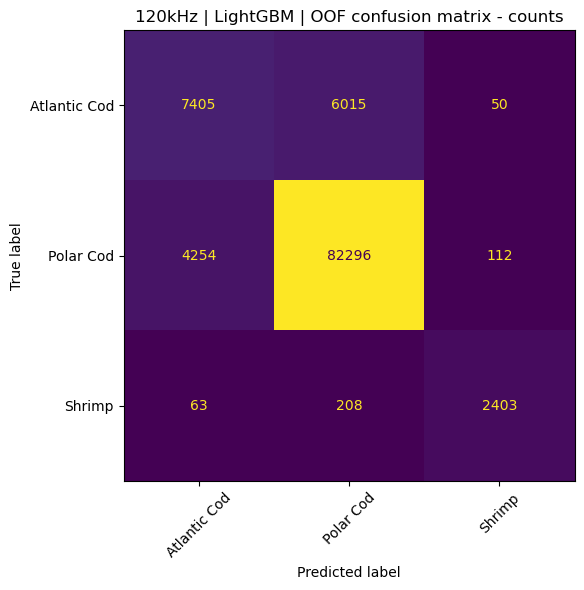

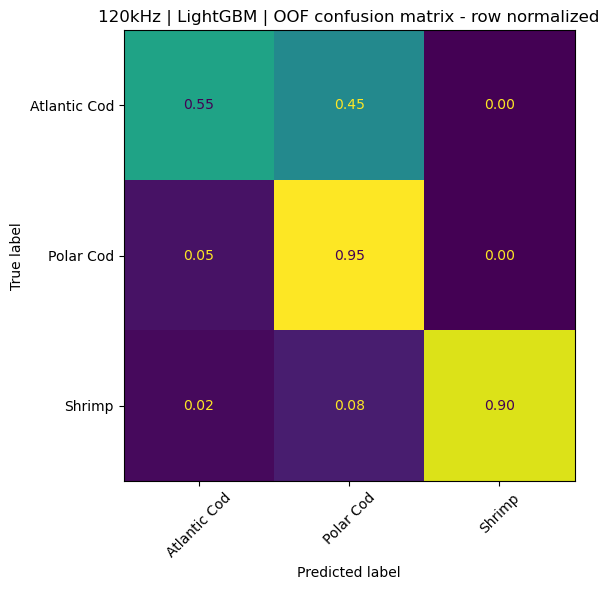

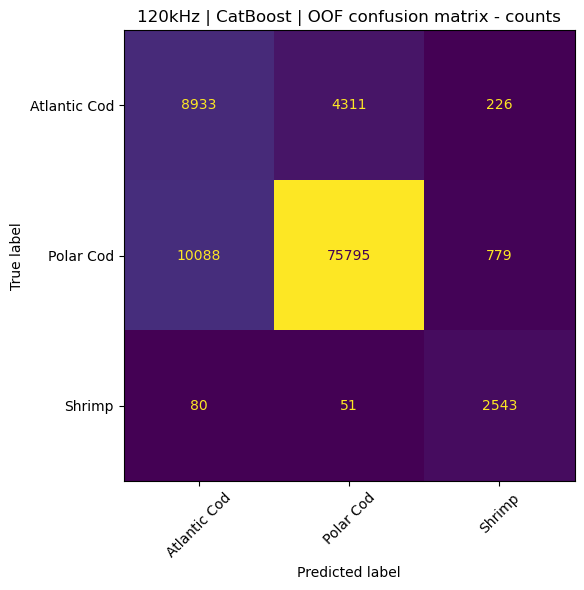

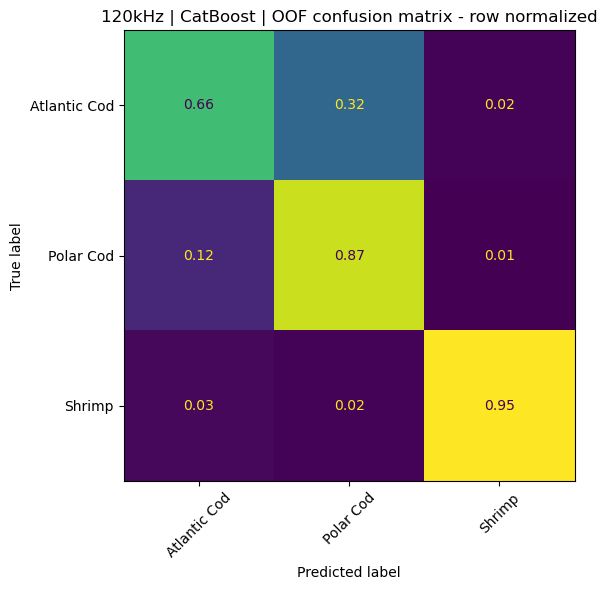



####################################################################################################
200kHz CONFUSION MATRICES
####################################################################################################


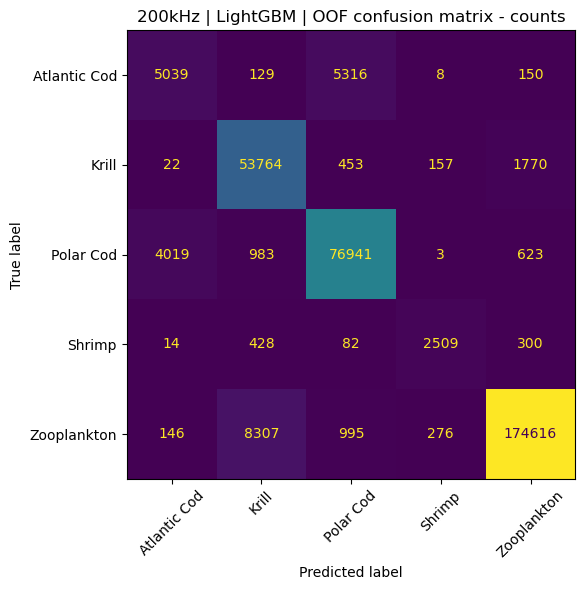

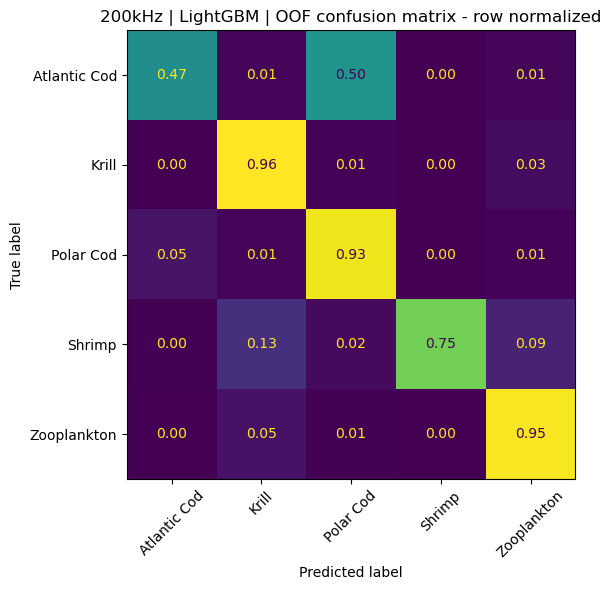

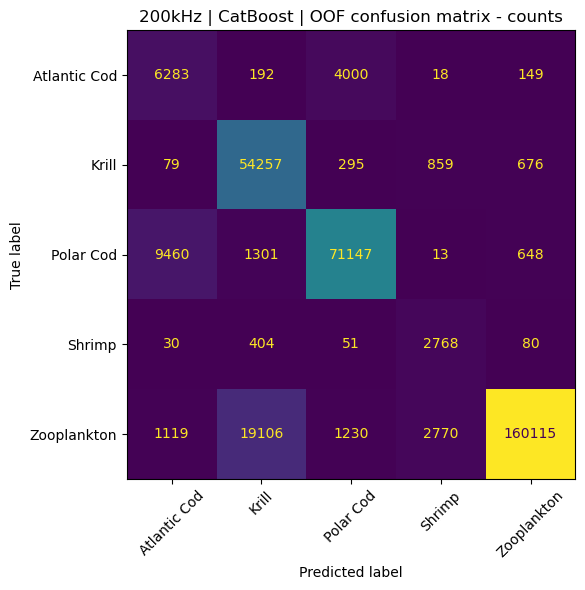

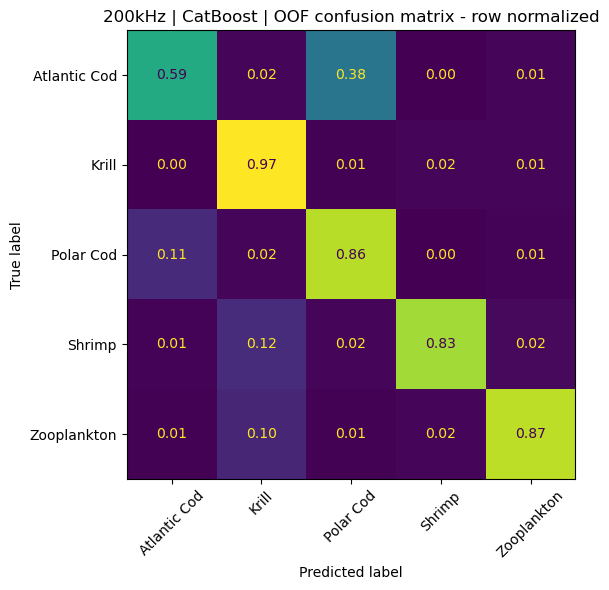



####################################################################################################
BEST MODEL BY DATASET
####################################################################################################


,dataset,model,oof_macro_f1,fold_macro_f1_mean,fold_macro_f1_sd,oof_weighted_f1,oof_accuracy,inner_best_macro_f1_mean
0,120kHz,LightGBM,0.814930,0.814990,0.060116,0.892900,0.895901,0.807402
1,200kHz,LightGBM,0.818638,0.814884,0.066959,0.928028,0.928257,0.801603




####################################################################################################
DECISION
####################################################################################################

120kHz: best model = LightGBM
  Selected because it has the highest OOF macro-F1 (0.8149).
  Fold macro-F1 = 0.8150 ± 0.0601.
  OOF weighted-F1 = 0.8929; OOF accuracy = 0.8959.
  Difference from second model (CatBoost) in OOF macro-F1 = 0.0567.
  The macro-F1 advantage is meaningful enough to prefer this model, unless one specific class is scientifically more important.

200kHz: best model = LightGBM
  Selected because it has the highest OOF macro-F1 (0.8186).
  Fold macro-F1 = 0.8149 ± 0.0670.
  OOF weighted-F1 = 0.9280; OOF accuracy = 0.9283.
  Difference from second model (CatBoost) in OOF macro-F1 = 0.0853.
  The macro-F1 advantage is meaningful enough to prefer this model, unless one specific class is scientifically more important.

Saved combined report tables in:
/User

In [16]:
# =============================================================================
# Nested CV result reporting and best-model selection
# Reads saved results for 120kHz and 200kHz: LightGBM + CatBoost
# =============================================================================


# =============================================================================
# Settings
# =============================================================================

PROJECT_DIR = Path.cwd()
OUTPUT_DIR = PROJECT_DIR / "outputs"

TUNED_OUT_DIR = OUTPUT_DIR / "nested_tuning_lightgbm_catboost_smarter"

DATASETS = ["120kHz", "200kHz"]
MODELS = ["LightGBM", "CatBoost"]

# Best model decision priority
SELECTION_COLUMNS = [
    "oof_macro_f1",
    "fold_macro_f1_mean",
    "oof_weighted_f1",
    "oof_accuracy",
]


def sanitize_filename(value: object) -> str:
    return "".join(
        char if char.isalnum() or char in "-_." else "_"
        for char in str(value)
    )


def read_json(path: Path) -> dict:
    with open(path, "r") as f:
        return json.load(f)


def safe_read_csv(path: Path) -> pd.DataFrame | None:
    if path.exists():
        return pd.read_csv(path)
    print(f"Missing file: {path}")
    return None


# =============================================================================
# Load all model results
# =============================================================================

summary_rows = []
per_class_tables = {}
fold_metrics_tables = {}
classification_reports = {}
oof_tables = {}

for dataset_name in DATASETS:
    for model_name in MODELS:
        model_dir = (
            TUNED_OUT_DIR
            / sanitize_filename(dataset_name)
            / sanitize_filename(model_name)
        )

        print("\n" + "=" * 90)
        print(f"Checking: {dataset_name} | {model_name}")
        print("=" * 90)
        print(f"Folder: {model_dir}")

        summary_path = model_dir / "summary.json"
        per_class_path = model_dir / "per_class_f1_summary.csv"
        fold_metrics_path = model_dir / "fold_metrics.csv"
        report_path = model_dir / "classification_report_oof.csv"
        oof_path = model_dir / "oof_predictions.csv"

        if not summary_path.exists():
            print(f"Skipping because summary.json is missing: {summary_path}")
            continue

        summary = read_json(summary_path)
        summary["model_dir"] = str(model_dir)
        summary_rows.append(summary)

        per_class_tables[(dataset_name, model_name)] = safe_read_csv(per_class_path)
        fold_metrics_tables[(dataset_name, model_name)] = safe_read_csv(fold_metrics_path)
        classification_reports[(dataset_name, model_name)] = safe_read_csv(report_path)
        oof_tables[(dataset_name, model_name)] = safe_read_csv(oof_path)


all_summary_df = pd.DataFrame(summary_rows)

if all_summary_df.empty:
    raise RuntimeError(
        f"No completed model summaries found in: {TUNED_OUT_DIR}"
    )


# =============================================================================
# Main model comparison table
# =============================================================================

comparison_cols = [
    "dataset",
    "model",
    "oof_macro_f1",
    "oof_weighted_f1",
    "oof_accuracy",
    "fold_macro_f1_mean",
    "fold_macro_f1_sd",
    "fold_weighted_f1_mean",
    "fold_weighted_f1_sd",
    "fold_accuracy_mean",
    "fold_accuracy_sd",
    "inner_best_macro_f1_mean",
    "inner_best_macro_f1_sd",
    "tuning_time_sec_mean",
    "fit_predict_time_sec_mean",
]

available_comparison_cols = [
    col for col in comparison_cols
    if col in all_summary_df.columns
]

model_comparison = (
    all_summary_df[available_comparison_cols]
    .sort_values(
        ["dataset", "oof_macro_f1", "fold_macro_f1_mean", "oof_weighted_f1", "oof_accuracy"],
        ascending=[True, False, False, False, False],
    )
    .reset_index(drop=True)
)

print("\n\n" + "#" * 100)
print("FULL MODEL COMPARISON")
print("#" * 100)
display(model_comparison)


# =============================================================================
# Separate tables for each dataset
# =============================================================================

for dataset_name in DATASETS:
    dataset_table = (
        model_comparison[model_comparison["dataset"] == dataset_name]
        .sort_values(
            ["oof_macro_f1", "fold_macro_f1_mean", "oof_weighted_f1", "oof_accuracy"],
            ascending=False,
        )
        .reset_index(drop=True)
    )

    print("\n\n" + "#" * 100)
    print(f"{dataset_name} MODEL COMPARISON")
    print("#" * 100)
    display(dataset_table)


# =============================================================================
# Per-class F1 results
# =============================================================================

for dataset_name in DATASETS:
    print("\n\n" + "#" * 100)
    print(f"{dataset_name} PER-CLASS F1 SUMMARY")
    print("#" * 100)

    merged_per_class = []

    for model_name in MODELS:
        df_pc = per_class_tables.get((dataset_name, model_name))

        if df_pc is None or df_pc.empty:
            print(f"No per-class file found for {dataset_name} | {model_name}")
            continue

        df_pc = df_pc.copy()
        df_pc["dataset"] = dataset_name
        df_pc["model"] = model_name

        wanted_cols = [
            "dataset",
            "model",
            "class",
            "oof_f1",
            "fold_f1_mean",
            "fold_f1_sd",
        ]

        wanted_cols = [col for col in wanted_cols if col in df_pc.columns]
        merged_per_class.append(df_pc[wanted_cols])

    if merged_per_class:
        dataset_pc_table = pd.concat(merged_per_class, ignore_index=True)

        dataset_pc_table = dataset_pc_table.sort_values(
            ["class", "oof_f1", "fold_f1_mean"],
            ascending=[True, False, False],
        ).reset_index(drop=True)

        display(dataset_pc_table)

        # Pivot view: easier model comparison per class
        if "oof_f1" in dataset_pc_table.columns:
            pivot_oof = dataset_pc_table.pivot_table(
                index="class",
                columns="model",
                values="oof_f1",
                aggfunc="first",
            )

            print(f"\n{dataset_name} per-class OOF F1 pivot:")
            display(pivot_oof)

            better_by_class = pivot_oof.idxmax(axis=1).rename("better_model")
            better_by_class_score = pivot_oof.max(axis=1).rename("best_oof_f1")

            class_winner_table = pd.concat(
                [pivot_oof, better_by_class, better_by_class_score],
                axis=1,
            )

            print(f"\n{dataset_name} per-class winner:")
            display(class_winner_table)


# =============================================================================
# Fold-by-fold metrics
# =============================================================================

for dataset_name in DATASETS:
    print("\n\n" + "#" * 100)
    print(f"{dataset_name} FOLD-BY-FOLD METRICS")
    print("#" * 100)

    merged_fold_metrics = []

    for model_name in MODELS:
        df_fold = fold_metrics_tables.get((dataset_name, model_name))

        if df_fold is None or df_fold.empty:
            print(f"No fold metrics file found for {dataset_name} | {model_name}")
            continue

        df_fold = df_fold.copy()
        merged_fold_metrics.append(df_fold)

    if merged_fold_metrics:
        dataset_fold_table = pd.concat(merged_fold_metrics, ignore_index=True)
        dataset_fold_table = dataset_fold_table.sort_values(
            ["model", "fold"]
        ).reset_index(drop=True)

        display(dataset_fold_table)


# =============================================================================
# Classification reports
# =============================================================================

for dataset_name in DATASETS:
    print("\n\n" + "#" * 100)
    print(f"{dataset_name} CLASSIFICATION REPORTS")
    print("#" * 100)

    for model_name in MODELS:
        report_df = classification_reports.get((dataset_name, model_name))

        if report_df is None or report_df.empty:
            print(f"No classification report found for {dataset_name} | {model_name}")
            continue

        print("\n" + "-" * 90)
        print(f"{dataset_name} | {model_name}")
        print("-" * 90)

        display(report_df)


# =============================================================================
# Confusion matrices from OOF predictions
# =============================================================================

def plot_oof_confusion_matrices(
    oof_df: pd.DataFrame,
    dataset_name: str,
    model_name: str,
):
    y_true = oof_df["true_label"].astype(str).values
    y_pred = oof_df["predicted_label"].astype(str).values

    class_names = sorted(pd.unique(np.concatenate([y_true, y_pred])))

    # Counts
    cm_counts = confusion_matrix(
        y_true,
        y_pred,
        labels=class_names,
    )

    fig, ax = plt.subplots(figsize=(7, 6))
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm_counts,
        display_labels=class_names,
    )
    disp.plot(
        ax=ax,
        xticks_rotation=45,
        values_format="d",
        colorbar=False,
    )
    ax.set_title(f"{dataset_name} | {model_name} | OOF confusion matrix - counts")
    plt.tight_layout()
    plt.show()

    # Row-normalized
    cm_norm = confusion_matrix(
        y_true,
        y_pred,
        labels=class_names,
        normalize="true",
    )

    fig, ax = plt.subplots(figsize=(7, 6))
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm_norm,
        display_labels=class_names,
    )
    disp.plot(
        ax=ax,
        xticks_rotation=45,
        values_format=".2f",
        colorbar=False,
    )
    ax.set_title(f"{dataset_name} | {model_name} | OOF confusion matrix - row normalized")
    plt.tight_layout()
    plt.show()


for dataset_name in DATASETS:
    print("\n\n" + "#" * 100)
    print(f"{dataset_name} CONFUSION MATRICES")
    print("#" * 100)

    for model_name in MODELS:
        oof_df = oof_tables.get((dataset_name, model_name))

        if oof_df is None or oof_df.empty:
            print(f"No OOF predictions found for {dataset_name} | {model_name}")
            continue

        plot_oof_confusion_matrices(
            oof_df=oof_df,
            dataset_name=dataset_name,
            model_name=model_name,
        )


# =============================================================================
# Best model decision
# =============================================================================

best_models = (
    all_summary_df
    .sort_values(
        ["dataset", "oof_macro_f1", "fold_macro_f1_mean", "oof_weighted_f1", "oof_accuracy"],
        ascending=[True, False, False, False, False],
    )
    .groupby("dataset", as_index=False)
    .first()
)

best_models_table = best_models[
    [
        "dataset",
        "model",
        "oof_macro_f1",
        "fold_macro_f1_mean",
        "fold_macro_f1_sd",
        "oof_weighted_f1",
        "oof_accuracy",
        "inner_best_macro_f1_mean",
    ]
].copy()

print("\n\n" + "#" * 100)
print("BEST MODEL BY DATASET")
print("#" * 100)
display(best_models_table)


# =============================================================================
# Human-readable decision text
# =============================================================================

print("\n\n" + "#" * 100)
print("DECISION")
print("#" * 100)

for _, row in best_models_table.iterrows():
    dataset_name = row["dataset"]
    best_model = row["model"]

    dataset_comp = model_comparison[model_comparison["dataset"] == dataset_name].copy()

    print(f"\n{dataset_name}: best model = {best_model}")
    print(
        f"  Selected because it has the highest OOF macro-F1 "
        f"({row['oof_macro_f1']:.4f})."
    )
    print(
        f"  Fold macro-F1 = {row['fold_macro_f1_mean']:.4f} "
        f"± {row['fold_macro_f1_sd']:.4f}."
    )
    print(
        f"  OOF weighted-F1 = {row['oof_weighted_f1']:.4f}; "
        f"OOF accuracy = {row['oof_accuracy']:.4f}."
    )

    if len(dataset_comp) > 1:
        top = dataset_comp.iloc[0]
        second = dataset_comp.iloc[1]

        delta_macro = top["oof_macro_f1"] - second["oof_macro_f1"]

        print(
            f"  Difference from second model "
            f"({second['model']}) in OOF macro-F1 = {delta_macro:.4f}."
        )

        if abs(delta_macro) < 0.01:
            print(
                "  Note: the difference is very small. "
                "Check per-class F1 and confusion matrices before making a final scientific decision."
            )
        elif delta_macro >= 0.01:
            print(
                "  The macro-F1 advantage is meaningful enough to prefer this model, "
                "unless one specific class is scientifically more important."
            )


# =============================================================================
# Save combined report tables
# =============================================================================

REPORT_OUT_DIR = TUNED_OUT_DIR / "combined_report_tables"
REPORT_OUT_DIR.mkdir(parents=True, exist_ok=True)

model_comparison.to_csv(
    REPORT_OUT_DIR / "full_model_comparison.csv",
    index=False,
)

best_models_table.to_csv(
    REPORT_OUT_DIR / "best_model_by_dataset.csv",
    index=False,
)

all_per_class = []

for (dataset_name, model_name), df_pc in per_class_tables.items():
    if df_pc is None or df_pc.empty:
        continue

    temp = df_pc.copy()
    temp["dataset"] = dataset_name
    temp["model"] = model_name
    all_per_class.append(temp)

if all_per_class:
    all_per_class_df = pd.concat(all_per_class, ignore_index=True)
    all_per_class_df.to_csv(
        REPORT_OUT_DIR / "all_models_per_class_f1_summary.csv",
        index=False,
    )

print("\nSaved combined report tables in:")
print(REPORT_OUT_DIR)

In [17]:
# =============================================================================
# Final full-data retuning and training for LightGBM + CatBoost
# Saves final models as .pkl bundles
# =============================================================================

import json
import pickle
import time
import numpy as np
import pandas as pd
import optuna
import lightgbm as lgb

from pathlib import Path
from catboost import CatBoostClassifier
from sklearn.metrics import f1_score
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight


# =============================================================================
# Settings
# =============================================================================

PROJECT_DIR = Path.cwd()
OUTPUT_DIR = PROJECT_DIR / "outputs"

FINAL_MODEL_OUT_DIR = OUTPUT_DIR / "final_full_data_retuned_models_all"
FINAL_MODEL_OUT_DIR.mkdir(parents=True, exist_ok=True)

LABEL_COL = "Species"
RANDOM_STATE = 42

INNER_SPLITS = 5

# CatBoost is much slower, so you can keep it lower if needed
FINAL_N_TRIALS_LIGHTGBM = 30
FINAL_N_TRIALS_CATBOOST = 30

EARLY_STOPPING_ROUNDS = 50

DATASET_LOOKUP = {
    "120kHz": df_120,
    "200kHz": df_200,
}

MODELS_TO_TRAIN = ["LightGBM", "CatBoost"]


# =============================================================================
# Helper functions
# =============================================================================

def sanitize_filename(value: object) -> str:
    return "".join(
        char if char.isalnum() or char in "-_." else "_"
        for char in str(value)
    )


def infer_feature_cols(df: pd.DataFrame, label_col: str = LABEL_COL) -> list[str]:
    feature_cols = []

    for col in df.columns:
        if col == label_col:
            continue

        values = pd.to_numeric(df[col], errors="coerce")

        if values.notna().all():
            feature_cols.append(col)

    if not feature_cols:
        raise ValueError("No numeric feature columns found.")

    return feature_cols


def prepare_xy(df: pd.DataFrame, label_col: str = LABEL_COL):
    data = df.copy()
    data = data.loc[:, ~data.columns.duplicated()].copy()

    data = data[data[label_col].notna()].copy()
    data[label_col] = data[label_col].astype(str).str.strip()
    data = data[data[label_col] != ""].copy()
    data.reset_index(drop=True, inplace=True)

    feature_cols = infer_feature_cols(data, label_col)

    X_df = data[feature_cols].apply(pd.to_numeric, errors="coerce")

    if X_df.isna().any().any():
        bad_cols = X_df.columns[X_df.isna().any()].tolist()[:10]
        n_nan = int(X_df.isna().sum().sum())

        raise ValueError(
            f"X contains NaNs after conversion. Total NaNs={n_nan}. "
            f"Example bad columns: {bad_cols}"
        )

    X = X_df.values.astype(np.float32)
    y_str = data[label_col].astype(str).values

    label_encoder = LabelEncoder()
    y = label_encoder.fit_transform(y_str)
    class_names = list(label_encoder.classes_)

    return X, y, y_str, class_names, feature_cols, label_encoder


def balanced_class_weight_dict(y_encoded: np.ndarray) -> dict[int, float]:
    classes = np.unique(y_encoded)

    weights = compute_class_weight(
        class_weight="balanced",
        classes=classes,
        y=y_encoded,
    )

    return {int(cls): float(weight) for cls, weight in zip(classes, weights)}


def class_weight_vector(y_encoded: np.ndarray) -> list[float]:
    weight_map = balanced_class_weight_dict(y_encoded)
    max_class = int(np.max(np.unique(y_encoded)))

    weights = np.ones(max_class + 1, dtype=float)

    for cls, weight in weight_map.items():
        weights[int(cls)] = float(weight)

    return weights.tolist()


def make_contiguous_stratified_folds(
    y_str: np.ndarray,
    n_splits: int,
):
    y_str = np.asarray(y_str)
    n_samples = len(y_str)
    all_indices = np.arange(n_samples)

    fold_test_indices = [[] for _ in range(n_splits)]
    fold_info = [dict() for _ in range(n_splits)]

    for class_name in pd.unique(y_str):
        class_indices = all_indices[y_str == class_name]
        chunks = np.array_split(class_indices, n_splits)

        for fold_idx in range(n_splits):
            fold_test_indices[fold_idx].extend(chunks[fold_idx].tolist())
            fold_info[fold_idx][str(class_name)] = int(len(chunks[fold_idx]))

    folds = []
    used_indices = set()

    for fold_idx in range(n_splits):
        val_idx = np.array(sorted(fold_test_indices[fold_idx]), dtype=int)

        train_mask = np.ones(n_samples, dtype=bool)
        train_mask[val_idx] = False
        train_idx = np.where(train_mask)[0]

        if set(train_idx).intersection(set(val_idx)):
            raise RuntimeError(f"Fold {fold_idx + 1}: train/validation overlap.")

        used_indices.update(val_idx.tolist())
        folds.append((train_idx, val_idx))

    if len(used_indices) != n_samples:
        raise RuntimeError(
            f"Not all rows assigned exactly once. "
            f"assigned={len(used_indices)}, n={n_samples}"
        )

    return folds, fold_info


# =============================================================================
# LightGBM functions
# =============================================================================

def lgbm_search_space(trial: optuna.Trial) -> dict:
    return {
        "max_n_estimators": trial.suggest_categorical(
            "max_n_estimators",
            [500, 750, 1000, 1500],
        ),
        "learning_rate": trial.suggest_float(
            "learning_rate",
            0.02,
            0.20,
            log=True,
        ),
        "num_leaves": trial.suggest_categorical(
            "num_leaves",
            [30, 50, 70, 90, 120],
        ),
        "max_depth": trial.suggest_categorical(
            "max_depth",
            [4, 6, 8, 10, 12],
        ),
        "min_child_samples": trial.suggest_categorical(
            "min_child_samples",
            [10, 20, 40, 60, 90],
        ),
        "subsample": trial.suggest_categorical(
            "subsample",
            [0.60, 0.75, 0.90, 1.00],
        ),
        "colsample_bytree": trial.suggest_categorical(
            "colsample_bytree",
            [0.60, 0.75, 0.90, 1.00],
        ),
        "reg_lambda": trial.suggest_float(
            "reg_lambda",
            1e-5,
            10.0,
            log=True,
        ),
    }


def build_lgbm_model(
    params: dict,
    y_train: np.ndarray,
    random_state: int = RANDOM_STATE,
) -> lgb.LGBMClassifier:
    return lgb.LGBMClassifier(
        **dict(params),
        objective="multiclass",
        class_weight=balanced_class_weight_dict(y_train),
        random_state=random_state,
        n_jobs=-1,
        verbose=-1,
    )


def final_tune_lgbm_full_data(
    X: np.ndarray,
    y: np.ndarray,
    y_str: np.ndarray,
    dataset_name: str,
):
    folds, _ = make_contiguous_stratified_folds(
        y_str=y_str,
        n_splits=INNER_SPLITS,
    )

    def objective(trial: optuna.Trial) -> float:
        search_params = lgbm_search_space(trial)
        max_n_estimators = int(search_params.pop("max_n_estimators"))

        params = {
            **search_params,
            "n_estimators": max_n_estimators,
        }

        scores = []
        best_iterations = []

        for fold_num, (train_idx, val_idx) in enumerate(folds, start=1):
            X_train = X[train_idx]
            X_val = X[val_idx]
            y_train = y[train_idx]
            y_val = y[val_idx]

            model = build_lgbm_model(
                params=params,
                y_train=y_train,
                random_state=RANDOM_STATE,
            )

            model.fit(
                X_train,
                y_train,
                eval_set=[(X_val, y_val)],
                eval_metric="multi_logloss",
                callbacks=[
                    lgb.early_stopping(
                        stopping_rounds=EARLY_STOPPING_ROUNDS,
                        verbose=False,
                    ),
                    lgb.log_evaluation(period=0),
                ],
            )

            y_pred = model.predict(X_val)

            score = f1_score(
                y_val,
                y_pred,
                average="macro",
                zero_division=0,
            )

            scores.append(score)

            best_iter = getattr(model, "best_iteration_", None)
            if best_iter is None or best_iter <= 0:
                best_iter = max_n_estimators

            best_iterations.append(int(best_iter))

            trial.report(float(np.mean(scores)), step=fold_num)

            if trial.should_prune():
                raise optuna.TrialPruned()

        trial.set_user_attr("median_best_iteration", int(np.median(best_iterations)))
        trial.set_user_attr("mean_best_iteration", float(np.mean(best_iterations)))
        trial.set_user_attr("best_iterations", best_iterations)

        return float(np.mean(scores))

    study = optuna.create_study(
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE + 9999),
        pruner=optuna.pruners.MedianPruner(
            n_startup_trials=5,
            n_warmup_steps=2,
        ),
        study_name=f"{dataset_name}_LightGBM_final_full_data_retune",
    )

    study.optimize(
        objective,
        n_trials=FINAL_N_TRIALS_LIGHTGBM,
        show_progress_bar=False,
    )

    best_params = dict(study.best_params)

    max_n_estimators = int(best_params.pop("max_n_estimators"))
    best_iteration = study.best_trial.user_attrs.get(
        "median_best_iteration",
        max_n_estimators,
    )

    best_params["n_estimators"] = int(best_iteration)

    return best_params, float(study.best_value), study


# =============================================================================
# CatBoost functions
# =============================================================================

def catboost_search_space(trial: optuna.Trial) -> dict:
    return {
        "max_iterations": trial.suggest_categorical(
            "max_iterations",
            [500, 750, 1000, 1500],
        ),
        "learning_rate": trial.suggest_float(
            "learning_rate",
            0.02,
            0.20,
            log=True,
        ),
        "depth": trial.suggest_categorical(
            "depth",
            [6, 7, 8, 9, 10],
        ),
        "l2_leaf_reg": trial.suggest_float(
            "l2_leaf_reg",
            1.0,
            30.0,
            log=True,
        ),
        "random_strength": trial.suggest_float(
            "random_strength",
            0.1,
            10.0,
            log=True,
        ),
        "border_count": trial.suggest_categorical(
            "border_count",
            [64, 96, 128, 160],
        ),
        "bagging_temperature": trial.suggest_categorical(
            "bagging_temperature",
            [0.0, 0.25, 0.50, 0.75, 1.0],
        ),
    }


def build_catboost_model(
    params: dict,
    y_train: np.ndarray,
    random_state: int = RANDOM_STATE,
) -> CatBoostClassifier:
    return CatBoostClassifier(
        **dict(params),
        loss_function="MultiClass",
        class_weights=class_weight_vector(y_train),
        random_state=random_state,
        verbose=False,
        allow_writing_files=False,
        thread_count=-1,
    )


def final_tune_catboost_full_data(
    X: np.ndarray,
    y: np.ndarray,
    y_str: np.ndarray,
    dataset_name: str,
):
    folds, _ = make_contiguous_stratified_folds(
        y_str=y_str,
        n_splits=INNER_SPLITS,
    )

    def objective(trial: optuna.Trial) -> float:
        search_params = catboost_search_space(trial)
        max_iterations = int(search_params.pop("max_iterations"))

        params = {
            **search_params,
            "iterations": max_iterations,
        }

        scores = []
        best_iterations = []

        for fold_num, (train_idx, val_idx) in enumerate(folds, start=1):
            X_train = X[train_idx]
            X_val = X[val_idx]
            y_train = y[train_idx]
            y_val = y[val_idx]

            model = build_catboost_model(
                params=params,
                y_train=y_train,
                random_state=RANDOM_STATE,
            )

            model.fit(
                X_train,
                y_train,
                eval_set=(X_val, y_val),
                early_stopping_rounds=EARLY_STOPPING_ROUNDS,
                use_best_model=True,
            )

            y_pred = model.predict(X_val)
            y_pred = np.asarray(y_pred).reshape(-1).astype(int)

            score = f1_score(
                y_val,
                y_pred,
                average="macro",
                zero_division=0,
            )

            scores.append(score)

            best_iter = model.get_best_iteration()
            if best_iter is None or best_iter <= 0:
                best_iter = max_iterations
            else:
                best_iter = int(best_iter) + 1

            best_iterations.append(int(best_iter))

            trial.report(float(np.mean(scores)), step=fold_num)

            if trial.should_prune():
                raise optuna.TrialPruned()

        trial.set_user_attr("median_best_iteration", int(np.median(best_iterations)))
        trial.set_user_attr("mean_best_iteration", float(np.mean(best_iterations)))
        trial.set_user_attr("best_iterations", best_iterations)

        return float(np.mean(scores))

    study = optuna.create_study(
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE + 19999),
        pruner=optuna.pruners.MedianPruner(
            n_startup_trials=5,
            n_warmup_steps=2,
        ),
        study_name=f"{dataset_name}_CatBoost_final_full_data_retune",
    )

    study.optimize(
        objective,
        n_trials=FINAL_N_TRIALS_CATBOOST,
        show_progress_bar=False,
    )

    best_params = dict(study.best_params)

    max_iterations = int(best_params.pop("max_iterations"))
    best_iteration = study.best_trial.user_attrs.get(
        "median_best_iteration",
        max_iterations,
    )

    best_params["iterations"] = int(best_iteration)

    return best_params, float(study.best_value), study


# =============================================================================
# File naming
# =============================================================================

def make_model_filename(model_name: str, dataset_name: str) -> str:
    dataset_clean = dataset_name.lower()

    if model_name == "LightGBM":
        return f"LightGBM_classifier_{dataset_clean}.pkl"

    if model_name == "CatBoost":
        return f"Catboost_classifier_{dataset_clean}.pkl"

    raise ValueError(f"Unknown model name: {model_name}")


# =============================================================================
# Train final full-data retuned models
# =============================================================================

final_rows = []

for dataset_name, df in DATASET_LOOKUP.items():
    print("\n" + "=" * 100)
    print(f"Dataset: {dataset_name}")
    print("=" * 100)

    X, y, y_str, class_names, feature_cols, label_encoder = prepare_xy(
        df=df,
        label_col=LABEL_COL,
    )

    print(f"Rows: {X.shape[0]}")
    print(f"Features: {X.shape[1]}")
    print(f"Classes: {class_names}")

    for model_name in MODELS_TO_TRAIN:
        print("\n" + "-" * 100)
        print(f"Final full-data retuning and training | {dataset_name} | {model_name}")
        print("-" * 100)

        start_time = time.time()

        if model_name == "LightGBM":
            best_params, final_cv_macro_f1, study = final_tune_lgbm_full_data(
                X=X,
                y=y,
                y_str=y_str,
                dataset_name=dataset_name,
            )

            final_model = build_lgbm_model(
                params=best_params,
                y_train=y,
                random_state=RANDOM_STATE,
            )

        elif model_name == "CatBoost":
            best_params, final_cv_macro_f1, study = final_tune_catboost_full_data(
                X=X,
                y=y,
                y_str=y_str,
                dataset_name=dataset_name,
            )

            final_model = build_catboost_model(
                params=best_params,
                y_train=y,
                random_state=RANDOM_STATE,
            )

        else:
            raise ValueError(f"Unknown model: {model_name}")

        tuning_time_sec = time.time() - start_time

        print("\nBest final full-data CV macro-F1:")
        print(final_cv_macro_f1)

        print("\nBest final params:")
        print(best_params)

        # Train final model on all available mesocosm data
        final_model.fit(X, y)

        dataset_clean = dataset_name.lower()
        model_filename = make_model_filename(model_name, dataset_name)
        model_path = FINAL_MODEL_OUT_DIR / model_filename

        bundle = {
            "model": final_model,
            "model_name": model_name,
            "dataset_name": dataset_name,
            "label_col": LABEL_COL,
            "class_names": class_names,
            "feature_columns": feature_cols,
            "label_encoder": label_encoder,
            "best_params": best_params,
            "final_cv_macro_f1": final_cv_macro_f1,
            "training_data_shape": X.shape,
            "note": (
                "Final classifier trained on the full dataset after final full-data "
                "hyperparameter retuning using inner cross-validation. Nested CV was "
                "used earlier for unbiased model-family comparison."
            ),
        }

        with open(model_path, "wb") as f:
            pickle.dump(bundle, f)

        trials_df = study.trials_dataframe()
        trials_path = (
            FINAL_MODEL_OUT_DIR
            / f"{model_name}_final_retuning_trials_{dataset_clean}.csv"
        )
        trials_df.to_csv(trials_path, index=False)

        metadata_path = (
            FINAL_MODEL_OUT_DIR
            / f"{model_name}_classifier_{dataset_clean}_metadata.json"
        )

        metadata = {
            "dataset": dataset_name,
            "model": model_name,
            "model_file": str(model_path),
            "trials_file": str(trials_path),
            "label_col": LABEL_COL,
            "class_names": class_names,
            "feature_columns": feature_cols,
            "n_rows": int(X.shape[0]),
            "n_features": int(X.shape[1]),
            "final_cv_macro_f1": float(final_cv_macro_f1),
            "final_n_trials": (
                int(FINAL_N_TRIALS_LIGHTGBM)
                if model_name == "LightGBM"
                else int(FINAL_N_TRIALS_CATBOOST)
            ),
            "inner_splits": int(INNER_SPLITS),
            "early_stopping_rounds": int(EARLY_STOPPING_ROUNDS),
            "best_params": best_params,
            "tuning_time_sec": float(tuning_time_sec),
        }

        with open(metadata_path, "w") as f:
            json.dump(metadata, f, indent=4)

        final_rows.append({
            "dataset": dataset_name,
            "model": model_name,
            "model_file": str(model_path),
            "metadata_file": str(metadata_path),
            "trials_file": str(trials_path),
            "n_rows": int(X.shape[0]),
            "n_features": int(X.shape[1]),
            "classes": ", ".join(class_names),
            "final_cv_macro_f1": float(final_cv_macro_f1),
            "tuning_time_sec": float(tuning_time_sec),
            **best_params,
        })

        print(f"\nSaved model: {model_path}")
        print(f"Saved metadata: {metadata_path}")
        print(f"Saved trials: {trials_path}")


final_summary_df = pd.DataFrame(final_rows)

summary_path = FINAL_MODEL_OUT_DIR / "final_retuned_full_data_models_summary.csv"
final_summary_df.to_csv(summary_path, index=False)

print("\n" + "=" * 100)
print("Final retuned full-data models complete")
print("=" * 100)
display(final_summary_df)

print(f"\nSaved summary: {summary_path}")
print(f"Saved folder: {FINAL_MODEL_OUT_DIR}")


Dataset: 120kHz


[I 2026-06-09 19:16:04,618] A new study created in memory with name: 120kHz_LightGBM_final_full_data_retune


Rows: 102806
Features: 129
Classes: ['Atlantic Cod', 'Polar Cod', 'Shrimp']

----------------------------------------------------------------------------------------------------
Final full-data retuning and training | 120kHz | LightGBM
----------------------------------------------------------------------------------------------------


[I 2026-06-09 19:17:04,845] Trial 0 finished with value: 0.8111109779273427 and parameters: {'max_n_estimators': 1500, 'learning_rate': 0.16871656812054042, 'num_leaves': 70, 'max_depth': 12, 'min_child_samples': 60, 'subsample': 0.75, 'colsample_bytree': 0.6, 'reg_lambda': 0.35619892930576047}. Best is trial 0 with value: 0.8111109779273427.
[I 2026-06-09 19:18:26,131] Trial 1 finished with value: 0.8077572365941975 and parameters: {'max_n_estimators': 1000, 'learning_rate': 0.1269022878311656, 'num_leaves': 30, 'max_depth': 8, 'min_child_samples': 10, 'subsample': 0.6, 'colsample_bytree': 0.6, 'reg_lambda': 8.979480606702392}. Best is trial 0 with value: 0.8111109779273427.
[I 2026-06-09 19:19:25,302] Trial 2 finished with value: 0.8097207037567469 and parameters: {'max_n_estimators': 1500, 'learning_rate': 0.1611915589395093, 'num_leaves': 120, 'max_depth': 6, 'min_child_samples': 40, 'subsample': 0.6, 'colsample_bytree': 0.6, 'reg_lambda': 0.00013061195256082025}. Best is trial 0 w


Best final full-data CV macro-F1:
0.8127676287823891

Best final params:
{'learning_rate': 0.08729796005437104, 'num_leaves': 70, 'max_depth': 12, 'min_child_samples': 60, 'subsample': 1.0, 'colsample_bytree': 0.9, 'reg_lambda': 0.16474702687385384, 'n_estimators': 660}


...


Saved model: /Users/arianrezaei/Desktop/Code/outputs/final_full_data_retuned_models_all/LightGBM_classifier_200khz.pkl
Saved metadata: /Users/arianrezaei/Desktop/Code/outputs/final_full_data_retuned_models_all/LightGBM_classifier_200khz_metadata.json
Saved trials: /Users/arianrezaei/Desktop/Code/outputs/final_full_data_retuned_models_all/LightGBM_final_retuning_trials_200khz.csv

----------------------------------------------------------------------------------------------------
Final full-data retuning and training | 200kHz | CatBoost
----------------------------------------------------------------------------------------------------


[I 2026-06-09 22:41:00,246] Trial 0 finished with value: 0.6942573760140627 and parameters: {'max_iterations': 750, 'learning_rate': 0.04455407144363655, 'depth': 8, 'l2_leaf_reg': 2.3919040561585843, 'random_strength': 1.6229551242636455, 'border_count': 64, 'bagging_temperature': 0.0}. Best is trial 0 with value: 0.6942573760140627.
[I 2026-06-09 22:49:48,160] Trial 1 finished with value: 0.7173533005083497 and parameters: {'max_iterations': 1500, 'learning_rate': 0.1231414685564109, 'depth': 8, 'l2_leaf_reg': 2.451799085235036, 'random_strength': 9.201982163456007, 'border_count': 128, 'bagging_temperature': 0.25}. Best is trial 1 with value: 0.7173533005083497.
[I 2026-06-09 23:03:04,632] Trial 2 finished with value: 0.6893311809702517 and parameters: {'max_iterations': 750, 'learning_rate': 0.034273758691085926, 'depth': 9, 'l2_leaf_reg': 2.197956410225208, 'random_strength': 1.133672710131487, 'border_count': 64, 'bagging_temperature': 1.0}. Best is trial 1 with value: 0.71735330


Best final full-data CV macro-F1:
0.7214753268193261

Best final params:
{'learning_rate': 0.10563603618299681, 'depth': 9, 'l2_leaf_reg': 10.507337000931704, 'random_strength': 3.541983511109073, 'border_count': 128, 'bagging_temperature': 0.25, 'iterations': 575}

Saved model: /Users/arianrezaei/Desktop/Code/outputs/final_full_data_retuned_models_all/Catboost_classifier_200khz.pkl
Saved metadata: /Users/arianrezaei/Desktop/Code/outputs/final_full_data_retuned_models_all/CatBoost_classifier_200khz_metadata.json
Saved trials: /Users/arianrezaei/Desktop/Code/outputs/final_full_data_retuned_models_all/CatBoost_final_retuning_trials_200khz.csv

Final retuned full-data models complete


,dataset,model,model_file,metadata_file,trials_file,n_rows,n_features,classes,final_cv_macro_f1,tuning_time_sec,...,subsample,colsample_bytree,reg_lambda,n_estimators,depth,l2_leaf_reg,random_strength,border_count,bagging_temperature,iterations
0,120kHz,LightGBM,/Users/arianrezaei/Desktop/Code/outputs/final_...,/Users/arianrezaei/Desktop/Code/outputs/final_...,/Users/arianrezaei/Desktop/Code/outputs/final_...,102806,129,"Atlantic Cod, Polar Cod, Shrimp",0.812768,2196.487571,...,1.0,0.9,0.164747,660.0,NaN,NaN,NaN,NaN,NaN,NaN
1,120kHz,CatBoost,/Users/arianrezaei/Desktop/Code/outputs/final_...,/Users/arianrezaei/Desktop/Code/outputs/final_...,/Users/arianrezaei/Desktop/Code/outputs/final_...,102806,129,"Atlantic Cod, Polar Cod, Shrimp",0.755776,2562.895582,...,NaN,NaN,NaN,NaN,9.0,8.738711,4.054450,160.0,0.50,562.0
2,200kHz,LightGBM,/Users/arianrezaei/Desktop/Code/outputs/final_...,/Users/arianrezaei/Desktop/Code/outputs/final_...,/Users/arianrezaei/Desktop/Code/outputs/final_...,337050,121,"Atlantic Cod, Krill, Polar Cod, Shrimp, Zoopla...",0.805989,6714.438950,...,1.0,0.6,9.382955,743.0,NaN,NaN,NaN,NaN,NaN,NaN
3,200kHz,CatBoost,/Users/arianrezaei/Desktop/Code/outputs/final_...,/Users/arianrezaei/Desktop/Code/outputs/final_...,/Users/arianrezaei/Desktop/Code/outputs/final_...,337050,121,"Atlantic Cod, Krill, Polar Cod, Shrimp, Zoopla...",0.721475,11618.464716,...,NaN,NaN,NaN,NaN,9.0,10.507337,3.541984,128.0,0.25,575.0



Saved summary: /Users/arianrezaei/Desktop/Code/outputs/final_full_data_retuned_models_all/final_retuned_full_data_models_summary.csv
Saved folder: /Users/arianrezaei/Desktop/Code/outputs/final_full_data_retuned_models_all


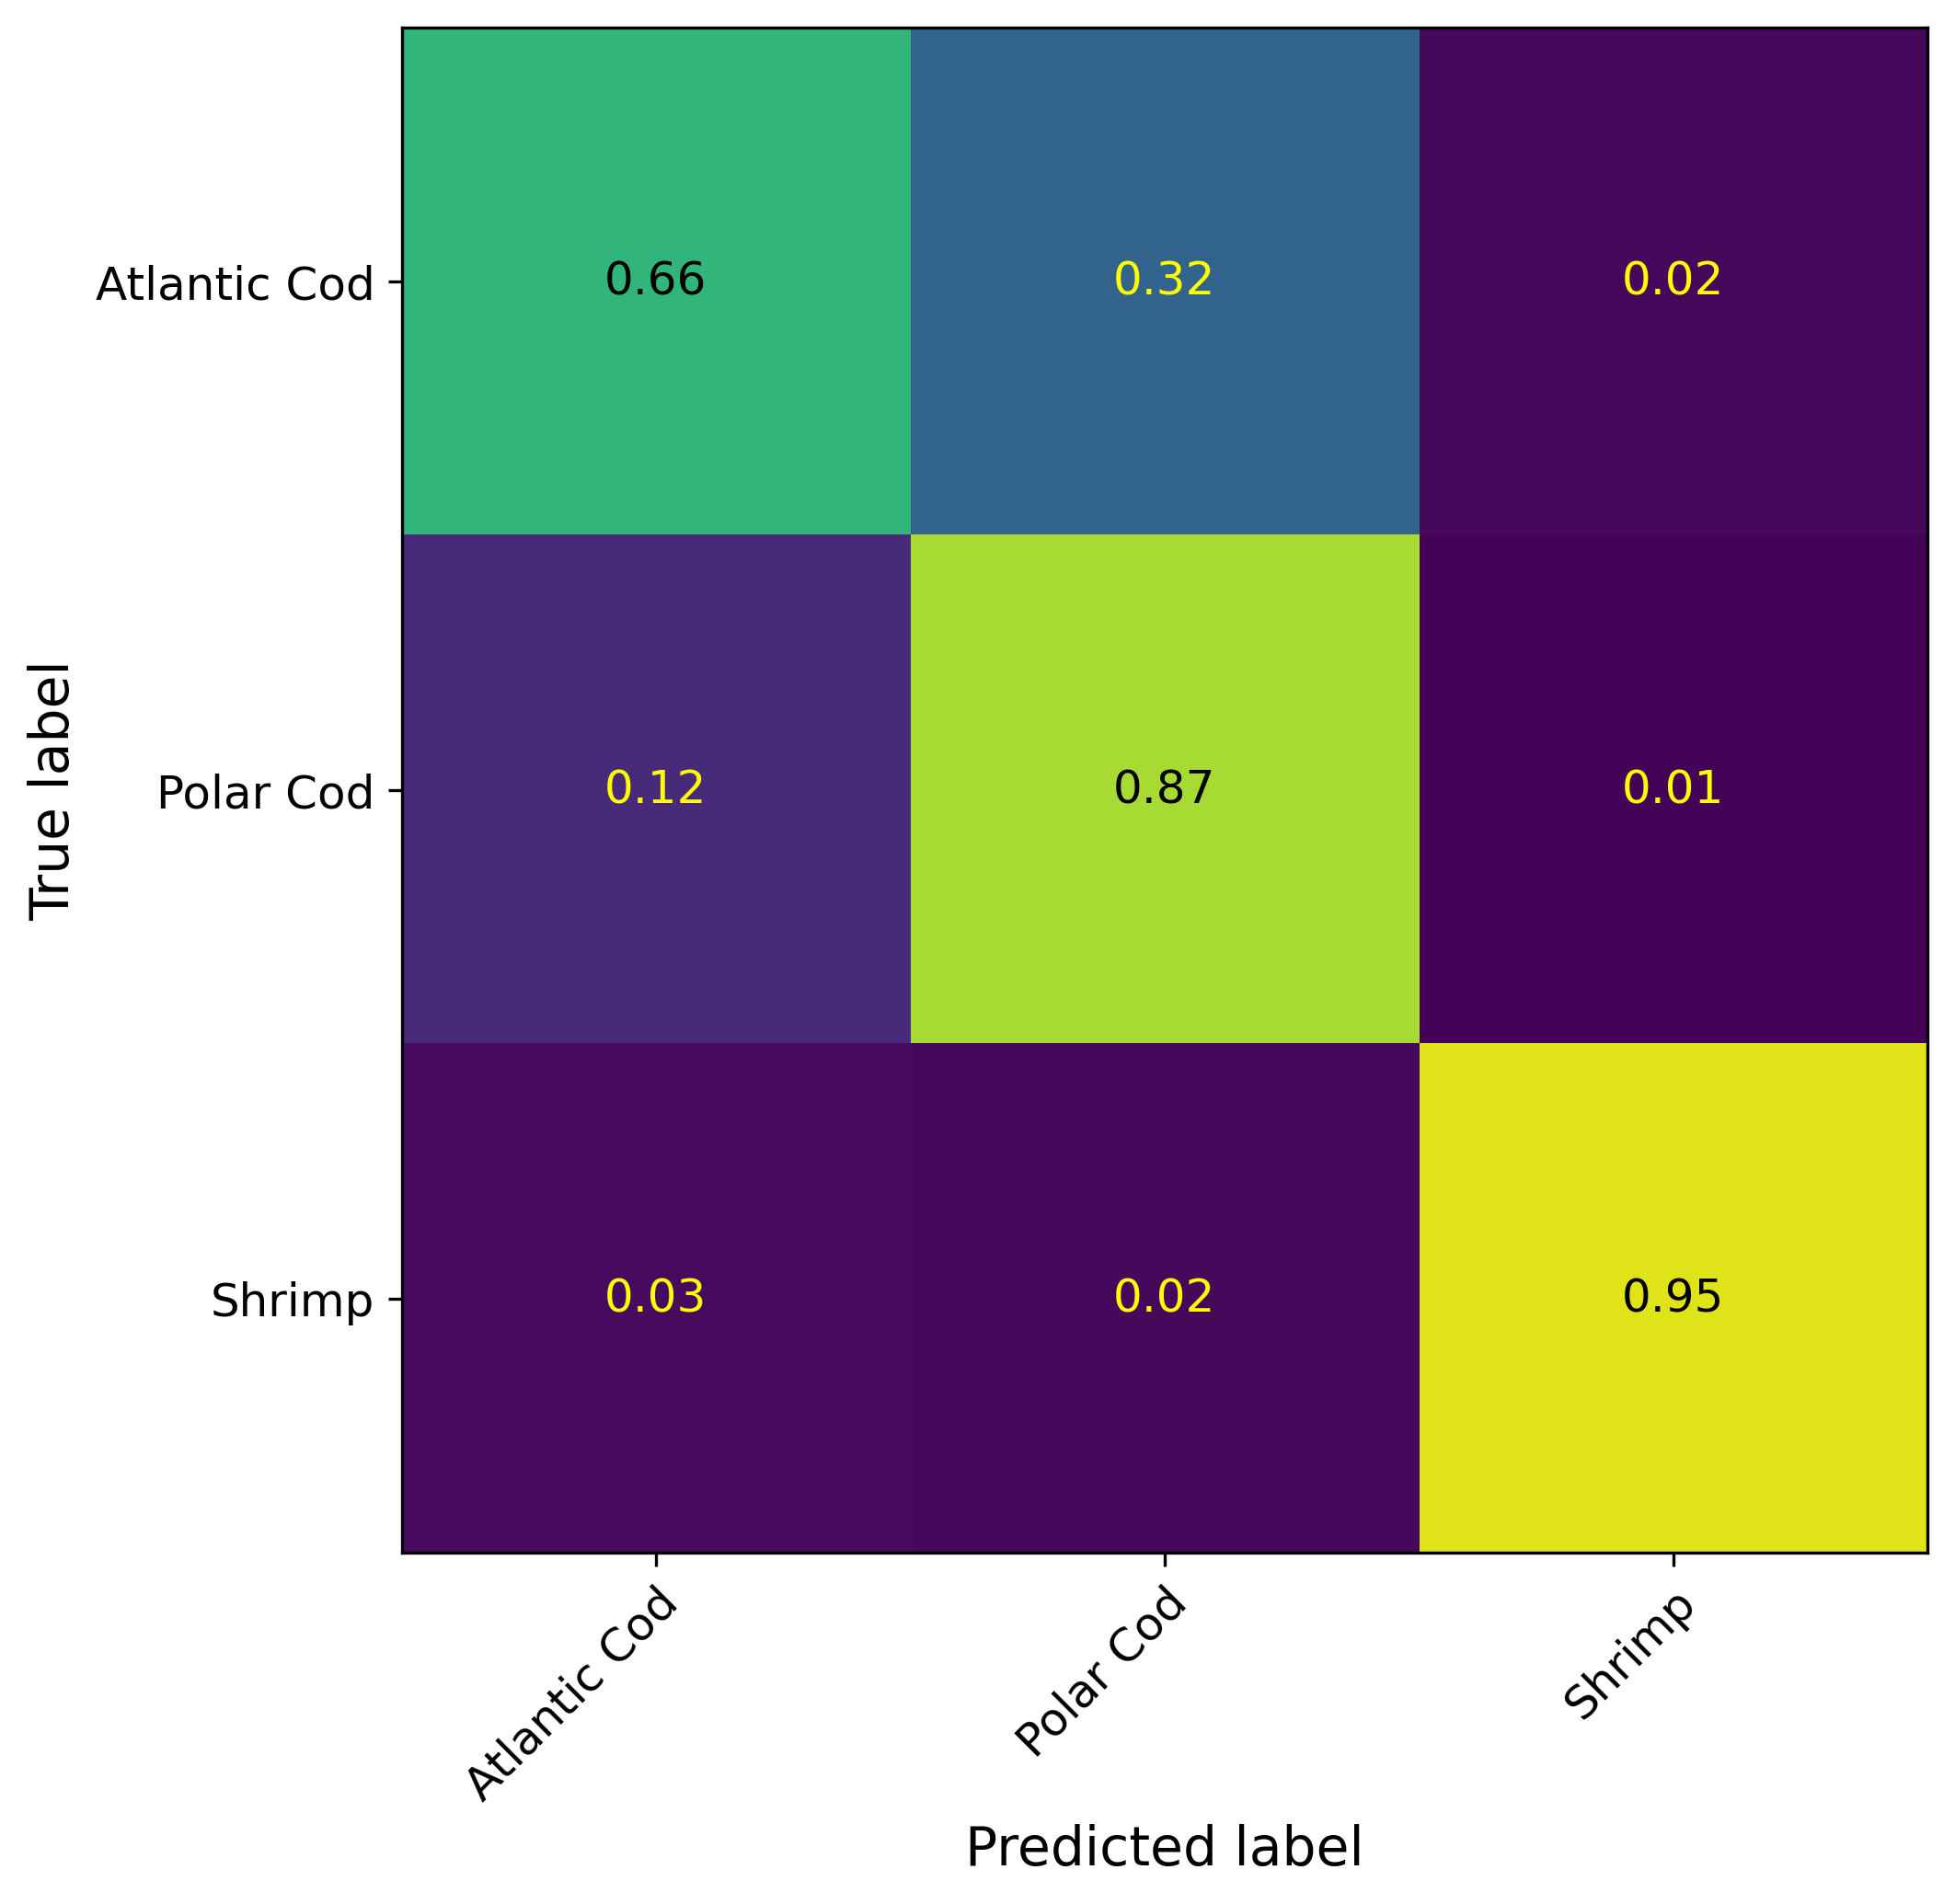

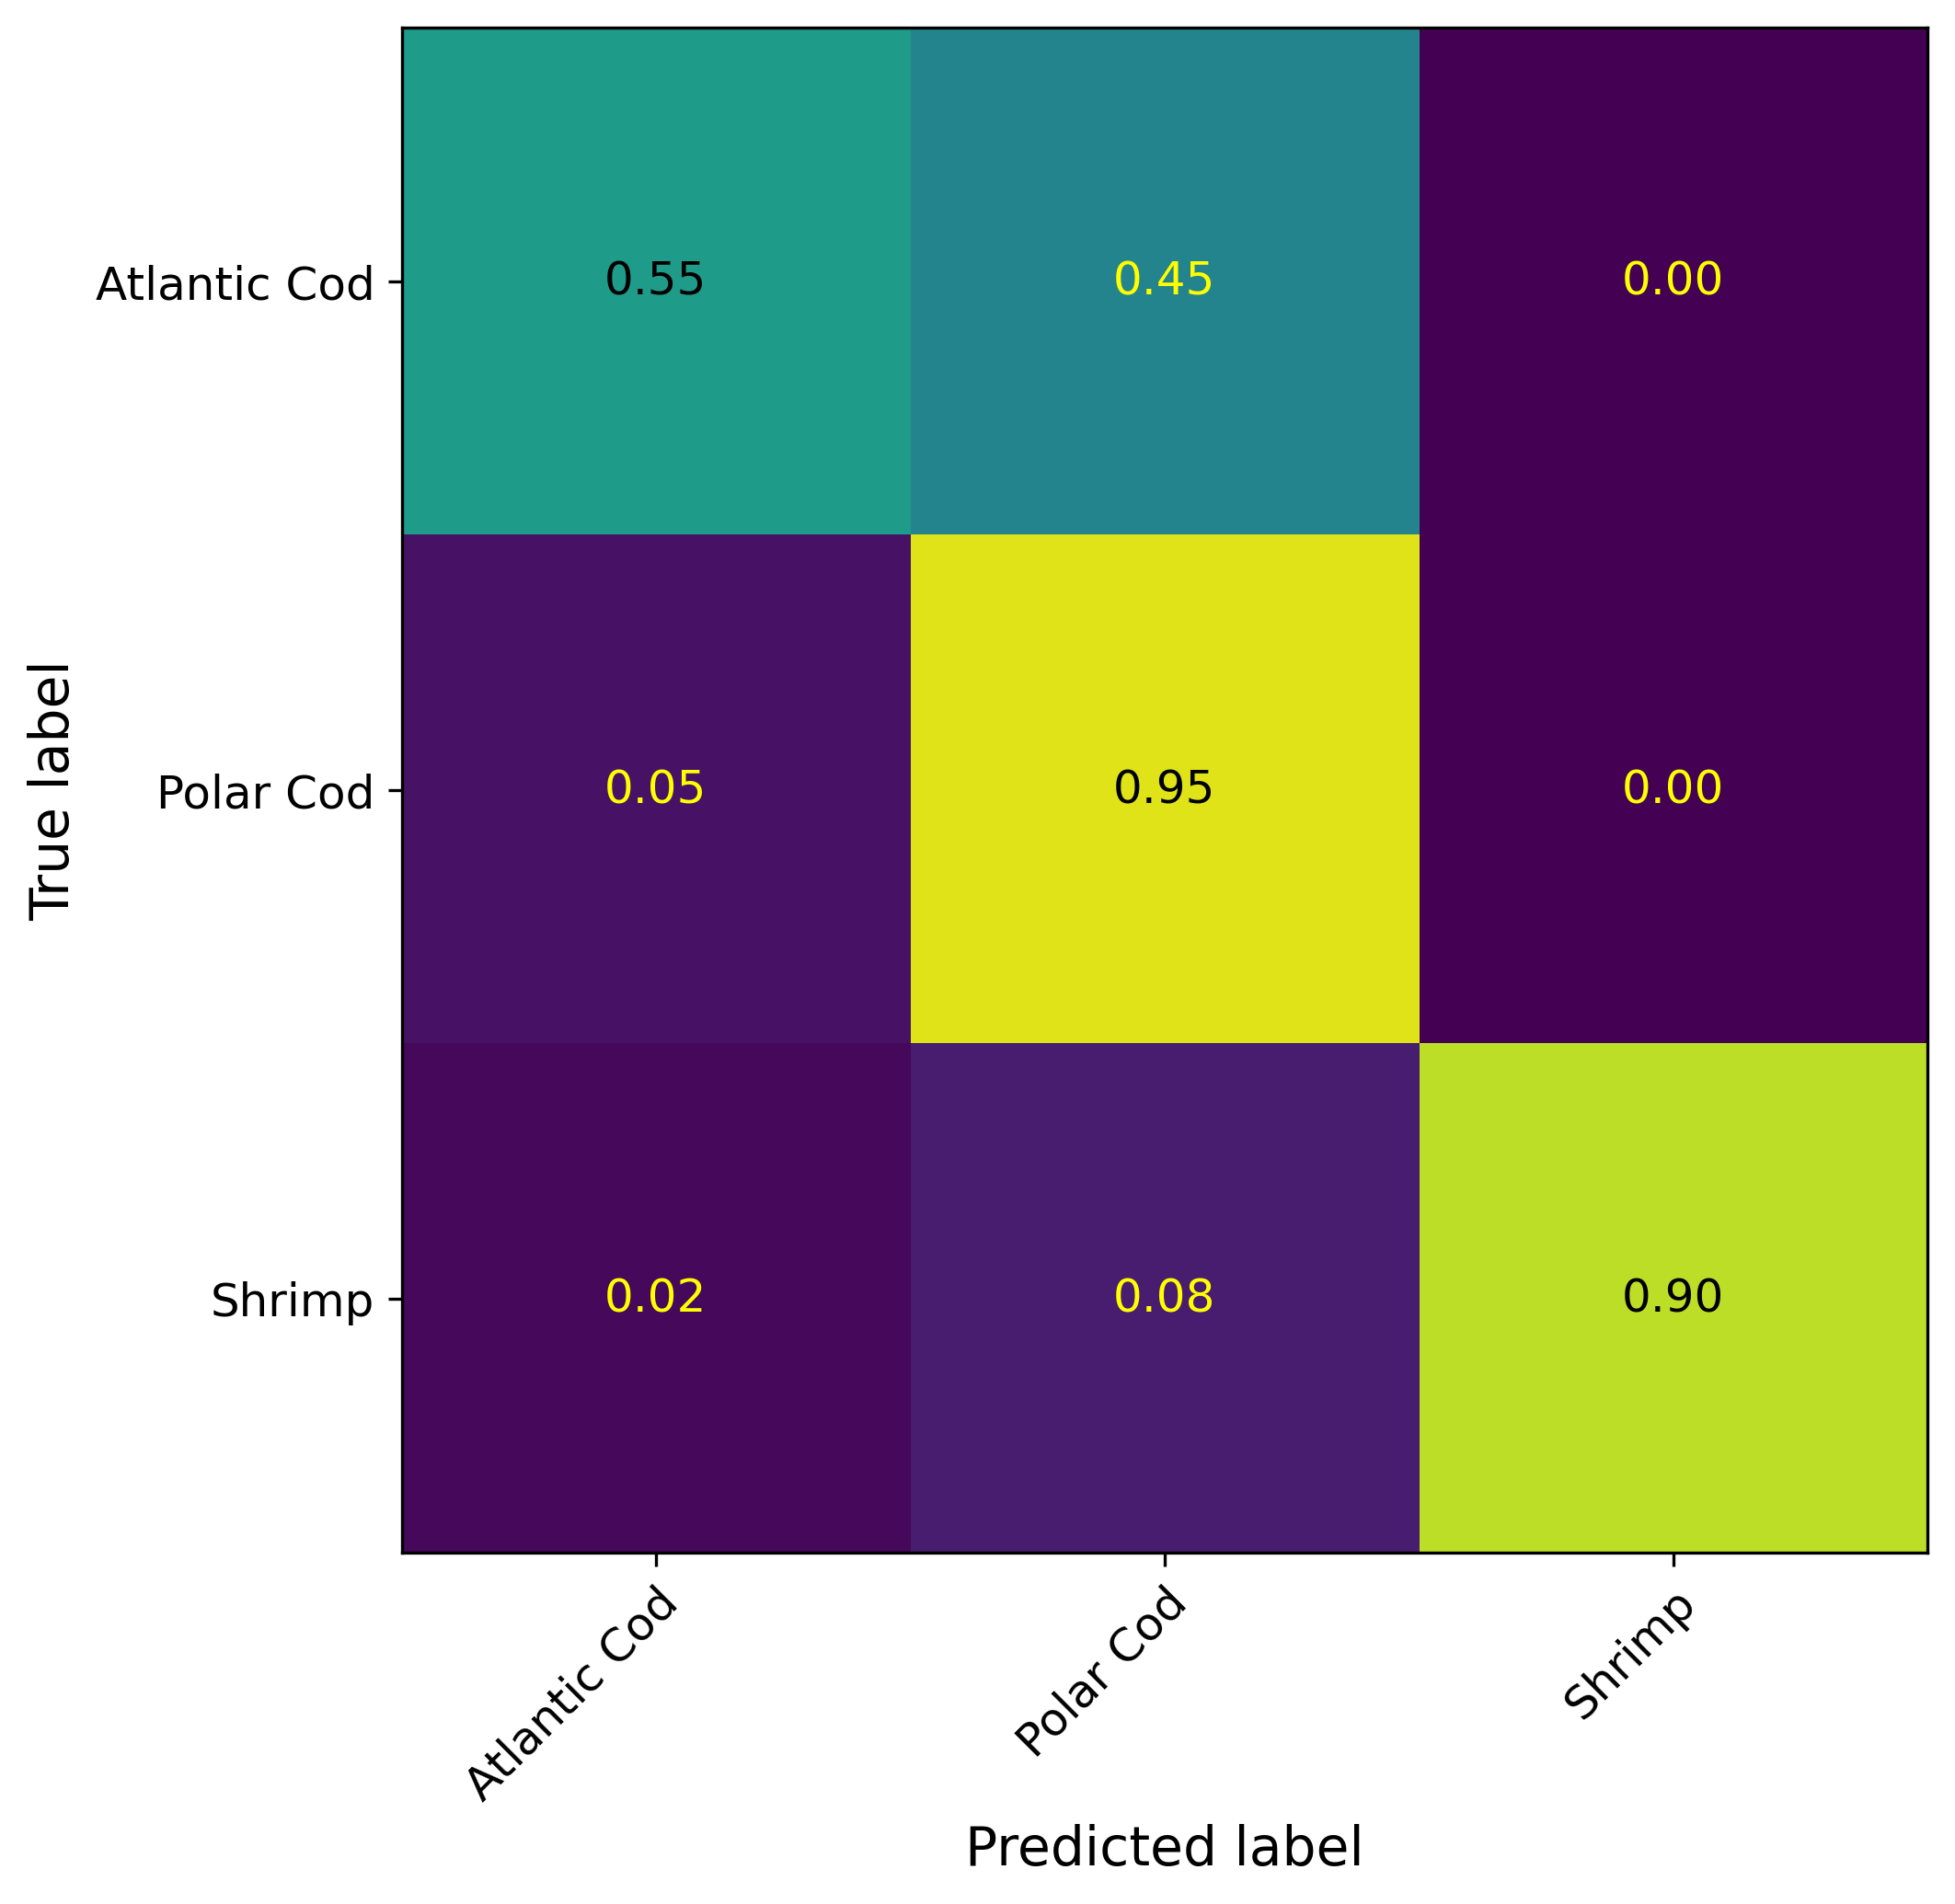

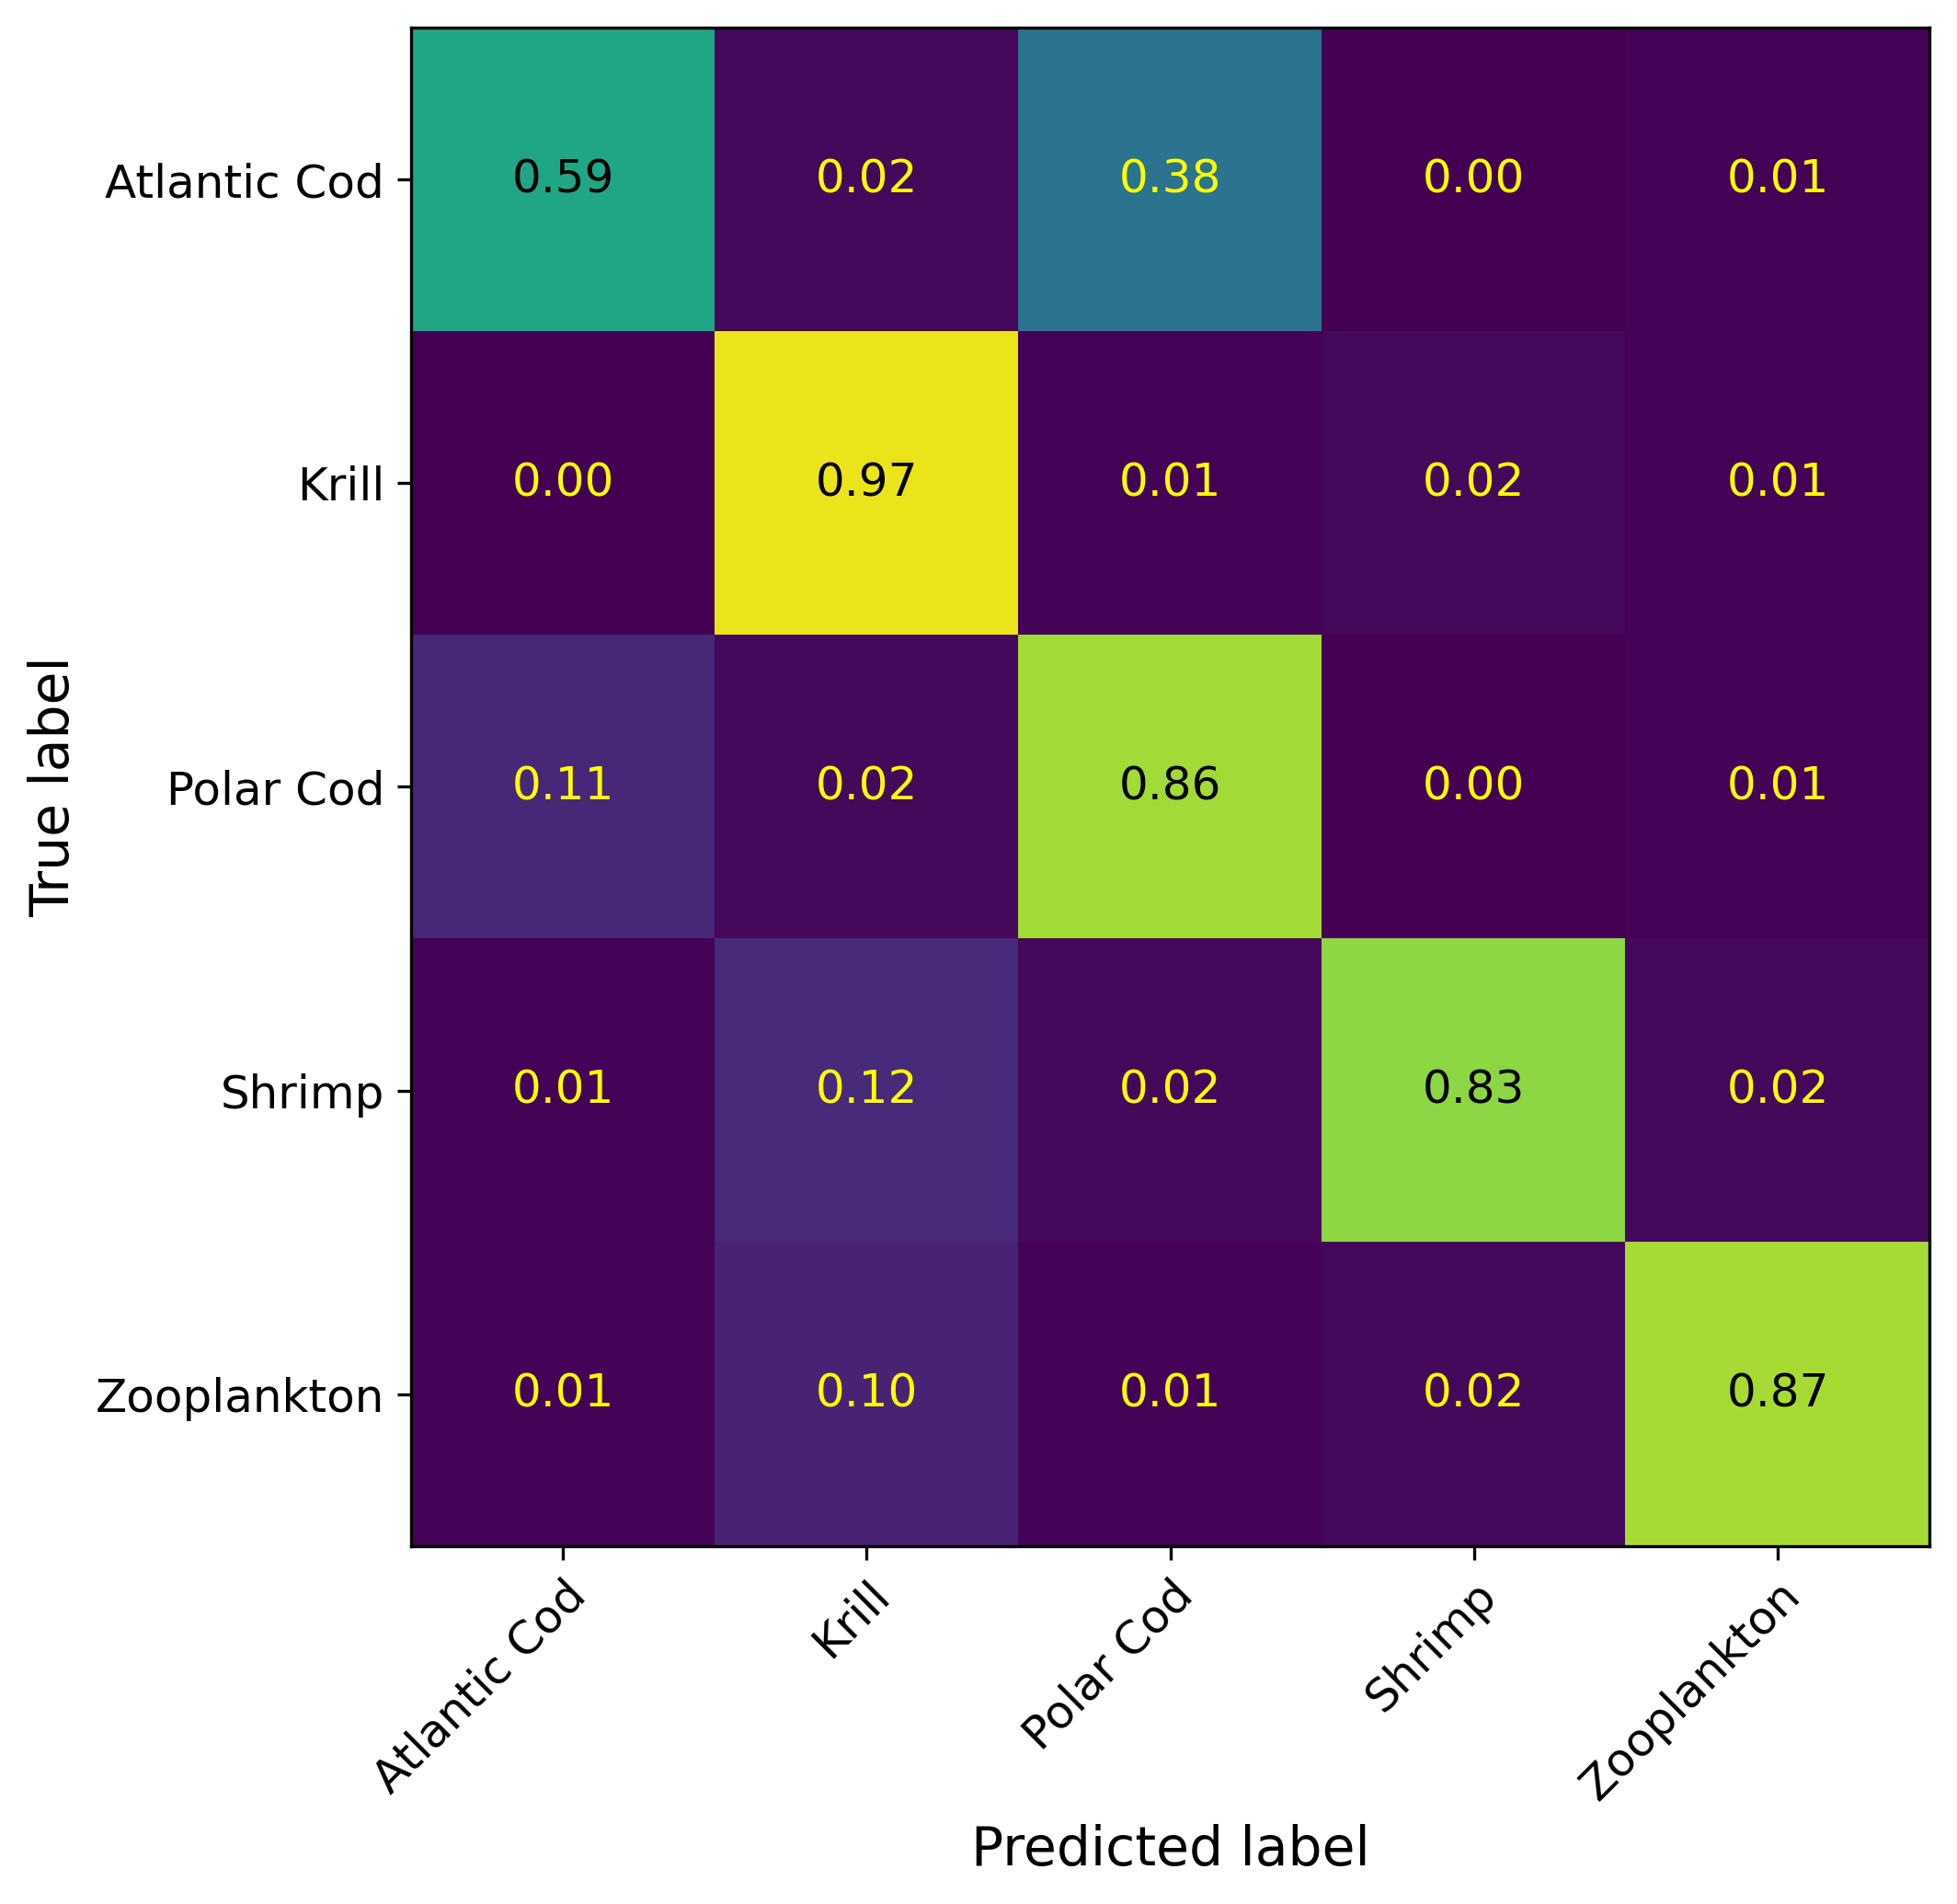

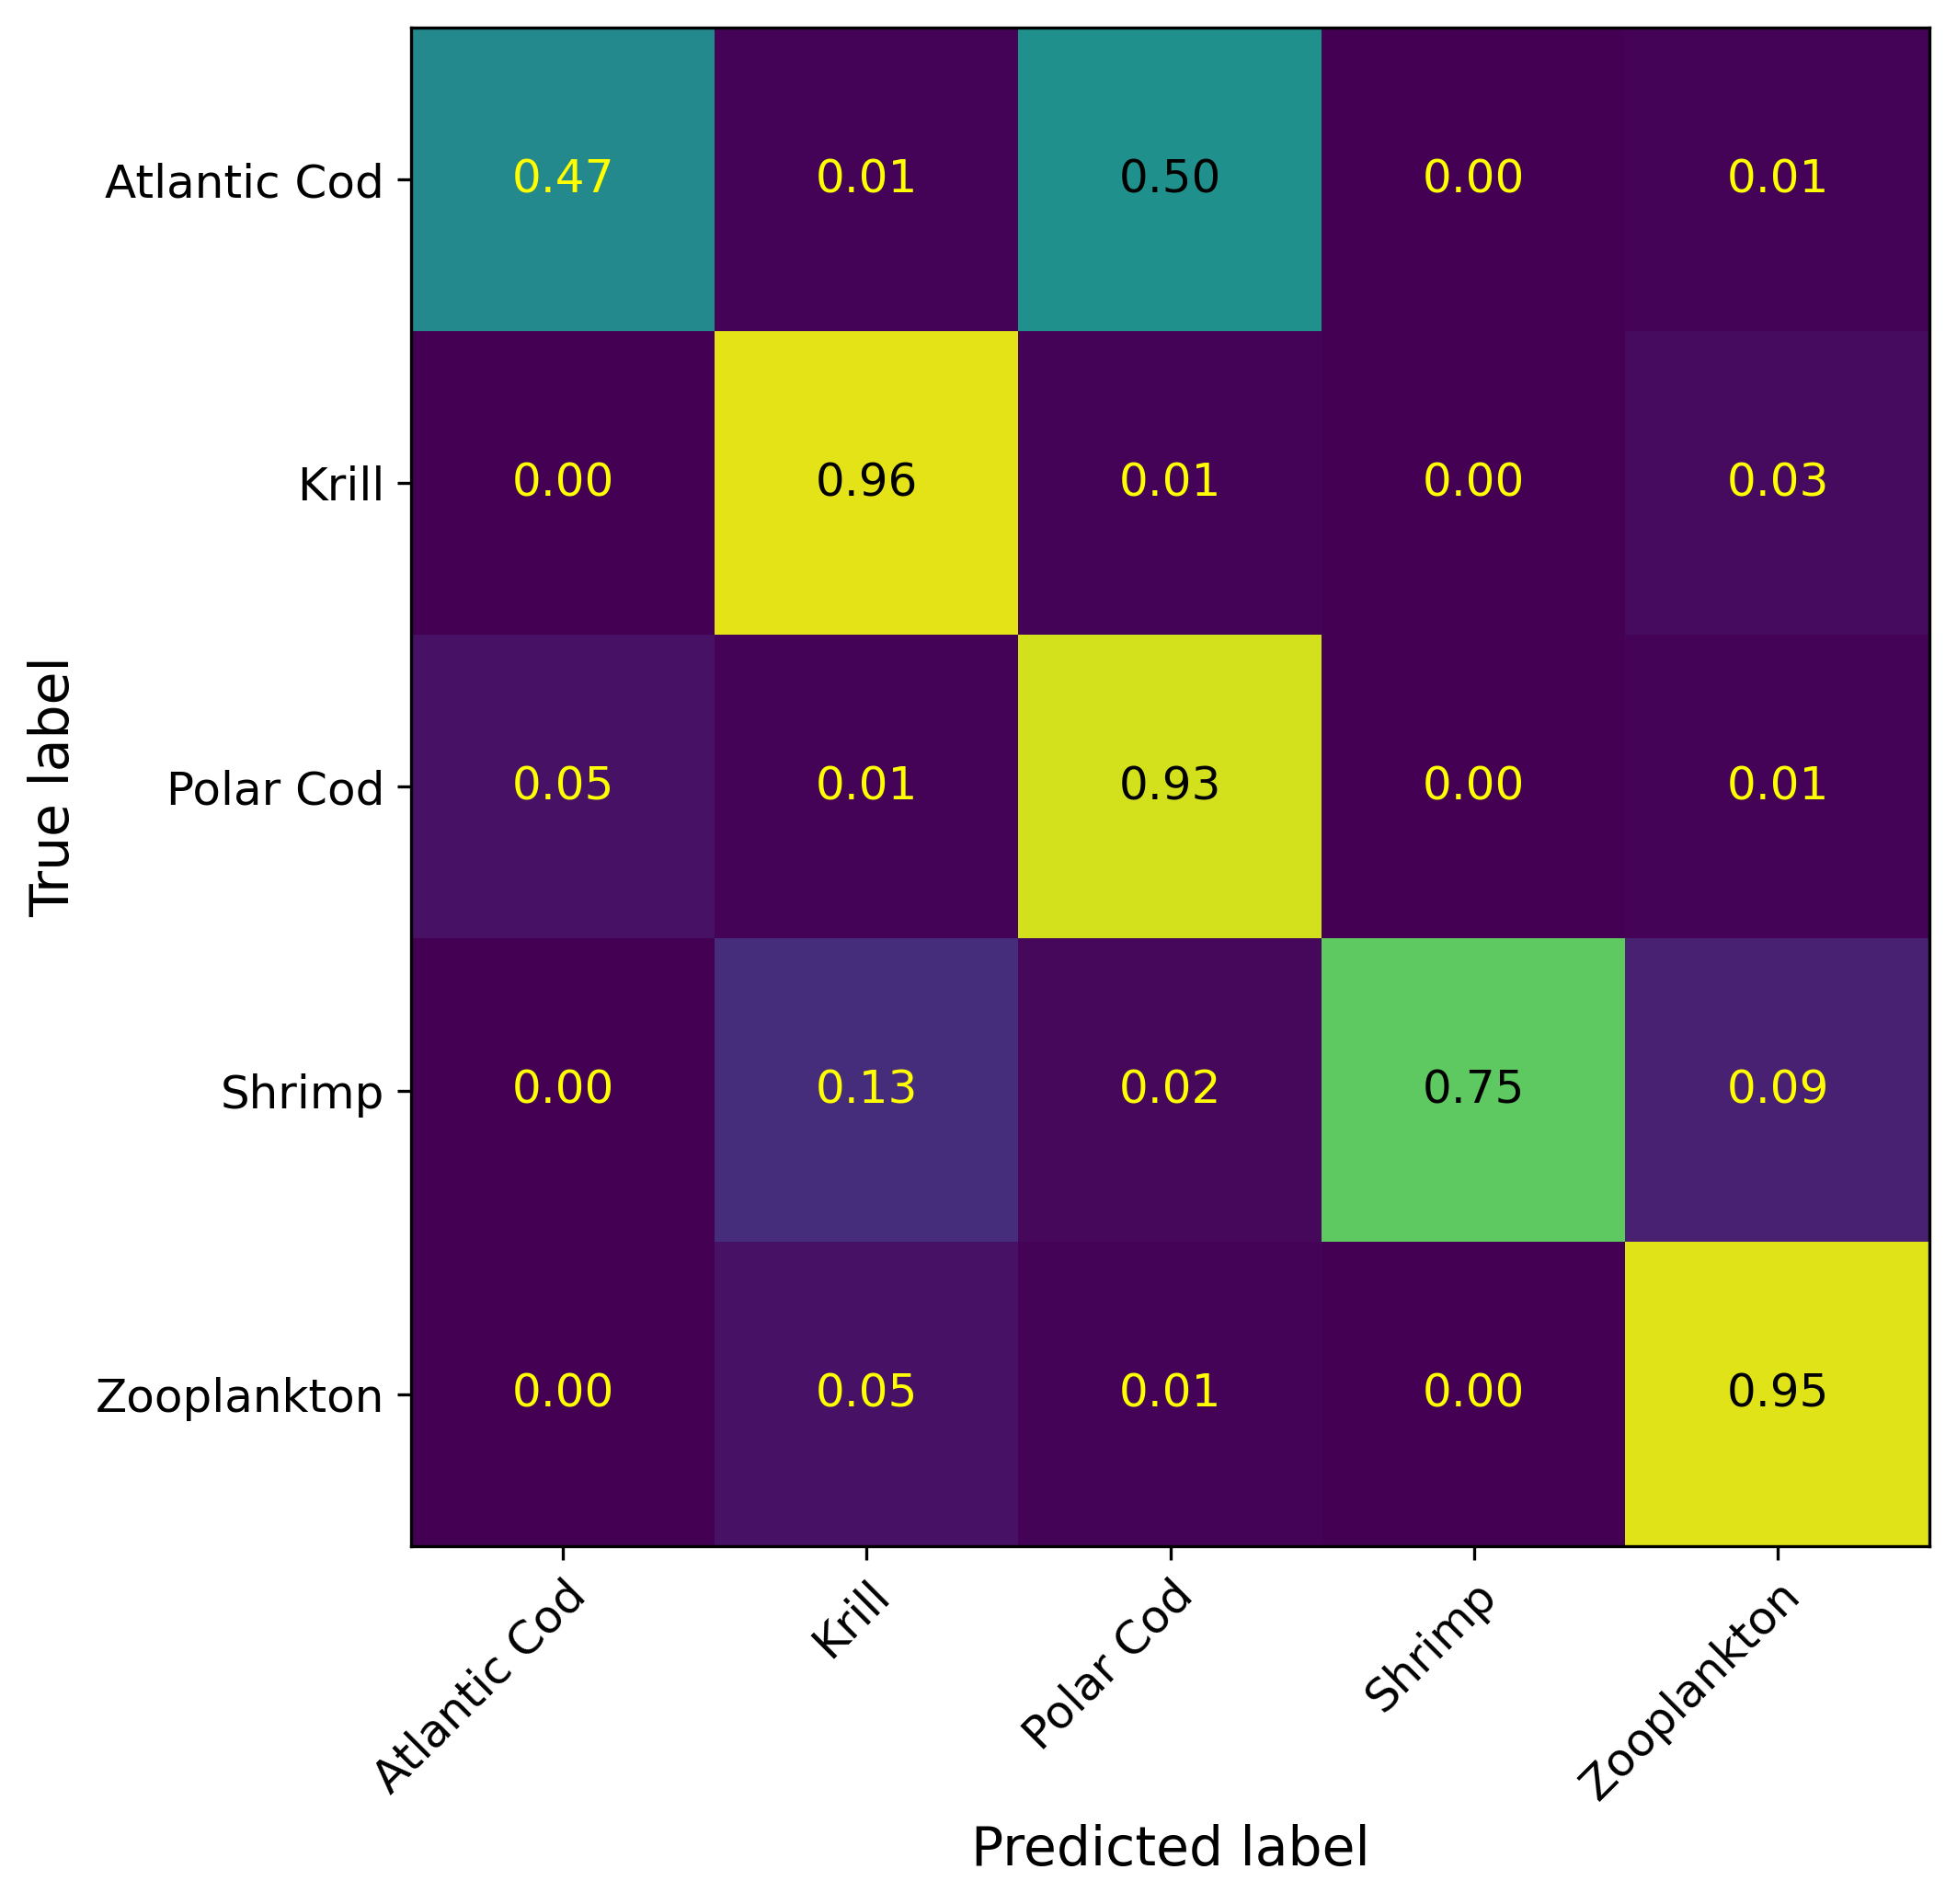

In [4]:
import numpy as np
import matplotlib.pyplot as plt

def plot_confusion_matrix(cm, classes, filename, figsize=(8, 7), dpi=300):
    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)

    # Heatmap
    im = ax.imshow(cm, interpolation="nearest", vmin=0, vmax=1)

    # No top title
    ax.set_xlabel("Predicted label", fontsize=14)
    ax.set_ylabel("True label", fontsize=14)

    ax.set_xticks(np.arange(len(classes)))
    ax.set_yticks(np.arange(len(classes)))
    ax.set_xticklabels(classes, rotation=45, ha="right", rotation_mode="anchor", fontsize=12)
    ax.set_yticklabels(classes, fontsize=12)

    # Adaptive text color
    threshold = cm.max() / 2.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            text_color = "black" if cm[i, j] > threshold else "yellow"
            ax.text(
                j, i, f"{cm[i, j]:.2f}",
                ha="center",
                va="center",
                color=text_color,
                fontsize=12
            )

    ax.set_xlim(-0.5, len(classes) - 0.5)
    ax.set_ylim(len(classes) - 0.5, -0.5)

    plt.tight_layout()
    plt.savefig(filename, dpi=dpi, bbox_inches="tight")
    plt.show()
    plt.close(fig)


# =========================
# 120 kHz matrices
# =========================
classes_120 = ["Atlantic Cod", "Polar Cod", "Shrimp"]

cm_120_catboost = np.array([
    [0.66, 0.32, 0.02],
    [0.12, 0.87, 0.01],
    [0.03, 0.02, 0.95],
])

cm_120_lightgbm = np.array([
    [0.55, 0.45, 0.00],
    [0.05, 0.95, 0.00],
    [0.02, 0.08, 0.90],
])

# =========================
# 200 kHz matrices
# =========================
classes_200 = ["Atlantic Cod", "Krill", "Polar Cod", "Shrimp", "Zooplankton"]

cm_200_catboost = np.array([
    [0.59, 0.02, 0.38, 0.00, 0.01],
    [0.00, 0.97, 0.01, 0.02, 0.01],
    [0.11, 0.02, 0.86, 0.00, 0.01],
    [0.01, 0.12, 0.02, 0.83, 0.02],
    [0.01, 0.10, 0.01, 0.02, 0.87],
])

cm_200_lightgbm = np.array([
    [0.47, 0.01, 0.50, 0.00, 0.01],
    [0.00, 0.96, 0.01, 0.00, 0.03],
    [0.05, 0.01, 0.93, 0.00, 0.01],
    [0.00, 0.13, 0.02, 0.75, 0.09],
    [0.00, 0.05, 0.01, 0.00, 0.95],
])

# =========================
# Make and save all 4 plots
# =========================
plot_confusion_matrix(cm_120_catboost, classes_120, "120 Catboost matrix.png", figsize=(8, 7))
plot_confusion_matrix(cm_120_lightgbm, classes_120, "120 Lightgbm matrix.png", figsize=(8, 7))
plot_confusion_matrix(cm_200_catboost, classes_200, "200 Catboost matrix.png", figsize=(8, 7))
plot_confusion_matrix(cm_200_lightgbm, classes_200, "200 Lightgbm matrix.png", figsize=(8, 7))
